# Loading the Dataset

In [1]:
!pip install scikit-learn pandas numpy shap fairlearn lime xgboost

In [2]:
!pip install --upgrade scikit-learn xgboost

In [3]:
!wget https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv -P /usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/

--2025-10-10 22:02:10--  https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2546489 (2.4M) [text/plain]
Saving to: ‘/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv.1’

compas-scores-two-y 100%[===================>]   2.43M  --.-KB/s    in 0.05s   

2025-10-10 22:02:11 (48.8 MB/s) - ‘/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv.1’ saved [2546489/2546489]



In [4]:
ls -lh /usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/

total 4.9M
-rw-r--r-- 1 root root 2.5M Oct 10 20:09 compas-scores-two-years.csv
-rw-r--r-- 1 root root 2.5M Oct 10 22:02 compas-scores-two-years.csv.1


In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [6]:
# Define the file path
file_path = "/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [7]:
df.shape

(7214, 53)

In [8]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [9]:
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


# Preprocessing

In [10]:
df["two_year_recid"].value_counts()
# recid rate 45.1%

,count
two_year_recid,
0,3963
1,3251


In [11]:
df["is_recid"].value_counts()

,count
is_recid,
0,3743
1,3471


In [12]:
(df['two_year_recid']==df['is_recid']).value_counts()

,count
True,6994
False,220


### **Identifiers & Personal Information:**
1. **'id'** – Unique identifier for each individual in the dataset.  
2. **'name'** – Full name of the individual.  
3. **'first'** – First name of the individual.  
4. **'last'** – Last name of the individual.  
5. **'dob'** – Date of birth.  
6. **'sex'** – Gender of the individual (Male/Female).  
7. **'race'** – Ethnicity of the individual (e.g., African-American, Caucasian, etc.).  

In [13]:
df = pd.get_dummies(df, columns=['race'], drop_first=False, dtype=int)

In [14]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=int)

In [15]:
columns_to_drop = ['id','name','first','last','dob']

### **Demographic & Age Information:**
8. **'age'** – Age of the individual at the time of assessment.  
9. **'age_cat'** – Categorized age groups (e.g., 18-25, 26-45, 46+).  

In [16]:
df['age_cat'].value_counts()

,count
age_cat,
25 - 45,4109
Greater than 45,1576
Less than 25,1529


In [17]:
# Define age bins and labels
bins = [18, 25, 35, 45, float('inf')]  # 46+ uses infinity
labels = ['18-25', '26-35', '36-45', '46+']

# Create categorical age groups
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

In [18]:
df['age_group'].value_counts()

,count
age_group,
26-35,2581
18-25,1858
46+,1463
36-45,1309


In [19]:
# Convert to one-hot encoding with prefix "age_"
df = pd.get_dummies(df, columns=['age_group'], prefix='age', dtype=int)

In [20]:
df

,id,name,first,last,compas_screening_date,dob,age,age_cat,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Male,age_18-25,age_26-35,age_36-45,age_46+
0,1,miguel hernandez,miguel,hernandez,2013-08-14,1947-04-18,69,Greater than 45,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0,0,0,0,0,0,1,1,0,0,0,1
1,3,kevon dixon,kevon,dixon,2013-01-27,1982-01-22,34,25 - 45,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1,1,0,0,0,0,0,1,0,1,0,0
2,4,ed philo,ed,philo,2013-04-14,1991-05-14,24,Less than 25,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1,1,0,0,0,0,0,1,1,0,0,0
3,5,marcu brown,marcu,brown,2013-01-13,1993-01-21,23,Less than 25,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0,1,0,0,0,0,0,1,1,0,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,1973-01-22,43,25 - 45,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0,0,0,0,0,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,1992-07-17,23,Less than 25,0,7,0,0,0,-1.0,2013-11-22 05:18:27,2013-11-24 02:59:20,13016249CF10A,2013-11-22,NaN,1.0,F,Deliver Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,7,Medium,2013-11-23,Risk of Violence,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0,1,0,0,0,0,0,1,1,0,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,1993-03-25,23,Less than 25,0,3,0,0,0,-1.0,2014-01-31 07:13:54,2014-02-02 04:03:52,14001422CF10A,2014-01-31,NaN,1.0,F,Leaving the Scene of Accident,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,3,Low,2014-02-01,Risk of Violence,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0,1,0,0,0,0,0,1,1,0,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,1958-10-01,57,Greater than 45,0,1,0,0,0,-1.0,2014-01-13 05:48:01,2014-01-14 07:49:46,14000581CF10A,2014-01-13,NaN,1.0,F,Aggravated Battery / Pregnant,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-01-14,Risk of Violence,1,Low,2014-01-14,2014-01-

In [21]:
columns_to_drop += ['age', 'age_cat']

### **Criminal History & Prior Records:**
10. **'juv_fel_count'** – Number of juvenile felony convictions.  
11. **'juv_misd_count'** – Number of juvenile misdemeanor convictions.  
12. **'juv_other_count'** – Number of other juvenile offenses.  
13. **'priors_count'** – Total number of prior adult convictions.  

In [22]:
# columns_to_drop += ['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']

### **Current Case Information:**
14. **'compas_screening_date'** – Date when the COMPAS risk assessment was conducted.  
15. **'c_case_number'** – Unique identifier for the individual's criminal case.  
16. **'c_offense_date'** – Date of the current offense.  
17. **'c_arrest_date'** – Date of the arrest for the current charge.  
18. **'c_charge_degree'** – Severity of the current charge (M = Misdemeanor, F = Felony).  
19. **'c_charge_desc'** – Description of the current charge (e.g., 'Grand Theft', 'Drug Possession').  
20. **'c_days_from_compas'** – Number of days between COMPAS assessment and the current case.  

In [23]:
columns_to_drop += ['compas_screening_date','c_arrest_date','c_days_from_compas', 'c_case_number','c_offense_date', 'c_charge_desc']

In [24]:
df['c_charge_desc'].value_counts()

,count
c_charge_desc,
Battery,1156
arrest case no charge,1137
Possession of Cocaine,474
Grand Theft in the 3rd Degree,425
Driving While License Revoked,200
...,...
Poss Pyrrolidinobutiophenone,1
Conspiracy Dealing Stolen Prop,1
Felony DUI - Enhanced,1


### Was testing to see if we could one hot encode c_charge_desc. Conclusion: Too unpredictable as a feature to predict recidivism. c_charge_degree is a good enough feature to keep


In [25]:
# # Count total occurrences of each charge type
# charge_counts = df['c_charge_desc'].value_counts()

# # Filter out charge descriptions with fewer than 10 total cases
# valid_charges = charge_counts[charge_counts >= 10].index
# df_filtered = df[df['c_charge_desc'].isin(valid_charges)]

# # Recalculate total and recidivism cases for the filtered data
# charge_counts_filtered = df_filtered.groupby('c_charge_desc')['two_year_recid'].count()
# recid_counts_filtered = df_filtered.groupby('c_charge_desc')['two_year_recid'].sum()

# # Calculate recidivism percentage
# recid_percentage_filtered = (recid_counts_filtered / charge_counts_filtered) * 100

# # Get top 10 charge types with the highest recidivism percentage
# top_10_recid_filtered = recid_percentage_filtered.nlargest(10)

# # Display the result
# print(top_10_recid_filtered)

In [26]:
# # Get top 30 most common charge descriptions
# top_30 = df['c_charge_desc'].value_counts().nlargest(30).index

# # Create binary columns with "c_charge_" prefix
# for charge in top_30:
#     df[f'c_charge_{charge}'] = (df['c_charge_desc'] == charge).astype(int)

# # Create "Other" column
# df['c_charge_Other'] = (~df['c_charge_desc'].isin(top_30)).astype(int)

# # Drop the original column
# df = df.drop(columns=['c_charge_desc'])

In [27]:
df.groupby('two_year_recid')['c_charge_degree'].value_counts()

two_year_recid  c_charge_degree
0               F                  2384
                M                  1579
1               F                  2282
                M                   969
Name: count, dtype: int64

In [28]:
df = pd.get_dummies(df, columns=['c_charge_degree'], drop_first=True, dtype=int)

### **Jail Custody Information:**
21. **'c_jail_in'** – Date the individual was jailed for the current offense.  
22. **'c_jail_out'** – Date the individual was released from jail for the current offense.

In [29]:
# df = df.dropna(subset=['c_jail_in', 'c_jail_out'])

In [30]:
columns_to_drop += ['c_jail_in','c_jail_out']

### **Recidivism (Reoffense) Information:**
23. **'is_recid'** – 1 if the individual reoffended, 0 otherwise.  
24. **'two_year_recid'** – 1 if the individual reoffended within two years, 0 otherwise.  


In [31]:
# columns_to_drop += ['is_recid']
# columns_to_drop += ['two_year_recid']

### **Reoffense Case Details:**
25. **'r_case_number'** – Case number for the recidivism offense.  
26. **'r_offense_date'** – Date of the reoffense.  
27. **'r_arrest_date'** – Date of arrest for the reoffense.  
28. **'r_days_from_arrest'** – Days between the original offense and the reoffense.  
29. **'r_charge_degree'** – Severity of the reoffense (M = Misdemeanor, F = Felony).  
30. **'r_charge_desc'** – Description of the reoffense charge.  
31. **'r_jail_in'** – Jail entry date for the reoffense.  
32. **'r_jail_out'** – Jail exit date for the reoffense.  

In [32]:
columns_to_drop += ['r_case_number', 'r_offense_date', 'r_days_from_arrest', 'r_charge_degree', 'r_charge_desc', 'r_jail_in', 'r_jail_out']

### **Violent Recidivism Information:**
33. **'violent_recid'** – Number of times the individual has committed a violent reoffense.  
34. **'is_violent_recid'** – 1 if the individual committed a violent reoffense, 0 otherwise.  
35. **'vr_case_number'** – Case number for violent recidivism.  
36. **'vr_offense_date'** – Date of the violent reoffense.  
37. **'vr_charge_degree'** – Severity of the violent reoffense (M = Misdemeanor, F = Felony).  
38. **'vr_charge_desc'** – Description of the violent reoffense charge.  

In [33]:
df['is_violent_recid'].value_counts()

,count
is_violent_recid,
0,6395
1,819


In [34]:
df['vr_charge_degree'].value_counts()

,count
vr_charge_degree,
(M1),344
(F3),228
(F2),162
(F1),38
(M2),19
(F7),18
(MO3),5
(F6),4
(F5),1


In [35]:
columns_to_drop += ['violent_recid', 'vr_case_number', 'vr_offense_date', 'vr_charge_degree', 'vr_charge_desc']

### **COMPAS Risk Assessment Scores:**
39. **'type_of_assessment'** – Type of risk assessment (e.g., General Recidivism, Violent Recidivism).  
40. **'decile_score'** – Risk score (1-10) predicting likelihood of recidivism.  
41. **'score_text'** – Categorical risk level based on 'decile_score' (Low, Medium, High).  
42. **'decile_score.1'** – Duplicate of 'decile_score'.  

In [36]:
columns_to_drop += ['type_of_assessment','decile_score', 'score_text', 'decile_score.1']

### **Violent Recidivism Risk Scores:**
43. **'v_type_of_assessment'** – Type of assessment for violent recidivism.  
44. **'v_decile_score'** – Risk score (1-10) predicting violent reoffense.  
45. **'v_score_text'** – Categorical risk level for violent recidivism (Low, Medium, High).  
46. **'v_screening_date'** – Date of the violent recidivism assessment.  

In [37]:
columns_to_drop += ['v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date']

### **Additional Features & Redundant Columns:**
47. **'days_b_screening_arrest'** – Days between arrest and COMPAS screening.  
48. **'priors_count.1'** – Duplicate of 'priors_count'.  
49. **'in_custody'** – Date when the person entered custody.  
50. **'out_custody'** – Date when the person left custody.  
51. **'start'** – Beginning of a time-based event (not clearly defined).  
52. **'end'** – End of a time-based event (not clearly defined).  
53. **'event'** – An unspecified event indicator.  


In [38]:
df.groupby('two_year_recid')['event'].value_counts()

two_year_recid  event
0               0        3817
                1         146
1               1        2616
                0         635
Name: count, dtype: int64

In [39]:
# df['total_prior_convictions'] = df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count'] + df['priors_count']

In [40]:
columns_to_drop += ['days_b_screening_arrest', 'priors_count.1','in_custody','out_custody','start','end','event']

In [41]:
columns_to_drop

['id',
 'name',
 'first',
 'last',
 'dob',
 'age',
 'age_cat',
 'compas_screening_date',
 'c_arrest_date',
 'c_days_from_compas',
 'c_case_number',
 'c_offense_date',
 'c_charge_desc',
 'c_jail_in',
 'c_jail_out',
 'r_case_number',
 'r_offense_date',
 'r_days_from_arrest',
 'r_charge_degree',
 'r_charge_desc',
 'r_jail_in',
 'r_jail_out',
 'violent_recid',
 'vr_case_number',
 'vr_offense_date',
 'vr_charge_degree',
 'vr_charge_desc',
 'type_of_assessment',
 'decile_score',
 'score_text',
 'decile_score.1',
 'v_type_of_assessment',
 'v_decile_score',
 'v_score_text',
 'v_screening_date',
 'days_b_screening_arrest',
 'priors_count.1',
 'in_custody',
 'out_custody',
 'start',
 'end',
 'event']

In [42]:
df = df.drop(columns=columns_to_drop,axis=1)

In [43]:
df = df.drop(columns = ['screening_date'])

In [44]:
df.columns

Index(['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
       'is_recid', 'is_violent_recid', 'two_year_recid',
       'race_African-American', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Native American', 'race_Other', 'sex_Male',
       'age_18-25', 'age_26-35', 'age_36-45', 'age_46+', 'c_charge_degree_M'],
      dtype='object')

In [45]:
df.head()

,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,is_violent_recid,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Male,age_18-25,age_26-35,age_36-45,age_46+,c_charge_degree_M
0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0
1,0,0,0,0,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0
2,0,0,1,4,1,0,1,1,0,0,0,0,0,1,1,0,0,0,0
3,0,1,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0


In [46]:
df.shape

(7214, 19)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   juv_fel_count          7214 non-null   int64
 1   juv_misd_count         7214 non-null   int64
 2   juv_other_count        7214 non-null   int64
 3   priors_count           7214 non-null   int64
 4   is_recid               7214 non-null   int64
 5   is_violent_recid       7214 non-null   int64
 6   two_year_recid         7214 non-null   int64
 7   race_African-American  7214 non-null   int64
 8   race_Asian             7214 non-null   int64
 9   race_Caucasian         7214 non-null   int64
 10  race_Hispanic          7214 non-null   int64
 11  race_Native American   7214 non-null   int64
 12  race_Other             7214 non-null   int64
 13  sex_Male               7214 non-null   int64
 14  age_18-25              7214 non-null   int64
 15  age_26-35              7214 non-null  

### Visualizing overlap between features and targets

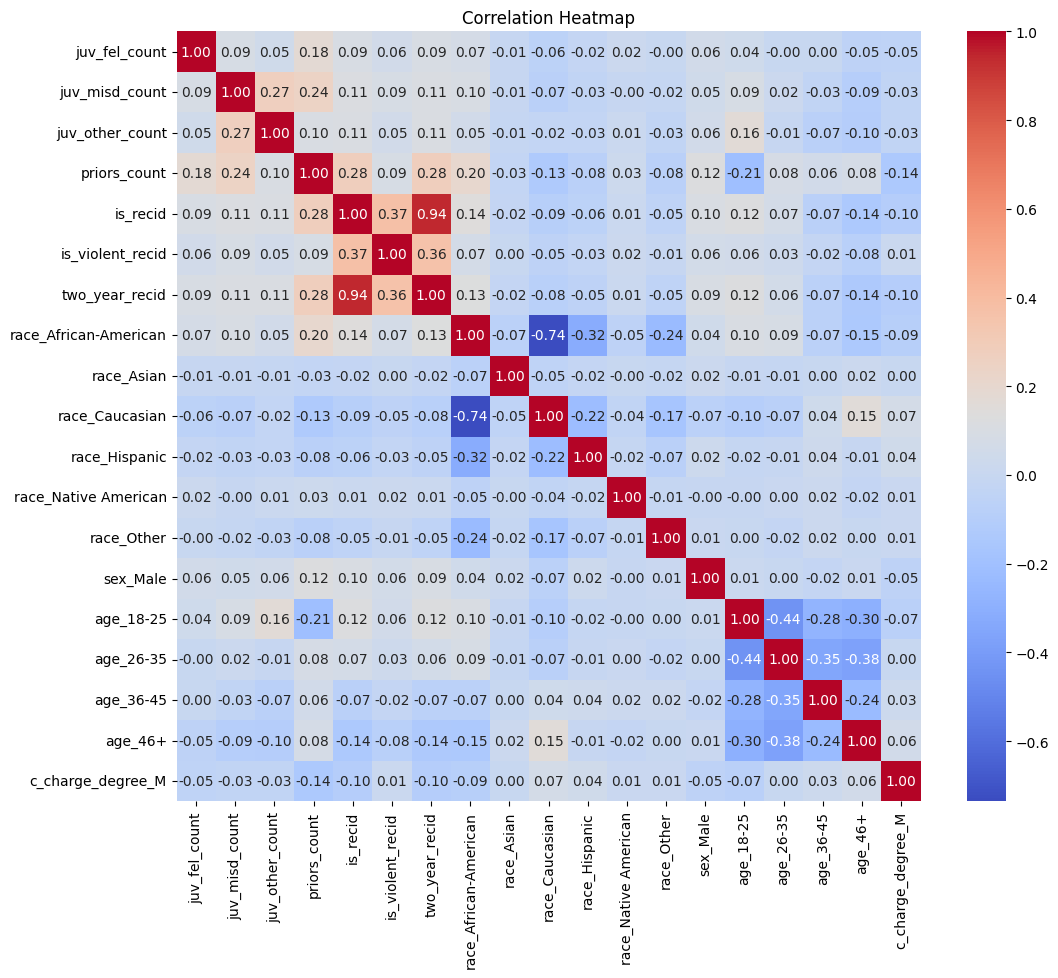

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Baseline models

## Train Test Split

In [49]:
X = df.drop(columns=['two_year_recid', 'is_recid', 'is_violent_recid'],axis=1)

In [50]:
y = df['two_year_recid']

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5771, 16), (1443, 16), (5771,), (1443,))

### XGB

In [ ]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
model_1 = xgb.XGBClassifier(random_state=42)
model_1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred_1 = model_1.predict(X_test)

Accuracy: 0.6763686763686764
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73       823
           1       0.65      0.54      0.59       620

    accuracy                           0.68      1443
   macro avg       0.67      0.66      0.66      1443
weighted avg       0.67      0.68      0.67      1443

Confusion Matrix:
 [[642 181]
 [286 334]]


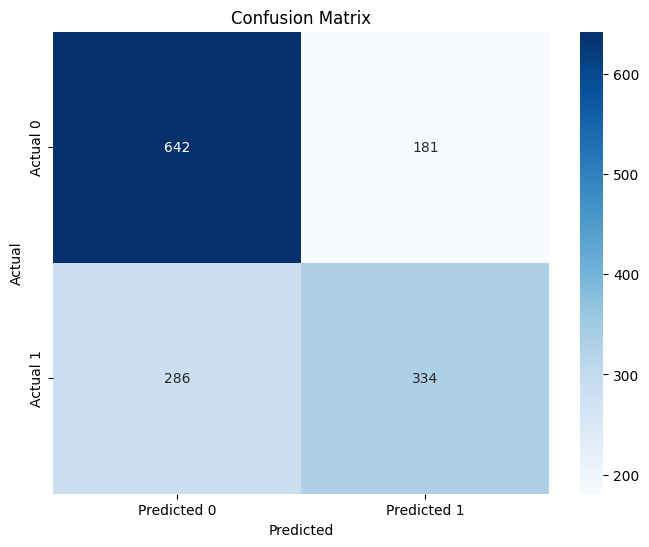

In [ ]:
accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f"Accuracy: {accuracy_1}")

class_report_1 = classification_report(y_test, y_pred_1)
print("Classification Report:\n", class_report_1)

conf_matrix_1 = confusion_matrix(y_test, y_pred_1)
print("Confusion Matrix:\n", conf_matrix_1)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_1, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### SVC

In [ ]:
from sklearn.svm import SVC
model_2 = SVC(random_state=42)
model_2.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_pred_2 = model_2.predict(X_test)

Accuracy: 0.6923076923076923
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.81      0.75       823
           1       0.68      0.53      0.60       620

    accuracy                           0.69      1443
   macro avg       0.69      0.67      0.67      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[668 155]
 [289 331]]


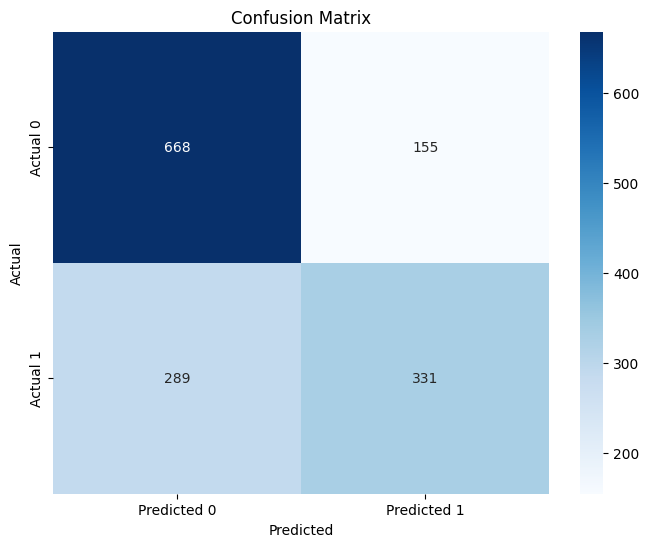

In [ ]:
accuracy_2 = accuracy_score(y_test, y_pred_2)
print(f"Accuracy: {accuracy_2}")

class_report_2 = classification_report(y_test, y_pred_2)
print("Classification Report:\n", class_report_2)

conf_matrix_2 = confusion_matrix(y_test, y_pred_2)
print("Confusion Matrix:\n", conf_matrix_2)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_2, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression
model_3 = LogisticRegression(random_state=42)
model_3.fit(X_train, y_train)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression(random_state=42)

In [ ]:
y_pred_3 = model_3.predict(X_test)

Accuracy: 0.6812196812196812
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73       823
           1       0.64      0.59      0.61       620

    accuracy                           0.68      1443
   macro avg       0.67      0.67      0.67      1443
weighted avg       0.68      0.68      0.68      1443

Confusion Matrix:
 [[617 206]
 [254 366]]


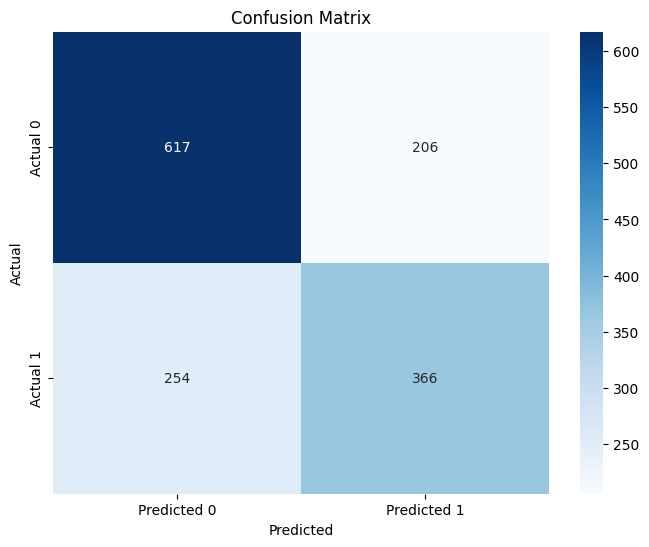

In [ ]:
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Accuracy: {accuracy_3}")

class_report_3 = classification_report(y_test, y_pred_3)
print("Classification Report:\n", class_report_3)

conf_matrix_3 = confusion_matrix(y_test, y_pred_3)
print("Confusion Matrix:\n", conf_matrix_3)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_3, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### GBDT

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_4 = GradientBoostingClassifier(random_state=42)
model_4.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_4 = model_4.predict(X_test)

Accuracy: 0.6909216909216909
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74       823
           1       0.65      0.60      0.63       620

    accuracy                           0.69      1443
   macro avg       0.68      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[625 198]
 [248 372]]


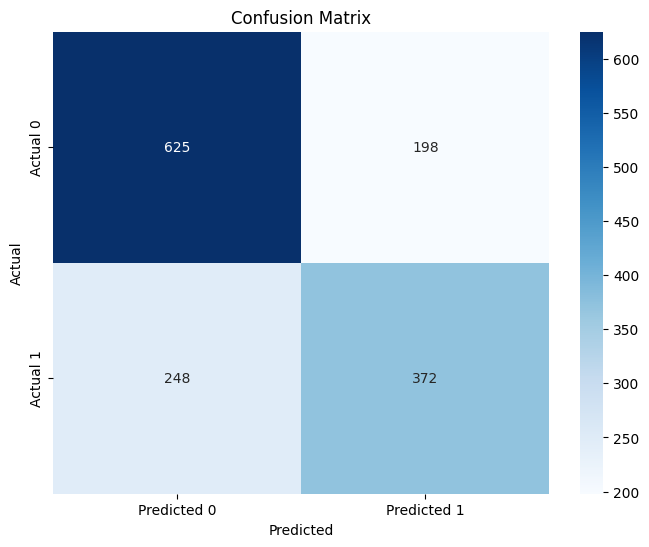

In [ ]:
accuracy_4 = accuracy_score(y_test, y_pred_4)
print(f"Accuracy: {accuracy_4}")

class_report_4 = classification_report(y_test, y_pred_4)
print("Classification Report:\n", class_report_4)

conf_matrix_4 = confusion_matrix(y_test, y_pred_4)
print("Confusion Matrix:\n", conf_matrix_4)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_4, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### RFC

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_5 = RandomForestClassifier(random_state=42)
model_5.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_5 = model_5.predict(X_test)

Accuracy: 0.6507276507276507
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71       823
           1       0.61      0.51      0.56       620

    accuracy                           0.65      1443
   macro avg       0.64      0.63      0.63      1443
weighted avg       0.65      0.65      0.65      1443

Confusion Matrix:
 [[623 200]
 [304 316]]


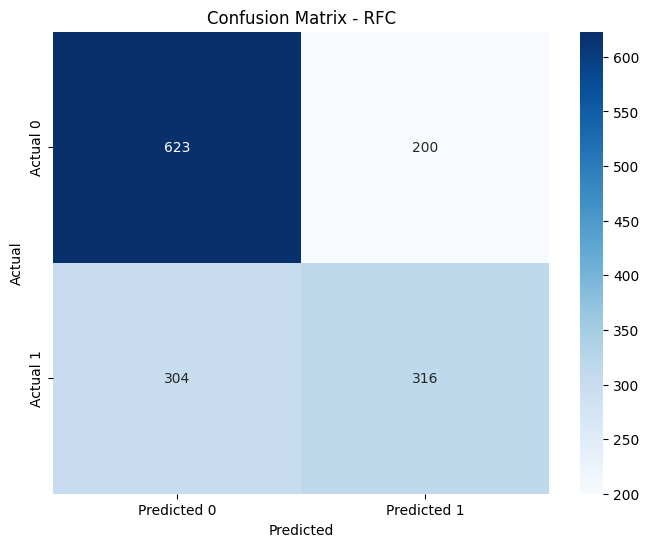

In [ ]:
accuracy_5 = accuracy_score(y_test, y_pred_5)
print(f"Accuracy: {accuracy_5}")

class_report_5 = classification_report(y_test, y_pred_5)
print("Classification Report:\n", class_report_5)

conf_matrix_5 = confusion_matrix(y_test, y_pred_5)
print("Confusion Matrix:\n", conf_matrix_5)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_5, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - RFC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### NN (MLPClassifier)

In [ ]:
from sklearn.neural_network import MLPClassifier

model_6 = MLPClassifier(random_state=42, max_iter=500)
model_6.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [ ]:
y_pred_6 = model_6.predict(X_test)

Accuracy: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.67      0.55      0.60       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443

Confusion Matrix:
 [[656 167]
 [282 338]]


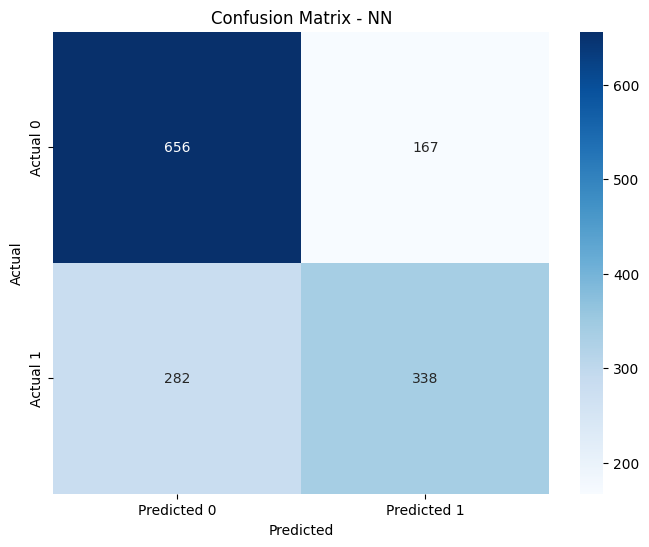

In [ ]:
accuracy_6 = accuracy_score(y_test, y_pred_6)
print(f"Accuracy: {accuracy_6}")

class_report_6 = classification_report(y_test, y_pred_6)
print("Classification Report:\n", class_report_6)

conf_matrix_6 = confusion_matrix(y_test, y_pred_6)
print("Confusion Matrix:\n", conf_matrix_6)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_6, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - NN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# RandomizedSearchCV Hyperparameter Tuning

### XGB

Best XGBoost Parameters: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Accuracy with Best XGBoost Parameters: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.74       823
           1       0.65      0.60      0.62       620

    accuracy                           0.69      1443
   macro avg       0.68      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[625 198]
 [251 369]]


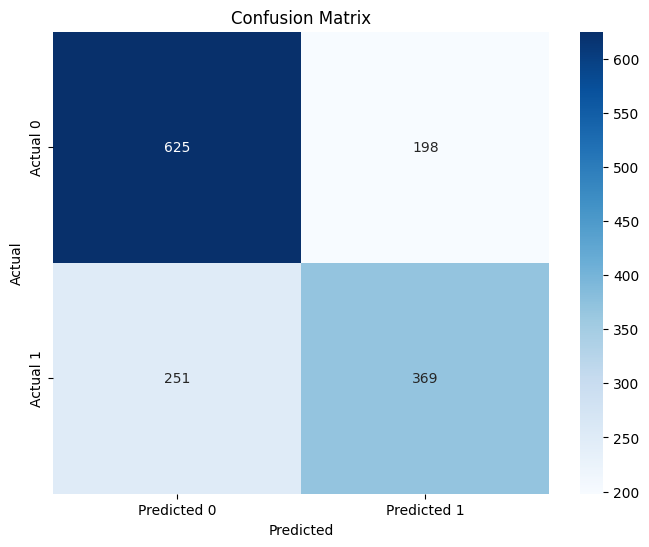

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(model_1, xgb_param_grid, scoring='accuracy', n_iter=100, cv=5, n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy with Best XGBoost Parameters: {accuracy_xgb}")

class_report_xgb = classification_report(y_test, y_pred_xgb)
print("Classification Report:\n", class_report_xgb)

conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", conf_matrix_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVC

Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 50}
Accuracy with Best SVM Parameters: 0.6909216909216909
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.54      0.60       620

    accuracy                           0.69      1443
   macro avg       0.69      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443

Confusion Matrix:
 [[662 161]
 [285 335]]


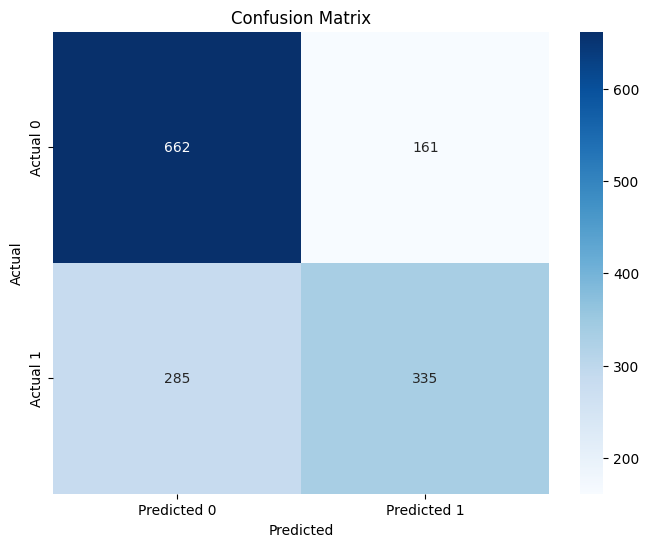

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

svm_param_dist = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svm_search = RandomizedSearchCV(model_2, svm_param_dist, n_iter=20, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

svm_search.fit(X_train, y_train)

print("Best SVM Parameters:", svm_search.best_params_)
best_svc = svm_search.best_estimator_
y_pred_svm = best_svc.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy with Best SVM Parameters: {accuracy_svm}")

class_report_svm = classification_report(y_test, y_pred_svm)
print("Classification Report:\n", class_report_svm)

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", conf_matrix_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 5000, 'C': 0.01}
Test Accuracy: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.67      0.55      0.60       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443



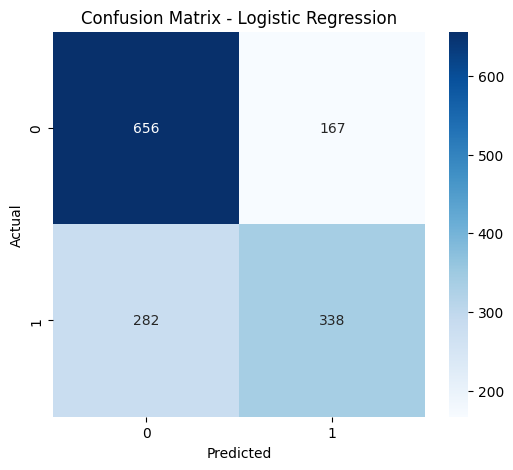

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

logistic_param_dist = {
    'C': np.logspace(-3, 3, 7),
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [3000, 4000, 5000]
}

model = LogisticRegression(random_state=42)

logreg_search = RandomizedSearchCV(model_3, logistic_param_dist, n_iter=40, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

logreg_search.fit(X_train, y_train)

best_logreg = logreg_search.best_estimator_

y_pred_lr = best_logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_lr)

print("Best Parameters:", logreg_search.best_params_)
print(f"Test Accuracy: {accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### GBDT

Best Gradient Boosting Parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.01}
Accuracy with Best Gradient Boosting Parameters: 0.6874566874566874
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74       823
           1       0.65      0.58      0.62       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.68      1443
weighted avg       0.68      0.69      0.68      1443

Confusion Matrix:
 [[630 193]
 [258 362]]


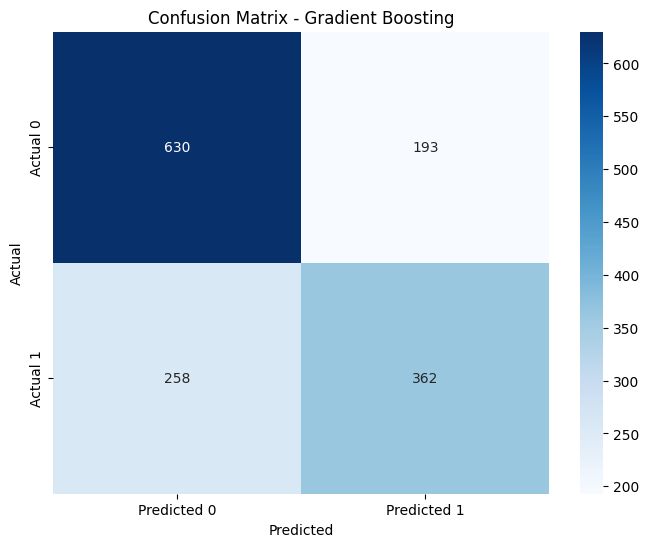

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

gbdt_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.8, 1.0]
}

gbdt_search = RandomizedSearchCV(model_4, gbdt_param_dist, n_iter=100, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

gbdt_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gbdt_search.best_params_)
best_gbdt = gbdt_search.best_estimator_

y_pred_gbdt = best_gbdt.predict(X_test)
accuracy_gbdt = accuracy_score(y_test, y_pred_gbdt)
print(f"Accuracy with Best Gradient Boosting Parameters: {accuracy_gbdt}")

class_report_gbdt = classification_report(y_test, y_pred_gbdt)
print("Classification Report:\n", class_report_gbdt)

conf_matrix_gbdt = confusion_matrix(y_test, y_pred_gbdt)
print("Confusion Matrix:\n", conf_matrix_gbdt)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gbdt, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### RFC

Best Parameters (RFC): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7}
Test Accuracy (RFC): 0.6826056826056826
Classification Report (RFC):
               precision    recall  f1-score   support

           0       0.70      0.77      0.73       823
           1       0.65      0.57      0.61       620

    accuracy                           0.68      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.68      0.68      0.68      1443



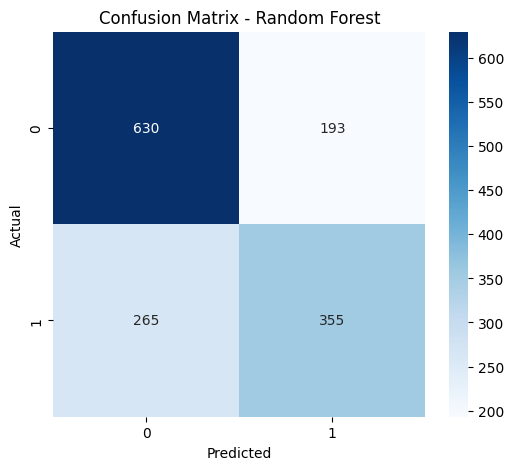

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_model = RandomForestClassifier(random_state=42)

rfc_search = RandomizedSearchCV(
    rfc_model,
    param_distributions=rfc_param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rfc_search.fit(X_train, y_train)

best_rfc = rfc_search.best_estimator_
y_pred_rfc = best_rfc.predict(X_test)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)

print("Best Parameters (RFC):", rfc_search.best_params_)
print(f"Test Accuracy (RFC): {accuracy_rfc}")
print("Classification Report (RFC):\n", classification_report(y_test, y_pred_rfc))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### NN (MLPClassifier)

Best Parameters (NN): {'solver': 'adam', 'max_iter': 500, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'tanh'}
Test Accuracy (NN): 0.693000693000693
Classification Report (NN):
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.55      0.61       620

    accuracy                           0.69      1443
   macro avg       0.69      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443



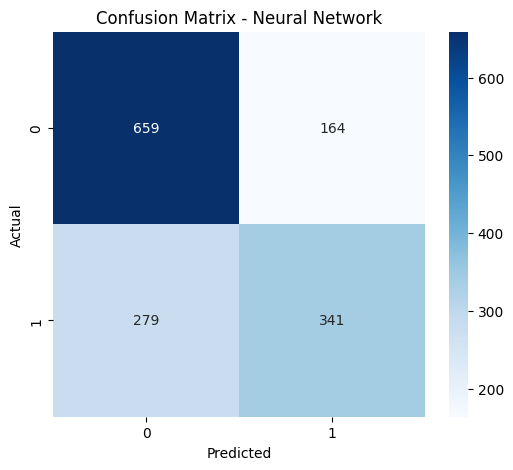

In [ ]:
from sklearn.neural_network import MLPClassifier

nn_param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500, 1000, 1500]
}

nn_model = MLPClassifier(random_state=42)

nn_search = RandomizedSearchCV(
    nn_model,
    param_distributions=nn_param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

nn_search.fit(X_train, y_train)

best_nn = nn_search.best_estimator_
y_pred_nn = best_nn.predict(X_test)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print("Best Parameters (NN):", nn_search.best_params_)
print(f"Test Accuracy (NN): {accuracy_nn}")
print("Classification Report (NN):\n", classification_report(y_test, y_pred_nn))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network")
plt.show()


# SHAP

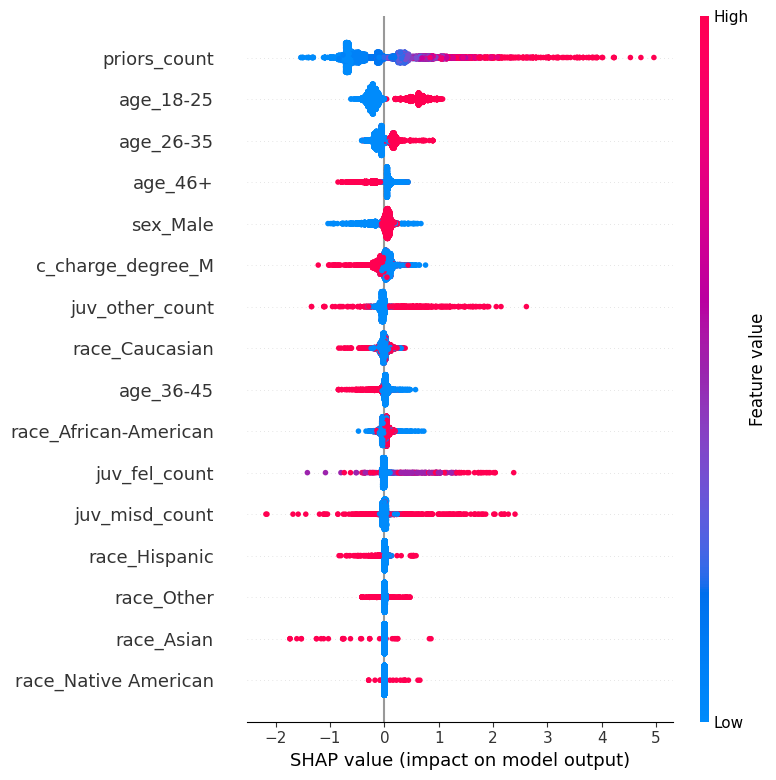

In [ ]:
# Two year XGB
import shap

explainer = shap.TreeExplainer(model_1)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

  0%|          | 0/200 [00:00<?, ?it/s]

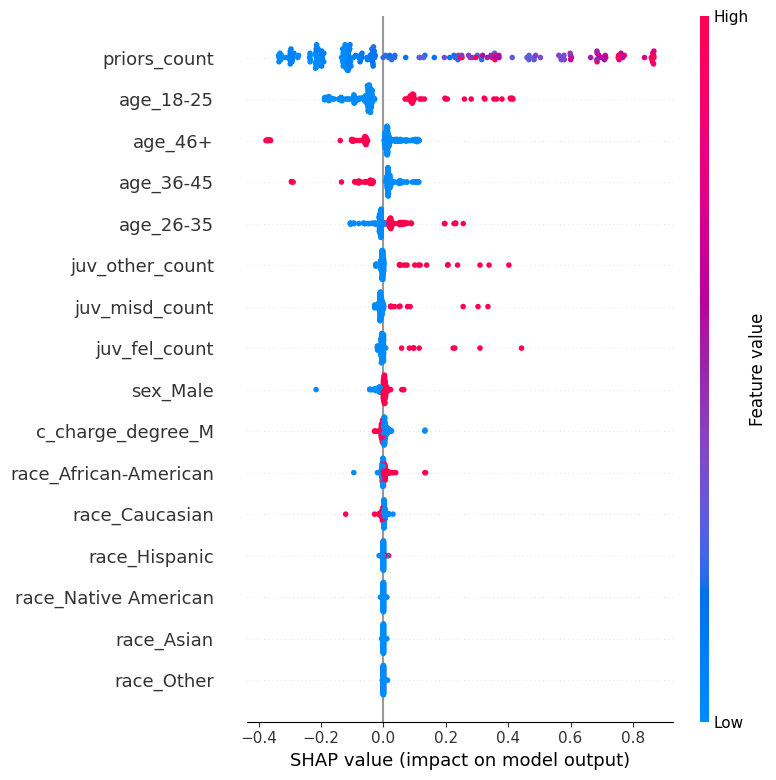

In [ ]:
# Two year recid SVC
import shap

explainer = shap.KernelExplainer(model_2.predict, shap.sample(X_train, 100))
shap_values = explainer.shap_values(X[:200])

shap.summary_plot(shap_values, X[:200])

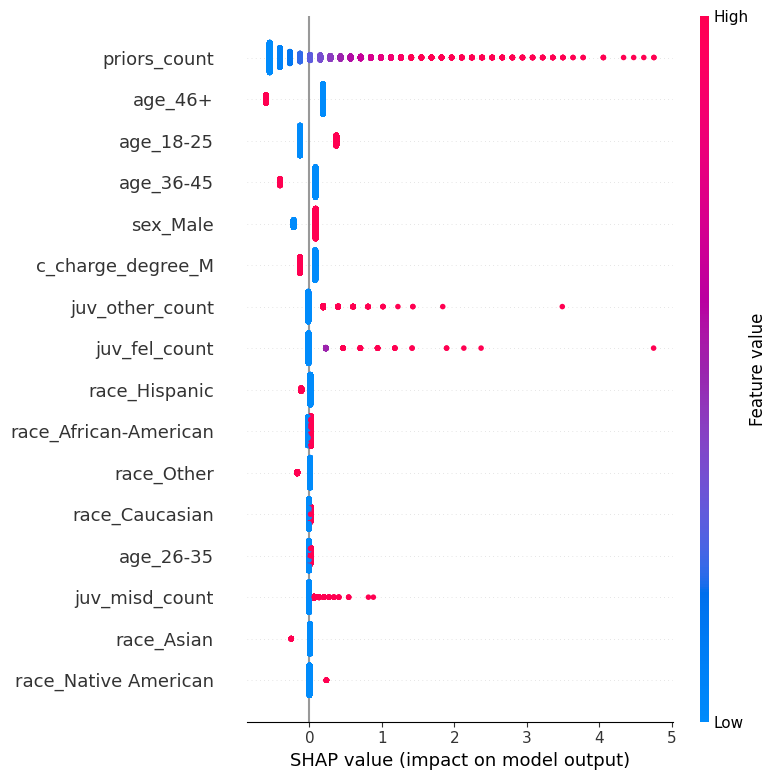

In [ ]:
# Two year recid LogReg
import shap

explainer = shap.LinearExplainer(model_3, X_train)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

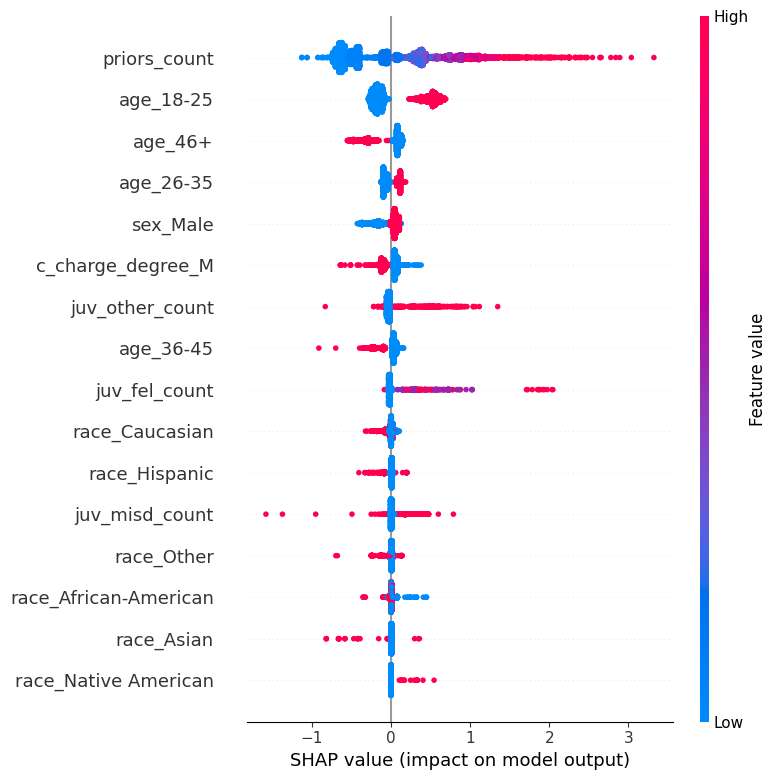

In [ ]:
# Two year GBDT
import shap

explainer = shap.Explainer(model_4)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

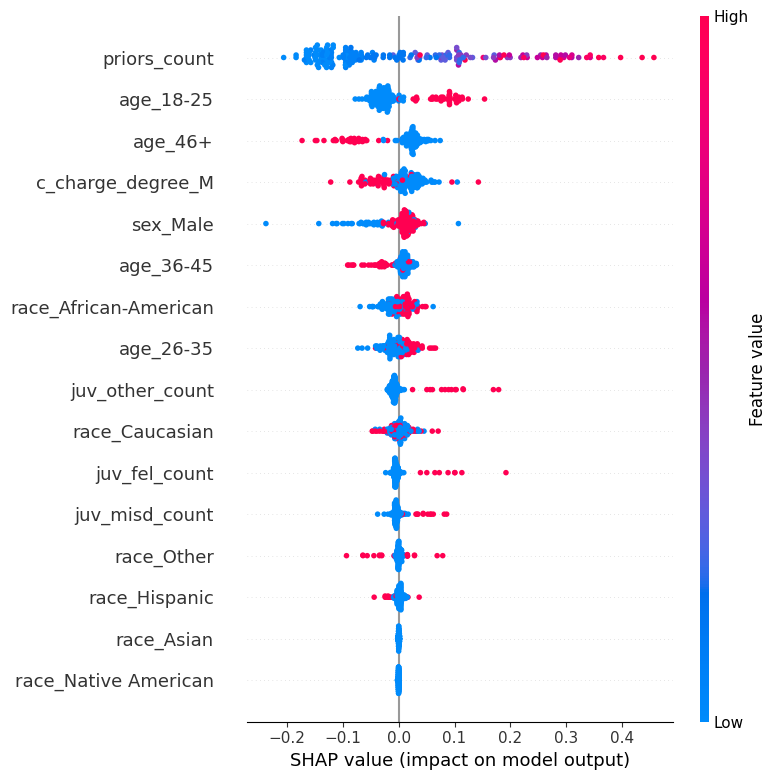

In [ ]:
# Two year RFC
import shap

X_sample = X[:200]

explainer = shap.TreeExplainer(model_5)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values[1], X_sample)


  0%|          | 0/200 [00:00<?, ?it/s]

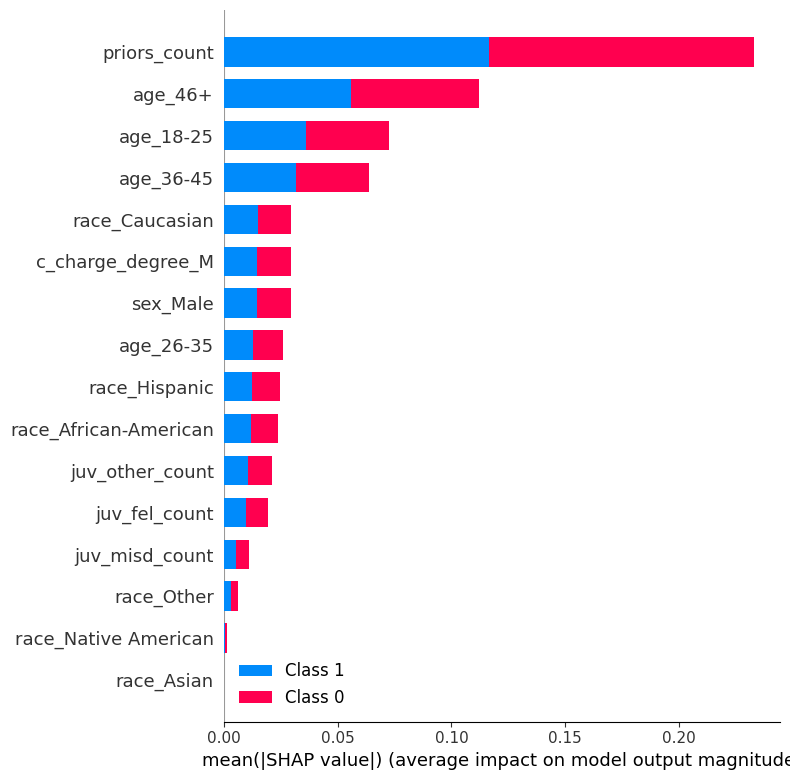

In [ ]:
# Two year nn
import shap

X_sample = shap.sample(X, 200, random_state=42)

explainer = shap.KernelExplainer(model_6.predict_proba, X_sample)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

# Fairlearn

### Sex

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

sensitive_attr = X_test['sex_Male']

model_predictions = {
    "XGB": y_pred_xgb,
    "SVC": y_pred_svm,
    "LR": y_pred_lr,
    "GBDT": y_pred_gbdt,
    "RFC": y_pred_rfc,
    "NN": y_pred_nn
}

for model_name, y_pred in model_predictions.items():
    metrics = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_attr)
    print(f"{model_name} Overall Accuracy: {metrics.overall}")
    print(f"{model_name} Accuracy by Group:\n{metrics.by_group}\n")


XGB Overall Accuracy: 0.6888426888426888
XGB Accuracy by Group:
sex_Male
0    0.716000
1    0.683152
Name: accuracy_score, dtype: float64

SVC Overall Accuracy: 0.6909216909216909
SVC Accuracy by Group:
sex_Male
0    0.732000
1    0.682313
Name: accuracy_score, dtype: float64

LR Overall Accuracy: 0.6888426888426888
LR Accuracy by Group:
sex_Male
0    0.716000
1    0.683152
Name: accuracy_score, dtype: float64

GBDT Overall Accuracy: 0.6874566874566874
GBDT Accuracy by Group:
sex_Male
0    0.712000
1    0.682313
Name: accuracy_score, dtype: float64

RFC Overall Accuracy: 0.6826056826056826
RFC Accuracy by Group:
sex_Male
0    0.712000
1    0.676446
Name: accuracy_score, dtype: float64

NN Overall Accuracy: 0.693000693000693
NN Accuracy by Group:
sex_Male
0    0.728000
1    0.685666
Name: accuracy_score, dtype: float64



### Race

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

sensitive_attr = X_test['race_African-American']

model_predictions = {
    "XGB": y_pred_xgb,
    "SVC": y_pred_svm,
    "LR": y_pred_lr,
    "GBDT": y_pred_gbdt,
    "RFC": y_pred_rfc,
    "NN": y_pred_nn
}

for model_name, y_pred in model_predictions.items():
    metrics = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_attr)
    print(f"{model_name} Overall Accuracy: {metrics.overall}")
    print(f"{model_name} Accuracy by Group:\n{metrics.by_group}\n")


XGB Overall Accuracy: 0.6888426888426888
XGB Accuracy by Group:
race_African-American
0    0.685393
1    0.692202
Name: accuracy_score, dtype: float64

SVC Overall Accuracy: 0.6909216909216909
SVC Accuracy by Group:
race_African-American
0    0.692416
1    0.689466
Name: accuracy_score, dtype: float64

LR Overall Accuracy: 0.6888426888426888
LR Accuracy by Group:
race_African-American
0    0.692416
1    0.685363
Name: accuracy_score, dtype: float64

GBDT Overall Accuracy: 0.6874566874566874
GBDT Accuracy by Group:
race_African-American
0    0.686798
1    0.688098
Name: accuracy_score, dtype: float64

RFC Overall Accuracy: 0.6826056826056826
RFC Accuracy by Group:
race_African-American
0    0.681180
1    0.683995
Name: accuracy_score, dtype: float64

NN Overall Accuracy: 0.693000693000693
NN Accuracy by Group:
race_African-American
0    0.693820
1    0.692202
Name: accuracy_score, dtype: float64



# LIME (Only useful for explaining individual row predictions)

In [ ]:
import lime
import lime.lime_tabular

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    mode='classification'
)

# Explain an instance (e.g., first row)
exp = explainer.explain_instance(X.iloc[0].values, model_1.predict_proba)
exp.show_in_notebook()

# In processing and post processing

In [53]:
!pip install scikit-posthocs aif360 xgboost

In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from aif360.metrics import ClassificationMetric
from aif360.algorithms.postprocessing import RejectOptionClassification, CalibratedEqOddsPostprocessing, EqOddsPostprocessing
from aif360.algorithms.inprocessing import AdversarialDebiasing
import tensorflow as tf
from aif360.datasets import BinaryLabelDataset
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

pip install 'aif360[inFairness]'


In [55]:
tf.compat.v1.disable_eager_execution()

def run_fairness_pipeline(model_name, X, y, protected_attr):
    # ----------------------------
    # Define branches and results storage
    # ----------------------------
    branches = ["Initial", "Adversarial", "ROC", "CEO", "EO", "ROC+Adv", "CEO+Adv", "EO+Adv"]
    results = {m: {"accuracy": [], "di": [], "eod": [], "fpr_diff": []} for m in branches}

    privileged_groups = [{protected_attr: 1}]
    unprivileged_groups = [{protected_attr: 0}]

    # ----------------------------
    # Metrics function
    # ----------------------------
    def compute_metrics(dataset_true, dataset_pred):
        metric = ClassificationMetric(dataset_true, dataset_pred, unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
        accuracy = accuracy_score(dataset_true.labels.ravel(), dataset_pred.labels.ravel())
        di = metric.disparate_impact()
        eod = metric.equal_opportunity_difference()
        fpr_diff = metric.false_positive_rate_difference()
        return accuracy, di, eod, fpr_diff

    # ----------------------------
    # Cross-validation
    # ----------------------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        df_train = pd.concat([X_train, y_train], axis=1)
        dataset_train = BinaryLabelDataset(df=df_train, label_names=[y.name], protected_attribute_names=[protected_attr])

        df_test = pd.concat([X_test, y_test], axis=1)
        dataset_test = BinaryLabelDataset(df=df_test, label_names=[y.name], protected_attribute_names=[protected_attr])

        # ----------------------------
        # Train the base model
        # ----------------------------
        if model_name == "xgb":
            import xgboost as xgb
            clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42, subsample=0.6, n_estimators=100, max_depth=3, learning_rate=0.05, colsample_bytree=0.8)
        elif model_name == "svc":
            from sklearn.svm import SVC
            clf = SVC(kernel='rbf', gamma=0.01, C=50, probability=True, random_state=42)
        elif model_name == "lr":
            from sklearn.linear_model import LogisticRegression
            clf = LogisticRegression(solver='liblinear', penalty='l2', max_iter=5000, C=0.01, random_state=42)
        elif model_name == "gbc":
            from sklearn.ensemble import GradientBoostingClassifier
            clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=4, min_samples_split=10, min_samples_leaf=4, subsample=0.6, random_state=42)
        elif model_name == "rfc":
            from sklearn.ensemble import RandomForestClassifier
            clf = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_split=10, min_samples_leaf=4, max_features='log2', random_state=42)
        elif model_name == "nn":
            from sklearn.neural_network import MLPClassifier
            clf = MLPClassifier(solver='adam', max_iter=500, learning_rate='adaptive', hidden_layer_sizes=(100,), alpha=0.001, activation='tanh', random_state=42)
        else:
            raise ValueError("Unsupported model. Choose from xgb, svc, lr, gbc, rfc, nn")

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        df_pred = pd.concat([X_test, pd.Series(y_pred, name=y.name, index=X_test.index)], axis=1)
        dataset_pred = BinaryLabelDataset(df=df_pred, label_names=[y.name], protected_attribute_names=[protected_attr])

        acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred)
        for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
            results["Initial"][k].append(v)

        tf.compat.v1.reset_default_graph()
        with tf.compat.v1.Session() as sess:
            adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name=f"adv_fold_{i}", debias=True, sess=sess)
            adv.fit(dataset_train)
            dataset_adv_pred = adv.predict(dataset_test)

        acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred)
        for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
            results["Adversarial"][k].append(v)

        # Post-processing
        dataset_pred_with_probs = dataset_test.copy(deepcopy=True)
        y_pred_probs = clf.predict_proba(X_test)[:, 1]
        dataset_pred_with_probs.scores = y_pred_probs.reshape(-1, 1)

        roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
        ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
        eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)

        datasets_for_post = [dataset_pred, dataset_pred_with_probs, dataset_pred]
        for name, post, pred_data in zip(["ROC", "CEO", "EO"], [roc, ceo, eo], datasets_for_post):
            post.fit(dataset_test, pred_data)
            dataset_post = post.predict(pred_data)
            acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_post)
            for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
                results[name][k].append(v)

        # The regular CEO is used here, which produces `inf` values for DI.
        for name, post, pred in zip(["ROC+Adv", "CEO+Adv", "EO+Adv"], [roc, ceo, eo], [dataset_adv_pred]*3):
            post.fit(dataset_test, pred)
            dataset_post = post.predict(pred)
            acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_post)
            for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
                results[name][k].append(v)

    # ----------------------------
    # This section safely handles `inf` and `nan` values.
    # ----------------------------
    def bootstrap_ci(data, n_bootstrap=1000, ci=95):
        # Filter out inf and nan values before bootstrapping
        data = np.array(data)[np.isfinite(data)]
        if len(data) == 0:
            return (np.nan, np.nan)

        boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
        lower = np.percentile(boot_means, (100 - ci) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
        return lower, upper

    print("\n--- Mean Metrics with 95% Confidence Intervals ---")
    for m in branches:
        if not results[m]["accuracy"]: continue

        # Replace inf with nan for safe calculation of means
        acc_scores = pd.Series(results[m]['accuracy']).replace([np.inf, -np.inf], np.nan)
        di_scores = pd.Series(results[m]['di']).replace([np.inf, -np.inf], np.nan)
        eod_scores = pd.Series(results[m]['eod']).replace([np.inf, -np.inf], np.nan)
        fpr_scores = pd.Series(results[m]['fpr_diff']).replace([np.inf, -np.inf], np.nan)

        # The bootstrap_ci function now handles filtering internally
        acc_ci = bootstrap_ci(results[m]["accuracy"])
        di_ci = bootstrap_ci(results[m]["di"])
        eod_ci = bootstrap_ci(results[m]["eod"])
        fpr_ci = bootstrap_ci(results[m]["fpr_diff"])

        print(f"\n{m}:")
        # Use .mean() on the cleaned Series for printing (it ignores NaN)
        print(f"  Accuracy: {acc_scores.mean():.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
        print(f"  DI:       {di_scores.mean():.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
        print(f"  EOD:      {eod_scores.mean():.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
        print(f"  FPR Diff: {fpr_scores.mean():.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

    # ----------------------------
    # Friedman & Nemenyi Tests (also made robust)
    # ----------------------------
    metrics_to_test = ["accuracy", "di", "eod", "fpr_diff"]
    for metric in metrics_to_test:
        # Create DataFrame, replace inf/nan, and drop rows with any nan for a clean test
        df_for_test = pd.DataFrame({m: results[m][metric] for m in branches})
        df_for_test.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_for_test.dropna(inplace=True) # Drop rows with NaN to ensure paired samples for Friedman

        if df_for_test.shape[0] < 2 or df_for_test.shape[1] < 2:
            print(f"\nSkipping Friedman Test for {metric.upper()} due to insufficient valid data after dropping NaNs.")
            continue

        friedman_res = friedmanchisquare(*[df_for_test[col].values for col in df_for_test.columns])
        print(f"\nFriedman Test ({metric.upper()}):", friedman_res)

        if friedman_res.pvalue < 0.05:
            nemenyi_res = sp.posthoc_nemenyi_friedman(df_for_test)
            alpha = 0.05
            significant_mask = nemenyi_res < alpha

            plt.figure(figsize=(10, 8))
            sns.heatmap(
                significant_mask, annot=nemenyi_res, fmt=".3f", cmap='Reds',
                cbar=True, linewidths=.5, linecolor='black'
            )
            plt.title(f"Nemenyi P-Values Heatmap ({metric.upper()})\nRed = Significant (p<{alpha})", fontsize=14)
            plt.xticks(rotation=45, ha="right")
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

    return results

## For sex


### XGB

epoch 0; iter: 0; batch classifier loss: 0.645437; batch adversarial loss: 0.879133
epoch 1; iter: 0; batch classifier loss: 0.640194; batch adversarial loss: 0.901767
epoch 2; iter: 0; batch classifier loss: 0.624603; batch adversarial loss: 0.820736
epoch 3; iter: 0; batch classifier loss: 0.614719; batch adversarial loss: 0.820484
epoch 4; iter: 0; batch classifier loss: 0.599964; batch adversarial loss: 0.750756
epoch 5; iter: 0; batch classifier loss: 0.605864; batch adversarial loss: 0.736105
epoch 6; iter: 0; batch classifier loss: 0.652399; batch adversarial loss: 0.699083
epoch 7; iter: 0; batch classifier loss: 0.589587; batch adversarial loss: 0.692556
epoch 8; iter: 0; batch classifier loss: 0.622420; batch adversarial loss: 0.681400
epoch 9; iter: 0; batch classifier loss: 0.628470; batch adversarial loss: 0.625354
epoch 10; iter: 0; batch classifier loss: 0.630000; batch adversarial loss: 0.619495
epoch 11; iter: 0; batch classifier loss: 0.599324; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.697959; batch adversarial loss: 0.666310
epoch 1; iter: 0; batch classifier loss: 0.613242; batch adversarial loss: 0.651962
epoch 2; iter: 0; batch classifier loss: 0.632541; batch adversarial loss: 0.632182
epoch 3; iter: 0; batch classifier loss: 0.635504; batch adversarial loss: 0.622532
epoch 4; iter: 0; batch classifier loss: 0.640858; batch adversarial loss: 0.597233
epoch 5; iter: 0; batch classifier loss: 0.657650; batch adversarial loss: 0.585968
epoch 6; iter: 0; batch classifier loss: 0.567929; batch adversarial loss: 0.583748
epoch 7; iter: 0; batch classifier loss: 0.631432; batch adversarial loss: 0.571404
epoch 8; iter: 0; batch classifier loss: 0.630477; batch adversarial loss: 0.569135
epoch 9; iter: 0; batch classifier loss: 0.615718; batch adversarial loss: 0.544920
epoch 10; iter: 0; batch classifier loss: 0.650793; batch adversarial loss: 0.584322
epoch 11; iter: 0; batch classifier loss: 0.678034; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.673052; batch adversarial loss: 0.789441
epoch 1; iter: 0; batch classifier loss: 0.600641; batch adversarial loss: 0.742290
epoch 2; iter: 0; batch classifier loss: 0.583679; batch adversarial loss: 0.732642
epoch 3; iter: 0; batch classifier loss: 0.606828; batch adversarial loss: 0.690072
epoch 4; iter: 0; batch classifier loss: 0.624625; batch adversarial loss: 0.691007
epoch 5; iter: 0; batch classifier loss: 0.604942; batch adversarial loss: 0.643815
epoch 6; iter: 0; batch classifier loss: 0.593025; batch adversarial loss: 0.630633
epoch 7; iter: 0; batch classifier loss: 0.621814; batch adversarial loss: 0.612014
epoch 8; iter: 0; batch classifier loss: 0.578212; batch adversarial loss: 0.586834
epoch 9; iter: 0; batch classifier loss: 0.602413; batch adversarial loss: 0.549633
epoch 10; iter: 0; batch classifier loss: 0.658983; batch adversarial loss: 0.561403
epoch 11; iter: 0; batch classifier loss: 0.692238; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")
/usr/local/lib/python3.12/dist-packages/aif360/metrics/dataset_metric.py:82: RuntimeWarning: divide by zero encountered in scalar divide
  return metric_fun(privileged=False) / metric_fun(privileged=True)


epoch 0; iter: 0; batch classifier loss: 0.732293; batch adversarial loss: 0.772551
epoch 1; iter: 0; batch classifier loss: 0.692338; batch adversarial loss: 0.734373
epoch 2; iter: 0; batch classifier loss: 0.650906; batch adversarial loss: 0.696794
epoch 3; iter: 0; batch classifier loss: 0.691070; batch adversarial loss: 0.674649
epoch 4; iter: 0; batch classifier loss: 0.642263; batch adversarial loss: 0.639800
epoch 5; iter: 0; batch classifier loss: 0.629008; batch adversarial loss: 0.632379
epoch 6; iter: 0; batch classifier loss: 0.645532; batch adversarial loss: 0.603042
epoch 7; iter: 0; batch classifier loss: 0.608305; batch adversarial loss: 0.600318
epoch 8; iter: 0; batch classifier loss: 0.666344; batch adversarial loss: 0.613762
epoch 9; iter: 0; batch classifier loss: 0.629871; batch adversarial loss: 0.602451
epoch 10; iter: 0; batch classifier loss: 0.660133; batch adversarial loss: 0.589749
epoch 11; iter: 0; batch classifier loss: 0.714894; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.673 (95% CI: 0.661-0.688)
  DI:       0.514 (95% CI: 0.461-0.589)
  EOD:      -0.205 (95% CI: -0.246--0.155)
  FPR Diff: -0.149 (95% CI: -0.191--0.101)

Adversarial:
  Accuracy: 0.653 (95% CI: 0.629-0.670)
  DI:       1.557 (95% CI: 0.907-2.405)
  EOD:      0.178 (95% CI: 0.029-0.376)
  FPR Diff: 0.209 (95% CI: -0.015-0.495)

ROC:
  Accuracy: 0.673 (95% CI: 0.661-0.687)
  DI:       0.514 (95% CI: 0.461-0.589)
  EOD:      -0.205 (95% CI: -0.246--0.157)
  FPR Diff: -0.149 (95% CI: -0.194--0.101)

CEO:
  Accuracy: 0.667 (95% CI: 0.657-0.680)
  DI:       0.263 (95% CI: 0.121-0.388)
  EOD:      -0.407 (95% CI: -0.509--0.325)
  FPR Diff: -0.207 (95% CI: -0.253--0.159)

EO:
  Accuracy: 0.638 (95% CI: 0.622-0.658)
  DI:       0.903 (95% CI: 0.867-0.934)
  EOD:      -0.004 (95% CI: -0.012-0.006)
  FPR Diff: -0.001 (95% CI: -0.009-0.005)

ROC+Adv:
  Accuracy: 0.630 (95% CI: 0.590-0.666)
  DI:       1.464 (95% CI: 0.956-2

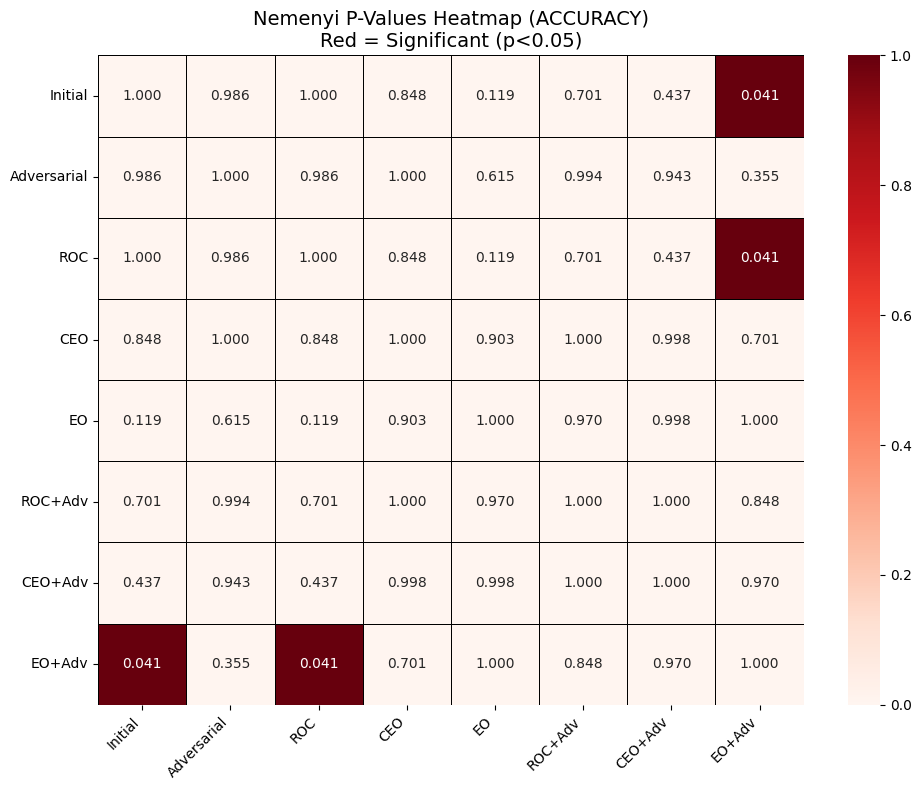


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(20.83081570996977), pvalue=np.float64(0.0040287887999476595))


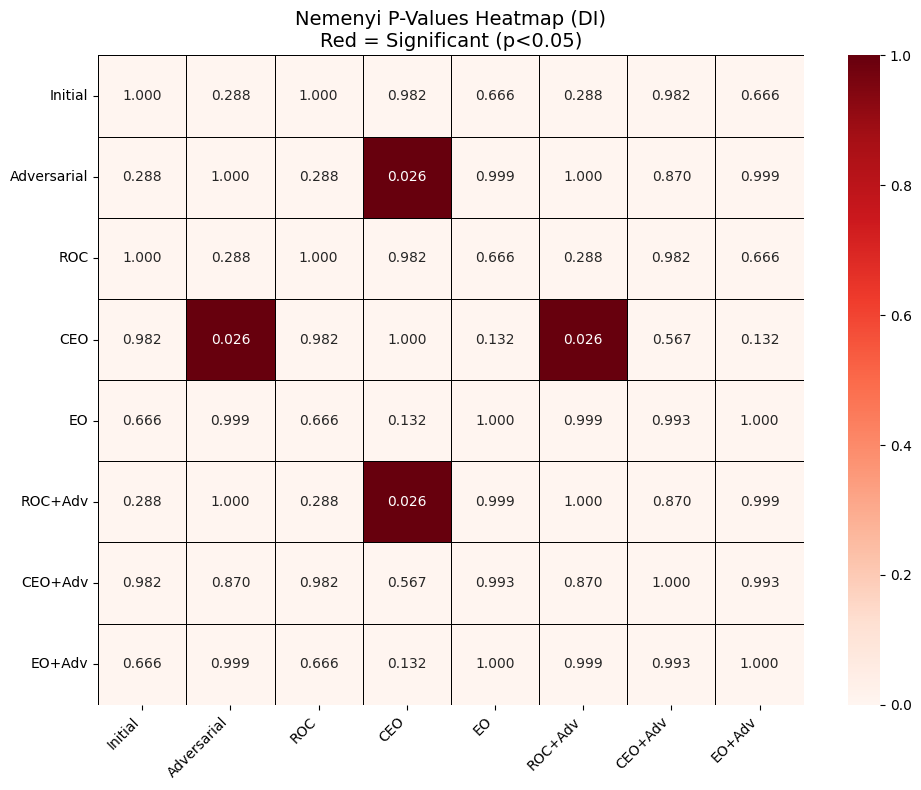


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(26.228915662650593), pvalue=np.float64(0.00045836152190469406))


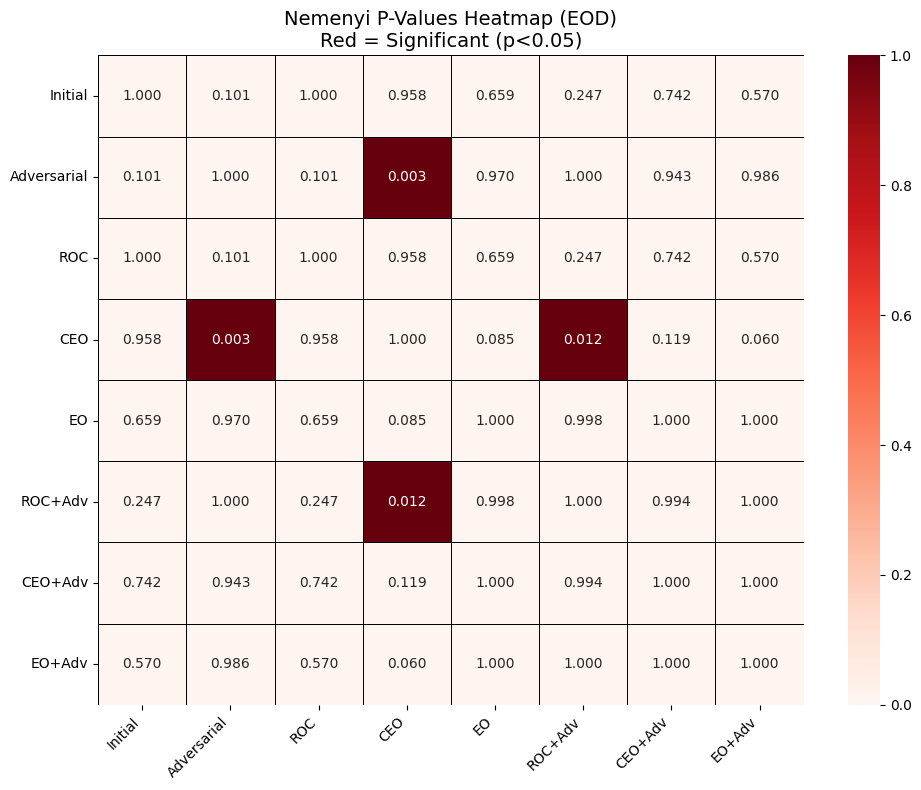


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(25.419277108433743), pvalue=np.float64(0.0006392552350268579))


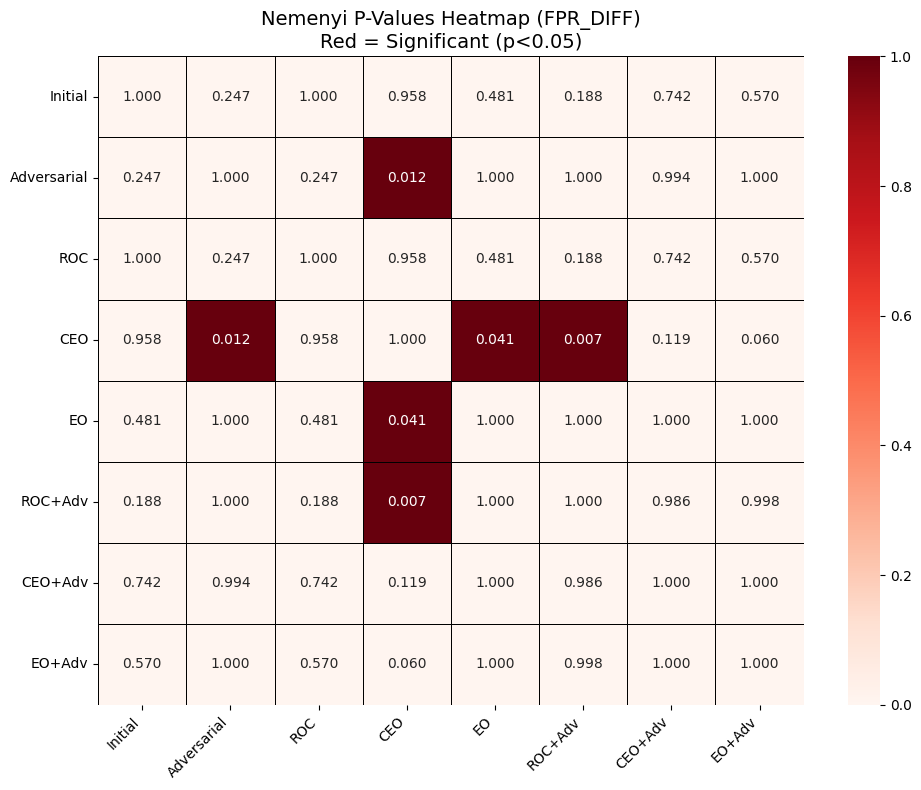

In [67]:
res_xgb_sex = run_fairness_pipeline("xgb", X, y, "sex_Male")

In [68]:
res_xgb_sex

{'Initial': {'accuracy': [0.6999306999306999,
   0.6701316701316701,
   0.6548856548856549,
   0.6618156618156619,
   0.6775312066574203],
  'di': [np.float64(0.658917061273617),
   np.float64(0.521505376344086),
   np.float64(0.4464150943396227),
   np.float64(0.46829930319235136),
   np.float64(0.47686510713805996)],
  'eod': [np.float64(-0.112268022294359),
   np.float64(-0.25766080482965625),
   np.float64(-0.2202750665483585),
   np.float64(-0.24613463939306635),
   np.float64(-0.18833833527286087)],
  'fpr_diff': [np.float64(-0.057498036695937726),
   np.float64(-0.1284864507600793),
   np.float64(-0.22436461818395256),
   np.float64(-0.17081260364842454),
   np.float64(-0.1654166666666667)]},
 'Adversarial': {'accuracy': [0.6604296604296604,
   0.674982674982675,
   0.6541926541926542,
   0.6070686070686071,
   0.6699029126213593],
  'di': [np.float64(1.866703600011871),
   np.float64(1.0628776241679467),
   np.float64(0.8012578616352202),
   np.float64(3.119341563786008),
   np

### SVC

epoch 0; iter: 0; batch classifier loss: 0.713769; batch adversarial loss: 0.647147
epoch 1; iter: 0; batch classifier loss: 0.643012; batch adversarial loss: 0.659712
epoch 2; iter: 0; batch classifier loss: 0.743456; batch adversarial loss: 0.641971
epoch 3; iter: 0; batch classifier loss: 0.596231; batch adversarial loss: 0.664880
epoch 4; iter: 0; batch classifier loss: 0.711640; batch adversarial loss: 0.651261
epoch 5; iter: 0; batch classifier loss: 0.849783; batch adversarial loss: 0.643452
epoch 6; iter: 0; batch classifier loss: 0.769200; batch adversarial loss: 0.619881
epoch 7; iter: 0; batch classifier loss: 0.724260; batch adversarial loss: 0.605072
epoch 8; iter: 0; batch classifier loss: 0.786404; batch adversarial loss: 0.605043
epoch 9; iter: 0; batch classifier loss: 0.678175; batch adversarial loss: 0.580898
epoch 10; iter: 0; batch classifier loss: 0.678943; batch adversarial loss: 0.591320
epoch 11; iter: 0; batch classifier loss: 0.833999; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.776229; batch adversarial loss: 0.617883
epoch 1; iter: 0; batch classifier loss: 0.602634; batch adversarial loss: 0.623321
epoch 2; iter: 0; batch classifier loss: 0.579345; batch adversarial loss: 0.565949
epoch 3; iter: 0; batch classifier loss: 0.646014; batch adversarial loss: 0.548091
epoch 4; iter: 0; batch classifier loss: 0.646233; batch adversarial loss: 0.579445
epoch 5; iter: 0; batch classifier loss: 0.621735; batch adversarial loss: 0.593794
epoch 6; iter: 0; batch classifier loss: 0.602865; batch adversarial loss: 0.584379
epoch 7; iter: 0; batch classifier loss: 0.648273; batch adversarial loss: 0.573200
epoch 8; iter: 0; batch classifier loss: 0.654313; batch adversarial loss: 0.575124
epoch 9; iter: 0; batch classifier loss: 0.650520; batch adversarial loss: 0.555686
epoch 10; iter: 0; batch classifier loss: 0.614976; batch adversarial loss: 0.559709
epoch 11; iter: 0; batch classifier loss: 0.603179; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.671202; batch adversarial loss: 0.794660
epoch 1; iter: 0; batch classifier loss: 0.635210; batch adversarial loss: 0.726778
epoch 2; iter: 0; batch classifier loss: 0.646074; batch adversarial loss: 0.702716
epoch 3; iter: 0; batch classifier loss: 0.616573; batch adversarial loss: 0.705100
epoch 4; iter: 0; batch classifier loss: 0.620062; batch adversarial loss: 0.648099
epoch 5; iter: 0; batch classifier loss: 0.564653; batch adversarial loss: 0.667706
epoch 6; iter: 0; batch classifier loss: 0.624184; batch adversarial loss: 0.614787
epoch 7; iter: 0; batch classifier loss: 0.633799; batch adversarial loss: 0.593648
epoch 8; iter: 0; batch classifier loss: 0.623987; batch adversarial loss: 0.593827
epoch 9; iter: 0; batch classifier loss: 0.621191; batch adversarial loss: 0.545237
epoch 10; iter: 0; batch classifier loss: 0.563285; batch adversarial loss: 0.574229
epoch 11; iter: 0; batch classifier loss: 0.616933; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.700107; batch adversarial loss: 0.605555
epoch 1; iter: 0; batch classifier loss: 0.640927; batch adversarial loss: 0.629001
epoch 2; iter: 0; batch classifier loss: 0.651875; batch adversarial loss: 0.625572
epoch 3; iter: 0; batch classifier loss: 0.652670; batch adversarial loss: 0.644470
epoch 4; iter: 0; batch classifier loss: 0.785890; batch adversarial loss: 0.608183
epoch 5; iter: 0; batch classifier loss: 0.813725; batch adversarial loss: 0.641384
epoch 6; iter: 0; batch classifier loss: 0.884374; batch adversarial loss: 0.651266
epoch 7; iter: 0; batch classifier loss: 0.883100; batch adversarial loss: 0.630106
epoch 8; iter: 0; batch classifier loss: 0.854828; batch adversarial loss: 0.623354
epoch 9; iter: 0; batch classifier loss: 0.818458; batch adversarial loss: 0.595965
epoch 10; iter: 0; batch classifier loss: 0.777633; batch adversarial loss: 0.610901
epoch 11; iter: 0; batch classifier loss: 0.669014; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.713061; batch adversarial loss: 0.740938
epoch 1; iter: 0; batch classifier loss: 0.568579; batch adversarial loss: 0.792407
epoch 2; iter: 0; batch classifier loss: 0.578933; batch adversarial loss: 0.748394
epoch 3; iter: 0; batch classifier loss: 0.583185; batch adversarial loss: 0.690772
epoch 4; iter: 0; batch classifier loss: 0.578904; batch adversarial loss: 0.686968
epoch 5; iter: 0; batch classifier loss: 0.603869; batch adversarial loss: 0.638306
epoch 6; iter: 0; batch classifier loss: 0.619861; batch adversarial loss: 0.633076
epoch 7; iter: 0; batch classifier loss: 0.607476; batch adversarial loss: 0.595469
epoch 8; iter: 0; batch classifier loss: 0.660254; batch adversarial loss: 0.578130
epoch 9; iter: 0; batch classifier loss: 0.630521; batch adversarial loss: 0.560011
epoch 10; iter: 0; batch classifier loss: 0.672019; batch adversarial loss: 0.531166
epoch 11; iter: 0; batch classifier loss: 0.599291; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.670 (95% CI: 0.660-0.681)
  DI:       0.528 (95% CI: 0.487-0.592)
  EOD:      -0.170 (95% CI: -0.224--0.119)
  FPR Diff: -0.122 (95% CI: -0.149--0.091)

Adversarial:
  Accuracy: 0.652 (95% CI: 0.631-0.673)
  DI:       1.666 (95% CI: 1.180-2.160)
  EOD:      0.223 (95% CI: 0.098-0.361)
  FPR Diff: 0.258 (95% CI: 0.077-0.430)

ROC:
  Accuracy: 0.670 (95% CI: 0.660-0.682)
  DI:       0.528 (95% CI: 0.486-0.591)
  EOD:      -0.170 (95% CI: -0.217--0.119)
  FPR Diff: -0.122 (95% CI: -0.150--0.089)

CEO:
  Accuracy: 0.667 (95% CI: 0.660-0.676)
  DI:       0.287 (95% CI: 0.119-0.427)
  EOD:      -0.363 (95% CI: -0.471--0.263)
  FPR Diff: -0.175 (95% CI: -0.218--0.136)

EO:
  Accuracy: 0.642 (95% CI: 0.628-0.657)
  DI:       0.893 (95% CI: 0.859-0.926)
  EOD:      -0.005 (95% CI: -0.017-0.002)
  FPR Diff: -0.001 (95% CI: -0.007-0.008)

ROC+Adv:
  Accuracy: 0.642 (95% CI: 0.604-0.678)
  DI:       1.423 (95% CI: 1.031-1.

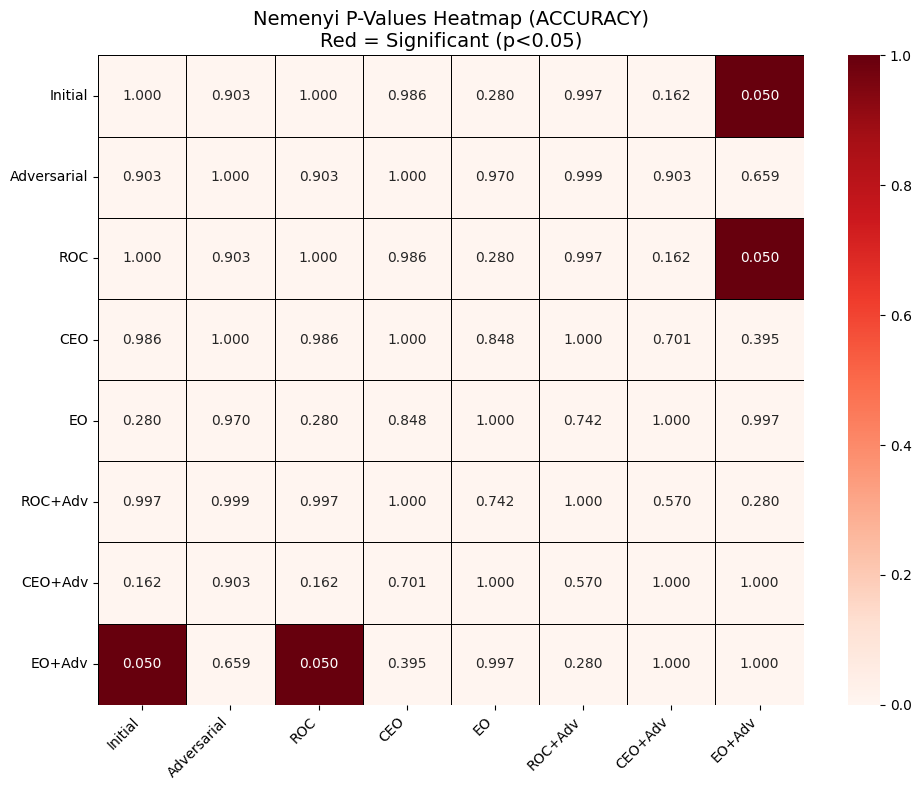


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(28.387951807228927), pvalue=np.float64(0.00018699249163034893))


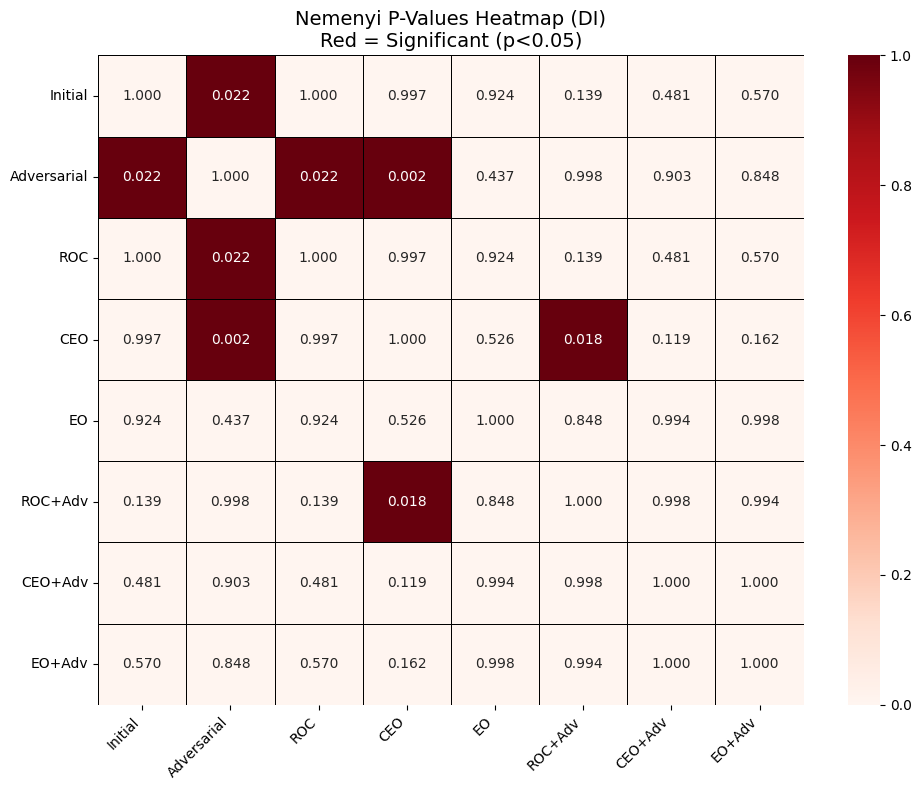


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(27.713253012048185), pvalue=np.float64(0.0002478111436506526))


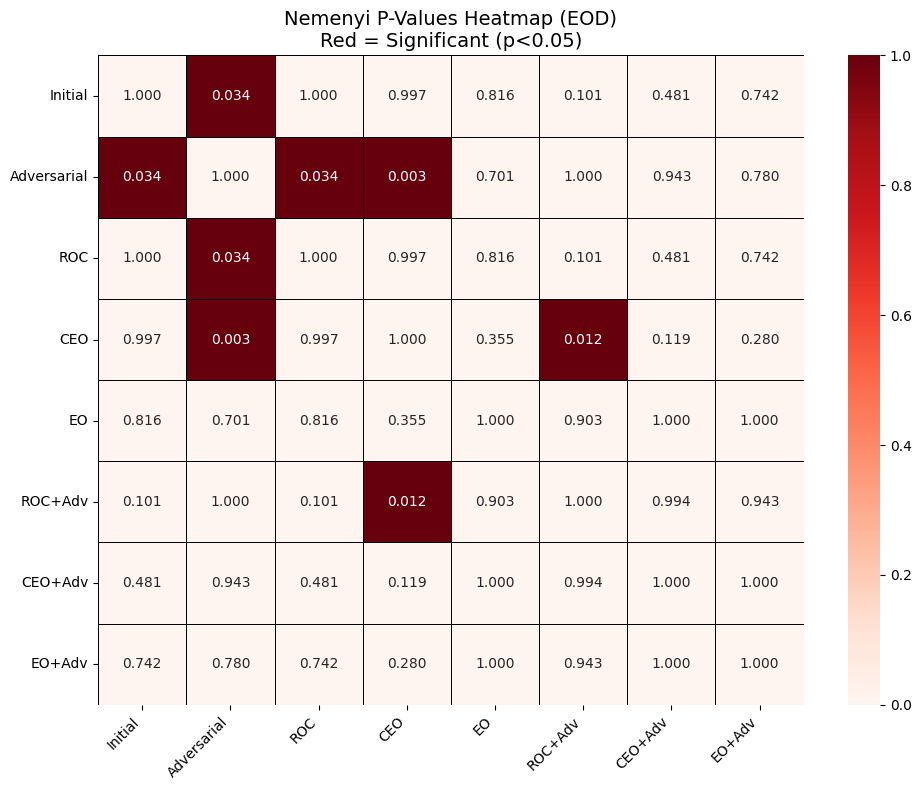


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(30.277108433734927), pvalue=np.float64(8.44640948005423e-05))


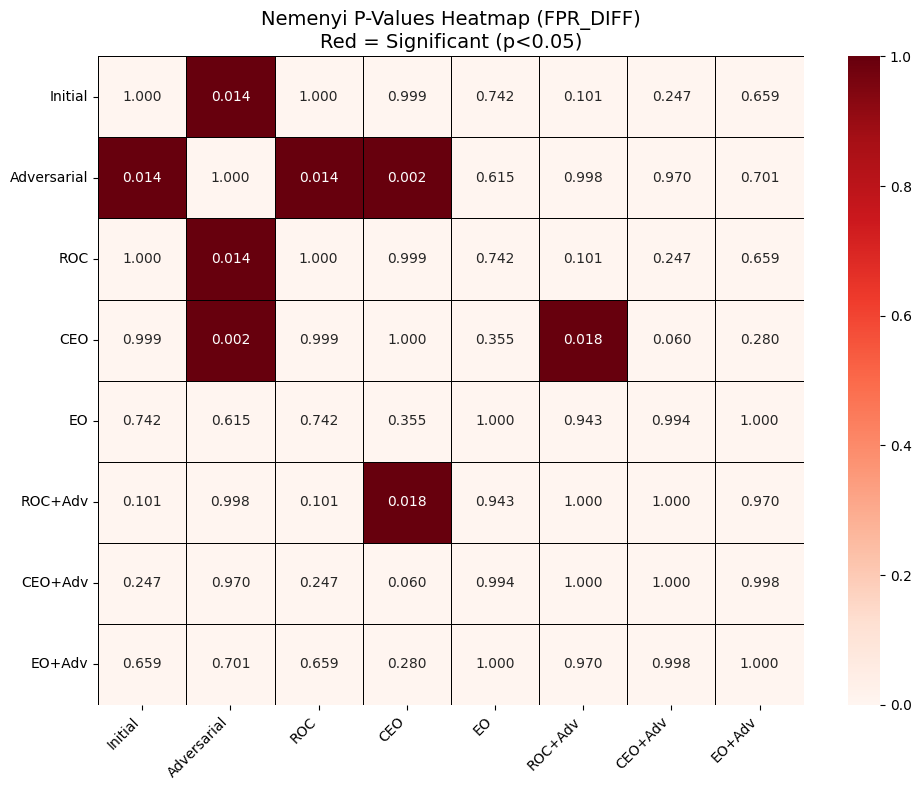

In [69]:
res_svc_sex = run_fairness_pipeline("svc", X, y, "sex_Male")

In [70]:
res_svc_sex

{'Initial': {'accuracy': [0.6909216909216909,
   0.6777546777546778,
   0.6548856548856549,
   0.6604296604296604,
   0.6678224687933426],
  'di': [np.float64(0.6487084870848709),
   np.float64(0.5046099537843425),
   np.float64(0.5101830663615561),
   np.float64(0.47211072664359865),
   np.float64(0.5046560267992745)],
  'eod': [np.float64(-0.09973254935587272),
   np.float64(-0.2538282826569892),
   np.float64(-0.14533422064477958),
   np.float64(-0.22414289830020162),
   np.float64(-0.12513015250811543)],
  'fpr_diff': [np.float64(-0.06395016777325624),
   np.float64(-0.11830799735624586),
   np.float64(-0.16381013871769287),
   np.float64(-0.13859275053304904),
   np.float64(-0.12645833333333334)]},
 'Adversarial': {'accuracy': [0.6770616770616771,
   0.6722106722106722,
   0.6195426195426196,
   0.6645876645876646,
   0.628987517337032],
  'di': [np.float64(1.2148099009079978),
   np.float64(1.2130668536699394),
   np.float64(2.3664879356568362),
   np.float64(1.1288160833953833),

### Logistic Regression

epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.697959; batch adversarial loss: 0.666310
epoch 1; iter: 0; batch classifier loss: 0.613242; batch adversarial loss: 0.651962
epoch 2; iter: 0; batch classifier loss: 0.632541; batch adversarial loss: 0.632182
epoch 3; iter: 0; batch classifier loss: 0.635504; batch adversarial loss: 0.622532
epoch 4; iter: 0; batch classifier loss: 0.640858; batch adversarial loss: 0.597233
epoch 5; iter: 0; batch classifier loss: 0.657650; batch adversarial loss: 0.585968
epoch 6; iter: 0; batch classifier loss: 0.567929; batch adversarial loss: 0.583748
epoch 7; iter: 0; batch classifier loss: 0.631432; batch adversarial loss: 0.571404
epoch 8; iter: 0; batch classifier loss: 0.630477; batch adversarial loss: 0.569135
epoch 9; iter: 0; batch classifier loss: 0.615718; batch adversarial loss: 0.544920
epoch 10; iter: 0; batch classifier loss: 0.650793; batch adversarial loss: 0.584322
epoch 11; iter: 0; batch classifier loss: 0.678034; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.673052; batch adversarial loss: 0.789441
epoch 1; iter: 0; batch classifier loss: 0.600641; batch adversarial loss: 0.742290
epoch 2; iter: 0; batch classifier loss: 0.583679; batch adversarial loss: 0.732642
epoch 3; iter: 0; batch classifier loss: 0.606828; batch adversarial loss: 0.690072
epoch 4; iter: 0; batch classifier loss: 0.624625; batch adversarial loss: 0.691007
epoch 5; iter: 0; batch classifier loss: 0.604942; batch adversarial loss: 0.643815
epoch 6; iter: 0; batch classifier loss: 0.593025; batch adversarial loss: 0.630633
epoch 7; iter: 0; batch classifier loss: 0.621814; batch adversarial loss: 0.612014
epoch 8; iter: 0; batch classifier loss: 0.578212; batch adversarial loss: 0.586834
epoch 9; iter: 0; batch classifier loss: 0.602413; batch adversarial loss: 0.549633
epoch 10; iter: 0; batch classifier loss: 0.658983; batch adversarial loss: 0.561403
epoch 11; iter: 0; batch classifier loss: 0.692238; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")
/usr/local/lib/python3.12/dist-packages/aif360/metrics/dataset_metric.py:82: RuntimeWarning: divide by zero encountered in scalar divide
  return metric_fun(privileged=False) / metric_fun(privileged=True)


epoch 0; iter: 0; batch classifier loss: 0.732293; batch adversarial loss: 0.772551
epoch 1; iter: 0; batch classifier loss: 0.692338; batch adversarial loss: 0.734373
epoch 2; iter: 0; batch classifier loss: 0.650906; batch adversarial loss: 0.696794
epoch 3; iter: 0; batch classifier loss: 0.691070; batch adversarial loss: 0.674649
epoch 4; iter: 0; batch classifier loss: 0.642263; batch adversarial loss: 0.639800
epoch 5; iter: 0; batch classifier loss: 0.629008; batch adversarial loss: 0.632379
epoch 6; iter: 0; batch classifier loss: 0.645532; batch adversarial loss: 0.603042
epoch 7; iter: 0; batch classifier loss: 0.608305; batch adversarial loss: 0.600318
epoch 8; iter: 0; batch classifier loss: 0.666344; batch adversarial loss: 0.613762
epoch 9; iter: 0; batch classifier loss: 0.629871; batch adversarial loss: 0.602451
epoch 10; iter: 0; batch classifier loss: 0.660133; batch adversarial loss: 0.589749
epoch 11; iter: 0; batch classifier loss: 0.714894; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.675 (95% CI: 0.665-0.685)
  DI:       0.533 (95% CI: 0.497-0.586)
  EOD:      -0.173 (95% CI: -0.230--0.119)
  FPR Diff: -0.112 (95% CI: -0.131--0.090)

Adversarial:
  Accuracy: 0.656 (95% CI: 0.629-0.672)
  DI:       1.453 (95% CI: 0.907-2.301)
  EOD:      0.155 (95% CI: 0.019-0.339)
  FPR Diff: 0.169 (95% CI: -0.015-0.455)

ROC:
  Accuracy: 0.675 (95% CI: 0.665-0.685)
  DI:       0.533 (95% CI: 0.497-0.586)
  EOD:      -0.173 (95% CI: -0.230--0.119)
  FPR Diff: -0.112 (95% CI: -0.131--0.092)

CEO:
  Accuracy: 0.666 (95% CI: 0.658-0.674)
  DI:       0.316 (95% CI: 0.130-0.514)
  EOD:      -0.336 (95% CI: -0.466--0.206)
  FPR Diff: -0.148 (95% CI: -0.194--0.105)

EO:
  Accuracy: 0.644 (95% CI: 0.630-0.660)
  DI:       0.890 (95% CI: 0.856-0.922)
  EOD:      0.000 (95% CI: -0.012-0.013)
  FPR Diff: -0.003 (95% CI: -0.013-0.008)

ROC+Adv:
  Accuracy: 0.646 (95% CI: 0.606-0.667)
  DI:       1.307 (95% CI: 0.949-1.

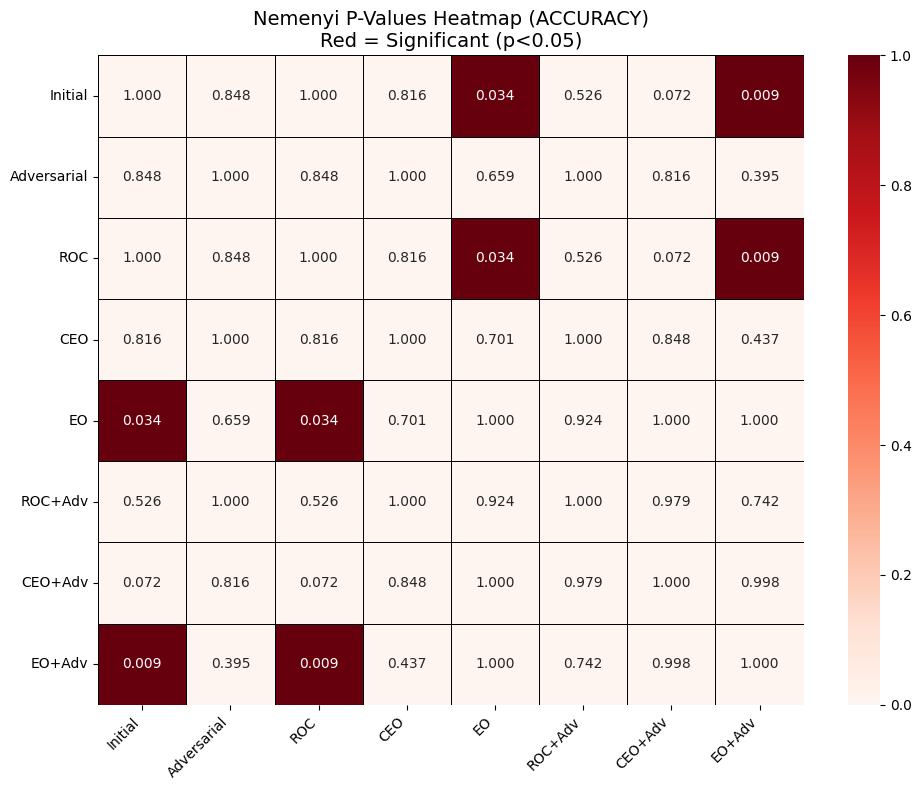


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(22.861027190332305), pvalue=np.float64(0.0018022276521250484))


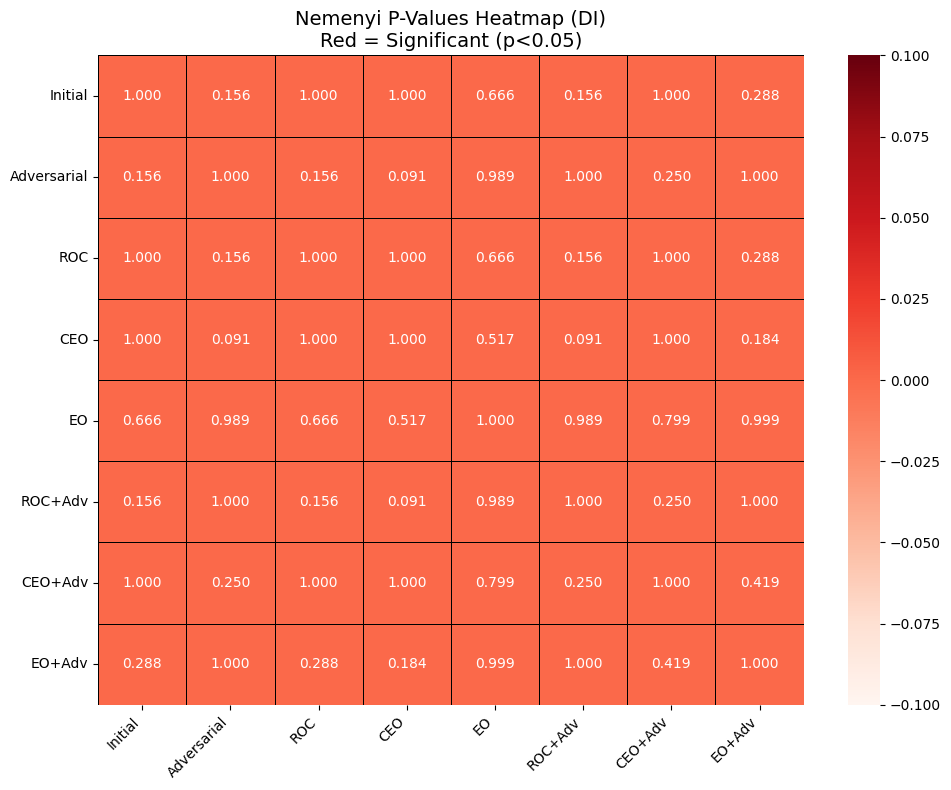


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(25.216867469879507), pvalue=np.float64(0.0006944621536876244))


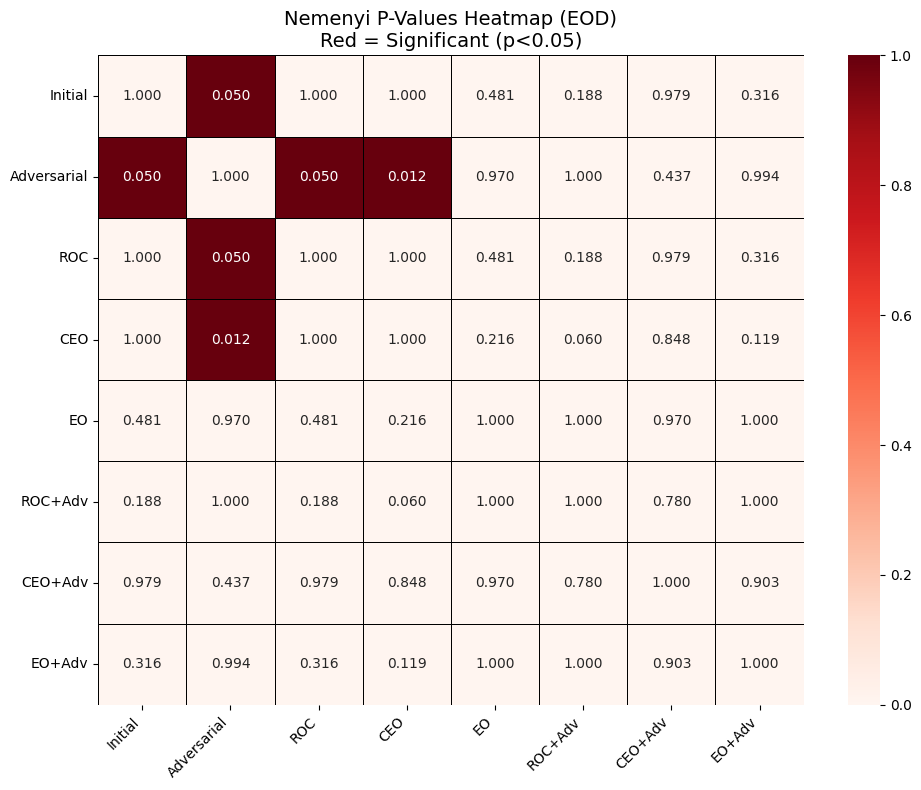


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(25.351807228915675), pvalue=np.float64(0.000657161597355263))


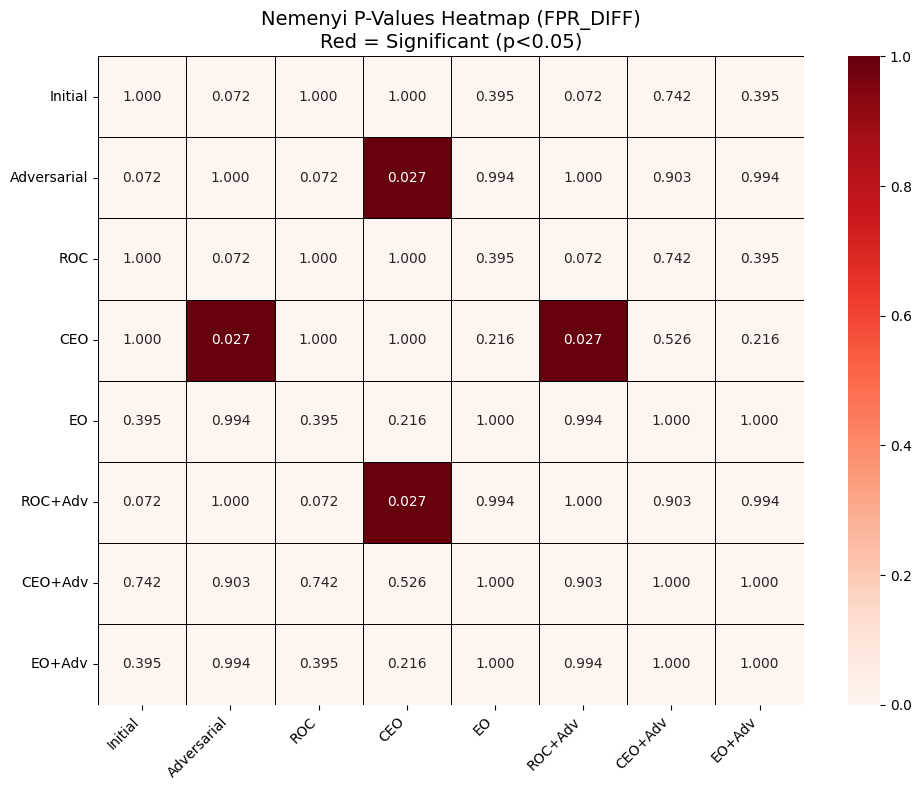

In [71]:
res_lr_sex = run_fairness_pipeline("lr", X, y, "sex_Male")

In [72]:
res_lr_sex

{'Initial': {'accuracy': [0.6916146916146916,
   0.6812196812196812,
   0.6618156618156619,
   0.6611226611226612,
   0.680998613037448],
  'di': [np.float64(0.6336222431991761),
   np.float64(0.48101201771030994),
   np.float64(0.5214606741573033),
   np.float64(0.5180524132730014),
   np.float64(0.5092687198949059)],
  'eod': [np.float64(-0.08907535575018888),
   np.float64(-0.26095066899557395),
   np.float64(-0.18748151434486843),
   np.float64(-0.2099779122251032),
   np.float64(-0.11822951756803662)],
  'fpr_diff': [np.float64(-0.07368637110016421),
   np.float64(-0.10064205457463885),
   np.float64(-0.1327796364774706),
   np.float64(-0.11276948590381428),
   np.float64(-0.138125)]},
 'Adversarial': {'accuracy': [0.6715176715176715,
   0.674982674982675,
   0.6541926541926542,
   0.6070686070686071,
   0.6699029126213593],
  'di': [np.float64(1.3446618499798444),
   np.float64(1.0628776241679467),
   np.float64(0.8012578616352202),
   np.float64(3.119341563786008),
   np.float64

### GBDT

epoch 0; iter: 0; batch classifier loss: 0.713769; batch adversarial loss: 0.647147
epoch 1; iter: 0; batch classifier loss: 0.643012; batch adversarial loss: 0.659712
epoch 2; iter: 0; batch classifier loss: 0.743456; batch adversarial loss: 0.641971
epoch 3; iter: 0; batch classifier loss: 0.596231; batch adversarial loss: 0.664880
epoch 4; iter: 0; batch classifier loss: 0.711640; batch adversarial loss: 0.651261
epoch 5; iter: 0; batch classifier loss: 0.849783; batch adversarial loss: 0.643452
epoch 6; iter: 0; batch classifier loss: 0.769200; batch adversarial loss: 0.619881
epoch 7; iter: 0; batch classifier loss: 0.724260; batch adversarial loss: 0.605072
epoch 8; iter: 0; batch classifier loss: 0.786404; batch adversarial loss: 0.605043
epoch 9; iter: 0; batch classifier loss: 0.678175; batch adversarial loss: 0.580898
epoch 10; iter: 0; batch classifier loss: 0.678943; batch adversarial loss: 0.591320
epoch 11; iter: 0; batch classifier loss: 0.833999; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.776229; batch adversarial loss: 0.617883
epoch 1; iter: 0; batch classifier loss: 0.602634; batch adversarial loss: 0.623321
epoch 2; iter: 0; batch classifier loss: 0.579345; batch adversarial loss: 0.565949
epoch 3; iter: 0; batch classifier loss: 0.646014; batch adversarial loss: 0.548091
epoch 4; iter: 0; batch classifier loss: 0.646233; batch adversarial loss: 0.579445
epoch 5; iter: 0; batch classifier loss: 0.621735; batch adversarial loss: 0.593794
epoch 6; iter: 0; batch classifier loss: 0.602865; batch adversarial loss: 0.584379
epoch 7; iter: 0; batch classifier loss: 0.648273; batch adversarial loss: 0.573200
epoch 8; iter: 0; batch classifier loss: 0.654313; batch adversarial loss: 0.575124
epoch 9; iter: 0; batch classifier loss: 0.650520; batch adversarial loss: 0.555686
epoch 10; iter: 0; batch classifier loss: 0.614976; batch adversarial loss: 0.559709
epoch 11; iter: 0; batch classifier loss: 0.603179; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.671202; batch adversarial loss: 0.794660
epoch 1; iter: 0; batch classifier loss: 0.635210; batch adversarial loss: 0.726778
epoch 2; iter: 0; batch classifier loss: 0.646074; batch adversarial loss: 0.702716
epoch 3; iter: 0; batch classifier loss: 0.616573; batch adversarial loss: 0.705100
epoch 4; iter: 0; batch classifier loss: 0.620062; batch adversarial loss: 0.648099
epoch 5; iter: 0; batch classifier loss: 0.564653; batch adversarial loss: 0.667706
epoch 6; iter: 0; batch classifier loss: 0.624184; batch adversarial loss: 0.614787
epoch 7; iter: 0; batch classifier loss: 0.633799; batch adversarial loss: 0.593648
epoch 8; iter: 0; batch classifier loss: 0.623987; batch adversarial loss: 0.593827
epoch 9; iter: 0; batch classifier loss: 0.621191; batch adversarial loss: 0.545237
epoch 10; iter: 0; batch classifier loss: 0.563285; batch adversarial loss: 0.574229
epoch 11; iter: 0; batch classifier loss: 0.616933; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.700107; batch adversarial loss: 0.605555
epoch 1; iter: 0; batch classifier loss: 0.640927; batch adversarial loss: 0.629001
epoch 2; iter: 0; batch classifier loss: 0.651875; batch adversarial loss: 0.625572
epoch 3; iter: 0; batch classifier loss: 0.652670; batch adversarial loss: 0.644470
epoch 4; iter: 0; batch classifier loss: 0.785890; batch adversarial loss: 0.608183
epoch 5; iter: 0; batch classifier loss: 0.813725; batch adversarial loss: 0.641384
epoch 6; iter: 0; batch classifier loss: 0.884374; batch adversarial loss: 0.651266
epoch 7; iter: 0; batch classifier loss: 0.883100; batch adversarial loss: 0.630106
epoch 8; iter: 0; batch classifier loss: 0.854828; batch adversarial loss: 0.623354
epoch 9; iter: 0; batch classifier loss: 0.818458; batch adversarial loss: 0.595965
epoch 10; iter: 0; batch classifier loss: 0.777633; batch adversarial loss: 0.610901
epoch 11; iter: 0; batch classifier loss: 0.669014; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.713061; batch adversarial loss: 0.740938
epoch 1; iter: 0; batch classifier loss: 0.568579; batch adversarial loss: 0.792407
epoch 2; iter: 0; batch classifier loss: 0.578933; batch adversarial loss: 0.748394
epoch 3; iter: 0; batch classifier loss: 0.583185; batch adversarial loss: 0.690772
epoch 4; iter: 0; batch classifier loss: 0.578904; batch adversarial loss: 0.686968
epoch 5; iter: 0; batch classifier loss: 0.603869; batch adversarial loss: 0.638306
epoch 6; iter: 0; batch classifier loss: 0.619861; batch adversarial loss: 0.633076
epoch 7; iter: 0; batch classifier loss: 0.607476; batch adversarial loss: 0.595469
epoch 8; iter: 0; batch classifier loss: 0.660254; batch adversarial loss: 0.578130
epoch 9; iter: 0; batch classifier loss: 0.630521; batch adversarial loss: 0.560011
epoch 10; iter: 0; batch classifier loss: 0.672019; batch adversarial loss: 0.531166
epoch 11; iter: 0; batch classifier loss: 0.599291; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.660-0.688)
  DI:       0.557 (95% CI: 0.525-0.613)
  EOD:      -0.169 (95% CI: -0.218--0.126)
  FPR Diff: -0.127 (95% CI: -0.160--0.092)

Adversarial:
  Accuracy: 0.652 (95% CI: 0.631-0.673)
  DI:       1.666 (95% CI: 1.180-2.160)
  EOD:      0.223 (95% CI: 0.098-0.361)
  FPR Diff: 0.258 (95% CI: 0.077-0.430)

ROC:
  Accuracy: 0.674 (95% CI: 0.660-0.689)
  DI:       0.557 (95% CI: 0.521-0.613)
  EOD:      -0.169 (95% CI: -0.212--0.126)
  FPR Diff: -0.127 (95% CI: -0.162--0.089)

CEO:
  Accuracy: 0.667 (95% CI: 0.655-0.681)
  DI:       0.239 (95% CI: 0.087-0.376)
  EOD:      -0.411 (95% CI: -0.518--0.312)
  FPR Diff: -0.200 (95% CI: -0.232--0.162)

EO:
  Accuracy: 0.649 (95% CI: 0.635-0.663)
  DI:       0.897 (95% CI: 0.860-0.931)
  EOD:      -0.014 (95% CI: -0.026--0.003)
  FPR Diff: 0.005 (95% CI: -0.003-0.013)

ROC+Adv:
  Accuracy: 0.642 (95% CI: 0.604-0.678)
  DI:       1.423 (95% CI: 1.031-1.

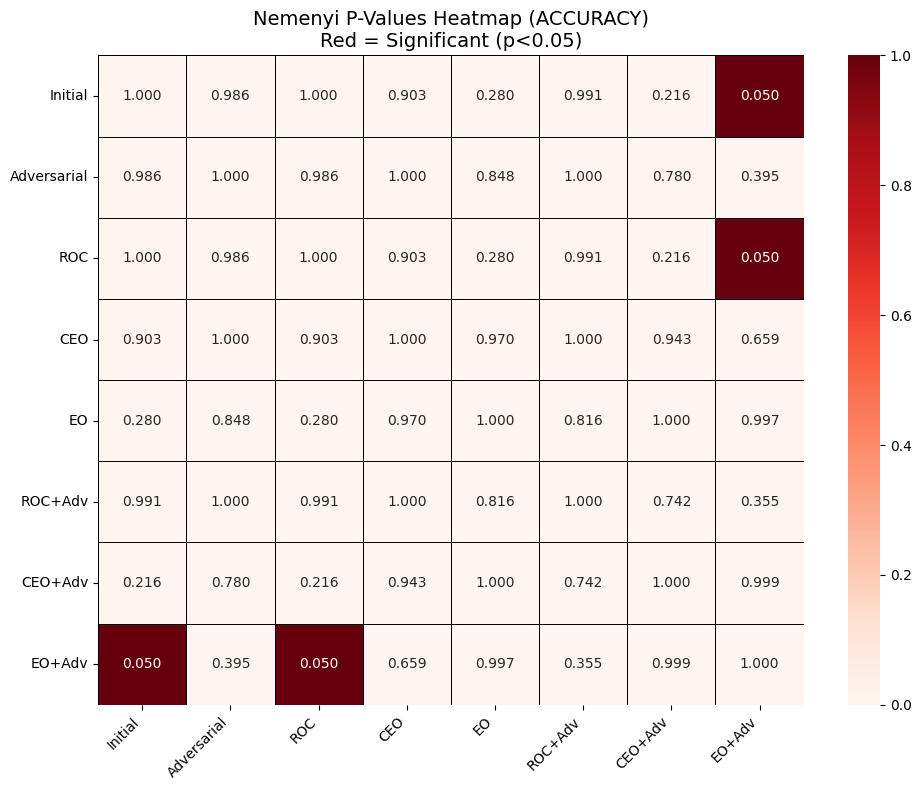


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.332530120481913), pvalue=np.float64(0.00012581500763606316))


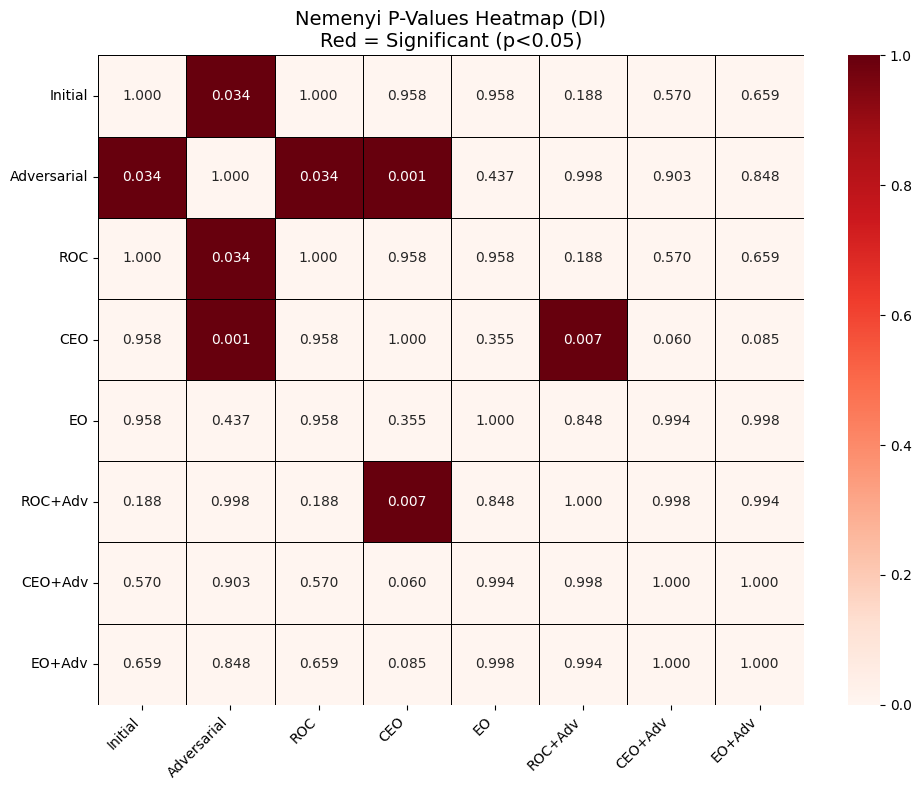


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(28.792771084337335), pvalue=np.float64(0.00015783121449875165))


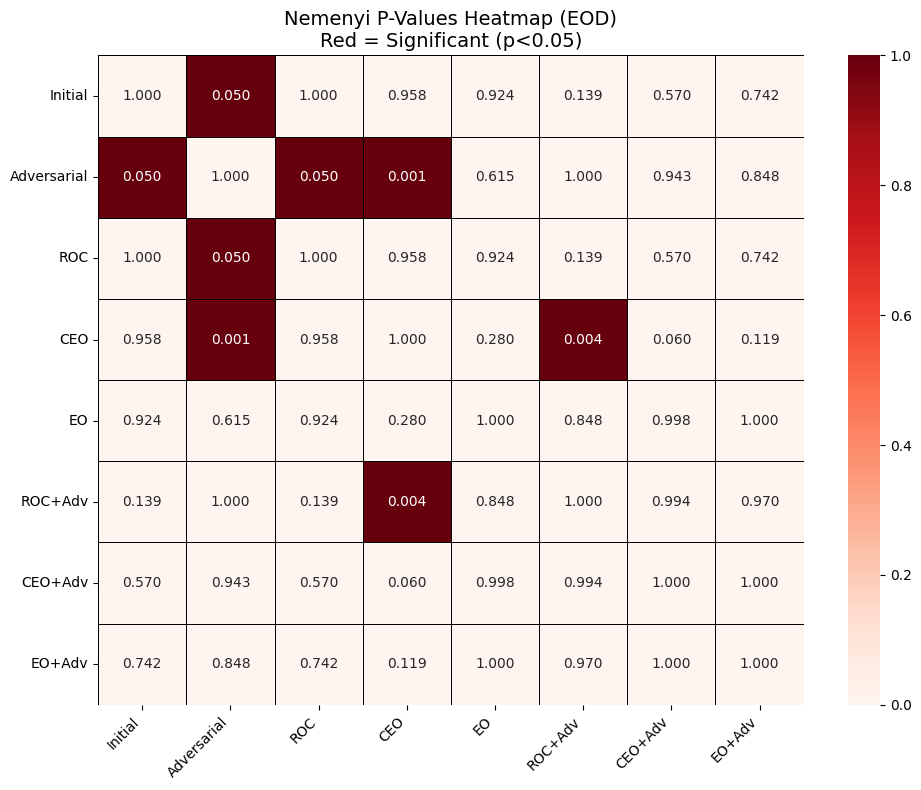


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(31.08674698795181), pvalue=np.float64(5.992465065032899e-05))


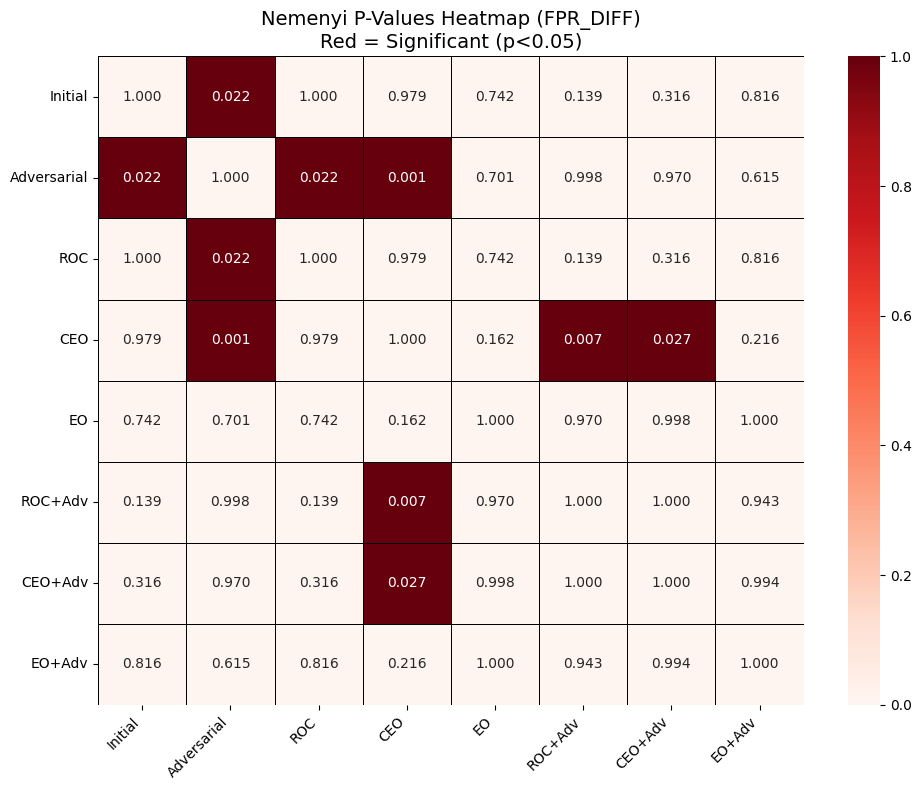

In [73]:
res_gbc_sex = run_fairness_pipeline("gbc", X, y, "sex_Male")

In [74]:
res_gbc_sex

{'Initial': {'accuracy': [0.7006237006237006,
   0.6701316701316701,
   0.6534996534996536,
   0.6618156618156619,
   0.6816920943134536],
  'di': [np.float64(0.6625107953207191),
   np.float64(0.5353130543328296),
   np.float64(0.5076842105263157),
   np.float64(0.5387348969438521),
   np.float64(0.5418122525040764)],
  'eod': [np.float64(-0.10432616728935712),
   np.float64(-0.25396394715867654),
   np.float64(-0.15753475303164743),
   np.float64(-0.19696533179679243),
   np.float64(-0.1307649905065229)],
  'fpr_diff': [np.float64(-0.06078210894552724),
   np.float64(-0.11778868850911148),
   np.float64(-0.1831601807830017),
   np.float64(-0.1433309642264866),
   np.float64(-0.13187499999999996)]},
 'Adversarial': {'accuracy': [0.6770616770616771,
   0.6722106722106722,
   0.6195426195426196,
   0.6645876645876646,
   0.628987517337032],
  'di': [np.float64(1.2148099009079978),
   np.float64(1.2130668536699394),
   np.float64(2.3664879356568362),
   np.float64(1.1288160833953833),
  

### RFC

epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.585935
epoch 1; iter: 0; batch classifier loss: 0.657426; batch adversarial loss: 0.607571
epoch 2; iter: 0; batch classifier loss: 0.591998; batch adversarial loss: 0.600377
epoch 3; iter: 0; batch classifier loss: 0.605133; batch adversarial loss: 0.585645
epoch 4; iter: 0; batch classifier loss: 0.616304; batch adversarial loss: 0.609877
epoch 5; iter: 0; batch classifier loss: 0.622045; batch adversarial loss: 0.557337
epoch 6; iter: 0; batch classifier loss: 0.642985; batch adversarial loss: 0.583589
epoch 7; iter: 0; batch classifier loss: 0.621800; batch adversarial loss: 0.607946
epoch 8; iter: 0; batch classifier loss: 0.642276; batch adversarial loss: 0.521051
epoch 9; iter: 0; batch classifier loss: 0.619024; batch adversarial loss: 0.531483
epoch 10; iter: 0; batch classifier loss: 0.668658; batch adversarial loss: 0.548250
epoch 11; iter: 0; batch classifier loss: 0.624746; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.730588; batch adversarial loss: 0.621733
epoch 1; iter: 0; batch classifier loss: 0.641159; batch adversarial loss: 0.631607
epoch 2; iter: 0; batch classifier loss: 0.596055; batch adversarial loss: 0.621092
epoch 3; iter: 0; batch classifier loss: 0.707927; batch adversarial loss: 0.607444
epoch 4; iter: 0; batch classifier loss: 0.700827; batch adversarial loss: 0.632701
epoch 5; iter: 0; batch classifier loss: 0.816398; batch adversarial loss: 0.658219
epoch 6; iter: 0; batch classifier loss: 0.727763; batch adversarial loss: 0.664440
epoch 7; iter: 0; batch classifier loss: 0.800366; batch adversarial loss: 0.651914
epoch 8; iter: 0; batch classifier loss: 0.864803; batch adversarial loss: 0.667581
epoch 9; iter: 0; batch classifier loss: 0.877841; batch adversarial loss: 0.604628
epoch 10; iter: 0; batch classifier loss: 0.731456; batch adversarial loss: 0.606697
epoch 11; iter: 0; batch classifier loss: 0.680835; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.697959; batch adversarial loss: 0.666310
epoch 1; iter: 0; batch classifier loss: 0.613242; batch adversarial loss: 0.651962
epoch 2; iter: 0; batch classifier loss: 0.632541; batch adversarial loss: 0.632182
epoch 3; iter: 0; batch classifier loss: 0.635504; batch adversarial loss: 0.622532
epoch 4; iter: 0; batch classifier loss: 0.640858; batch adversarial loss: 0.597233
epoch 5; iter: 0; batch classifier loss: 0.657650; batch adversarial loss: 0.585968
epoch 6; iter: 0; batch classifier loss: 0.567929; batch adversarial loss: 0.583748
epoch 7; iter: 0; batch classifier loss: 0.631432; batch adversarial loss: 0.571404
epoch 8; iter: 0; batch classifier loss: 0.630477; batch adversarial loss: 0.569135
epoch 9; iter: 0; batch classifier loss: 0.615718; batch adversarial loss: 0.544920
epoch 10; iter: 0; batch classifier loss: 0.650793; batch adversarial loss: 0.584322
epoch 11; iter: 0; batch classifier loss: 0.678034; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.673052; batch adversarial loss: 0.789441
epoch 1; iter: 0; batch classifier loss: 0.600641; batch adversarial loss: 0.742290
epoch 2; iter: 0; batch classifier loss: 0.583679; batch adversarial loss: 0.732642
epoch 3; iter: 0; batch classifier loss: 0.606828; batch adversarial loss: 0.690072
epoch 4; iter: 0; batch classifier loss: 0.624625; batch adversarial loss: 0.691007
epoch 5; iter: 0; batch classifier loss: 0.604942; batch adversarial loss: 0.643815
epoch 6; iter: 0; batch classifier loss: 0.593025; batch adversarial loss: 0.630633
epoch 7; iter: 0; batch classifier loss: 0.621814; batch adversarial loss: 0.612014
epoch 8; iter: 0; batch classifier loss: 0.578212; batch adversarial loss: 0.586834
epoch 9; iter: 0; batch classifier loss: 0.602413; batch adversarial loss: 0.549633
epoch 10; iter: 0; batch classifier loss: 0.658983; batch adversarial loss: 0.561403
epoch 11; iter: 0; batch classifier loss: 0.692238; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")
/usr/local/lib/python3.12/dist-packages/aif360/metrics/dataset_metric.py:82: RuntimeWarning: divide by zero encountered in scalar divide
  return metric_fun(privileged=False) / metric_fun(privileged=True)


epoch 0; iter: 0; batch classifier loss: 0.732293; batch adversarial loss: 0.772551
epoch 1; iter: 0; batch classifier loss: 0.692338; batch adversarial loss: 0.734373
epoch 2; iter: 0; batch classifier loss: 0.650906; batch adversarial loss: 0.696794
epoch 3; iter: 0; batch classifier loss: 0.691070; batch adversarial loss: 0.674649
epoch 4; iter: 0; batch classifier loss: 0.642263; batch adversarial loss: 0.639800
epoch 5; iter: 0; batch classifier loss: 0.629008; batch adversarial loss: 0.632379
epoch 6; iter: 0; batch classifier loss: 0.645532; batch adversarial loss: 0.603042
epoch 7; iter: 0; batch classifier loss: 0.608305; batch adversarial loss: 0.600318
epoch 8; iter: 0; batch classifier loss: 0.666344; batch adversarial loss: 0.613762
epoch 9; iter: 0; batch classifier loss: 0.629871; batch adversarial loss: 0.602451
epoch 10; iter: 0; batch classifier loss: 0.660133; batch adversarial loss: 0.589749
epoch 11; iter: 0; batch classifier loss: 0.714894; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.669 (95% CI: 0.654-0.686)
  DI:       0.568 (95% CI: 0.522-0.620)
  EOD:      -0.155 (95% CI: -0.187--0.126)
  FPR Diff: -0.129 (95% CI: -0.163--0.092)

Adversarial:
  Accuracy: 0.656 (95% CI: 0.629-0.672)
  DI:       1.453 (95% CI: 0.907-2.301)
  EOD:      0.155 (95% CI: 0.019-0.339)
  FPR Diff: 0.169 (95% CI: -0.015-0.455)

ROC:
  Accuracy: 0.669 (95% CI: 0.655-0.684)
  DI:       0.568 (95% CI: 0.522-0.623)
  EOD:      -0.155 (95% CI: -0.187--0.123)
  FPR Diff: -0.129 (95% CI: -0.163--0.092)

CEO:
  Accuracy: 0.662 (95% CI: 0.650-0.678)
  DI:       0.271 (95% CI: 0.110-0.432)
  EOD:      -0.385 (95% CI: -0.499--0.271)
  FPR Diff: -0.193 (95% CI: -0.225--0.158)

EO:
  Accuracy: 0.644 (95% CI: 0.632-0.659)
  DI:       0.901 (95% CI: 0.867-0.931)
  EOD:      0.000 (95% CI: -0.018-0.013)
  FPR Diff: -0.004 (95% CI: -0.014-0.009)

ROC+Adv:
  Accuracy: 0.646 (95% CI: 0.606-0.667)
  DI:       1.307 (95% CI: 0.949-1.

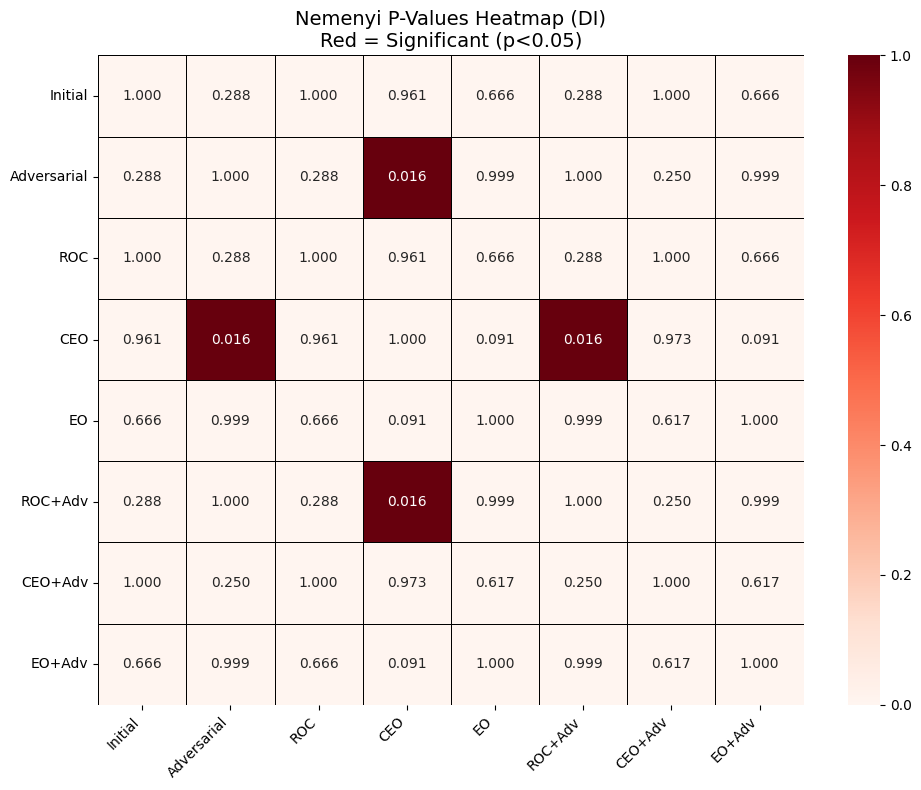


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(26.903614457831335), pvalue=np.float64(0.00034685741953251236))


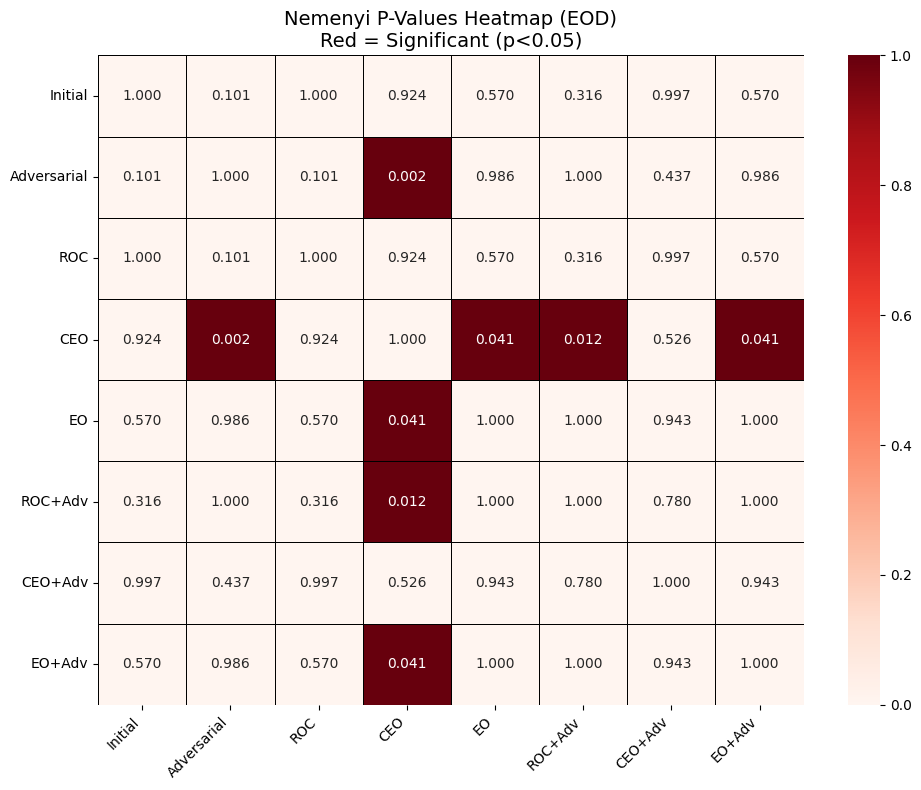


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(26.903614457831335), pvalue=np.float64(0.00034685741953251236))


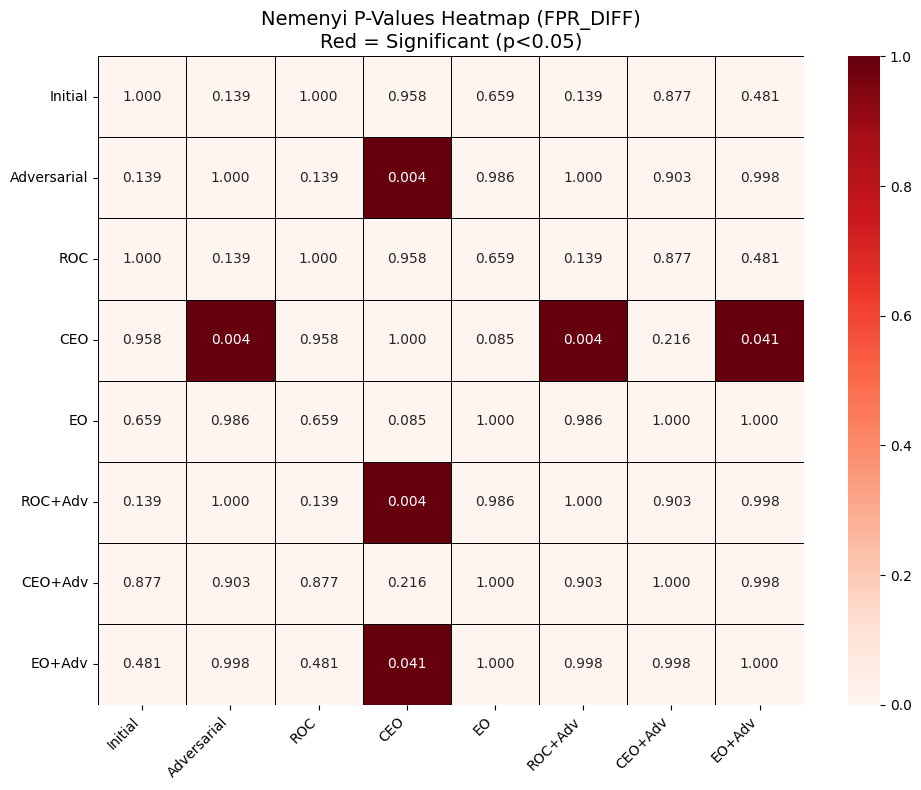

In [75]:
res_rfc_sex = run_fairness_pipeline("rfc", X, y, "sex_Male")

In [76]:
res_rfc_sex

{'Initial': {'accuracy': [0.6985446985446986,
   0.6666666666666666,
   0.6458766458766458,
   0.659043659043659,
   0.673370319001387],
  'di': [np.float64(0.6688660954406155),
   np.float64(0.592217969746674),
   np.float64(0.5309859154929578),
   np.float64(0.54549436795995),
   np.float64(0.500579111298931)],
  'eod': [np.float64(-0.10432616728935712),
   np.float64(-0.19138869575539685),
   np.float64(-0.16001183081928427),
   np.float64(-0.19509267262076246),
   np.float64(-0.12355811437087855)],
  'fpr_diff': [np.float64(-0.05863139858642108),
   np.float64(-0.10976300632612593),
   np.float64(-0.18224061356655122),
   np.float64(-0.1413567085208876),
   np.float64(-0.15458333333333332)]},
 'Adversarial': {'accuracy': [0.6715176715176715,
   0.674982674982675,
   0.6541926541926542,
   0.6070686070686071,
   0.6699029126213593],
  'di': [np.float64(1.3446618499798444),
   np.float64(1.0628776241679467),
   np.float64(0.8012578616352202),
   np.float64(3.119341563786008),
   np.f

### NN (MLPClassifier)

epoch 0; iter: 0; batch classifier loss: 0.713769; batch adversarial loss: 0.647147
epoch 1; iter: 0; batch classifier loss: 0.643012; batch adversarial loss: 0.659712
epoch 2; iter: 0; batch classifier loss: 0.743456; batch adversarial loss: 0.641971
epoch 3; iter: 0; batch classifier loss: 0.596231; batch adversarial loss: 0.664880
epoch 4; iter: 0; batch classifier loss: 0.711640; batch adversarial loss: 0.651261
epoch 5; iter: 0; batch classifier loss: 0.849783; batch adversarial loss: 0.643452
epoch 6; iter: 0; batch classifier loss: 0.769200; batch adversarial loss: 0.619881
epoch 7; iter: 0; batch classifier loss: 0.724260; batch adversarial loss: 0.605072
epoch 8; iter: 0; batch classifier loss: 0.786404; batch adversarial loss: 0.605043
epoch 9; iter: 0; batch classifier loss: 0.678175; batch adversarial loss: 0.580898
epoch 10; iter: 0; batch classifier loss: 0.678943; batch adversarial loss: 0.591320
epoch 11; iter: 0; batch classifier loss: 0.833999; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.776229; batch adversarial loss: 0.617883
epoch 1; iter: 0; batch classifier loss: 0.602634; batch adversarial loss: 0.623321
epoch 2; iter: 0; batch classifier loss: 0.579345; batch adversarial loss: 0.565949
epoch 3; iter: 0; batch classifier loss: 0.646014; batch adversarial loss: 0.548091
epoch 4; iter: 0; batch classifier loss: 0.646233; batch adversarial loss: 0.579445
epoch 5; iter: 0; batch classifier loss: 0.621735; batch adversarial loss: 0.593794
epoch 6; iter: 0; batch classifier loss: 0.602865; batch adversarial loss: 0.584379
epoch 7; iter: 0; batch classifier loss: 0.648273; batch adversarial loss: 0.573200
epoch 8; iter: 0; batch classifier loss: 0.654313; batch adversarial loss: 0.575124
epoch 9; iter: 0; batch classifier loss: 0.650520; batch adversarial loss: 0.555686
epoch 10; iter: 0; batch classifier loss: 0.614976; batch adversarial loss: 0.559709
epoch 11; iter: 0; batch classifier loss: 0.603179; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.671202; batch adversarial loss: 0.794660
epoch 1; iter: 0; batch classifier loss: 0.635210; batch adversarial loss: 0.726778
epoch 2; iter: 0; batch classifier loss: 0.646074; batch adversarial loss: 0.702716
epoch 3; iter: 0; batch classifier loss: 0.616573; batch adversarial loss: 0.705100
epoch 4; iter: 0; batch classifier loss: 0.620062; batch adversarial loss: 0.648099
epoch 5; iter: 0; batch classifier loss: 0.564653; batch adversarial loss: 0.667706
epoch 6; iter: 0; batch classifier loss: 0.624184; batch adversarial loss: 0.614787
epoch 7; iter: 0; batch classifier loss: 0.633799; batch adversarial loss: 0.593648
epoch 8; iter: 0; batch classifier loss: 0.623987; batch adversarial loss: 0.593827
epoch 9; iter: 0; batch classifier loss: 0.621191; batch adversarial loss: 0.545237
epoch 10; iter: 0; batch classifier loss: 0.563285; batch adversarial loss: 0.574229
epoch 11; iter: 0; batch classifier loss: 0.616933; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.700107; batch adversarial loss: 0.605555
epoch 1; iter: 0; batch classifier loss: 0.640927; batch adversarial loss: 0.629001
epoch 2; iter: 0; batch classifier loss: 0.651875; batch adversarial loss: 0.625572
epoch 3; iter: 0; batch classifier loss: 0.652670; batch adversarial loss: 0.644470
epoch 4; iter: 0; batch classifier loss: 0.785890; batch adversarial loss: 0.608183
epoch 5; iter: 0; batch classifier loss: 0.813725; batch adversarial loss: 0.641384
epoch 6; iter: 0; batch classifier loss: 0.884374; batch adversarial loss: 0.651266
epoch 7; iter: 0; batch classifier loss: 0.883100; batch adversarial loss: 0.630106
epoch 8; iter: 0; batch classifier loss: 0.854828; batch adversarial loss: 0.623354
epoch 9; iter: 0; batch classifier loss: 0.818458; batch adversarial loss: 0.595965
epoch 10; iter: 0; batch classifier loss: 0.777633; batch adversarial loss: 0.610901
epoch 11; iter: 0; batch classifier loss: 0.669014; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.713061; batch adversarial loss: 0.740938
epoch 1; iter: 0; batch classifier loss: 0.568579; batch adversarial loss: 0.792407
epoch 2; iter: 0; batch classifier loss: 0.578933; batch adversarial loss: 0.748394
epoch 3; iter: 0; batch classifier loss: 0.583185; batch adversarial loss: 0.690772
epoch 4; iter: 0; batch classifier loss: 0.578904; batch adversarial loss: 0.686968
epoch 5; iter: 0; batch classifier loss: 0.603869; batch adversarial loss: 0.638306
epoch 6; iter: 0; batch classifier loss: 0.619861; batch adversarial loss: 0.633076
epoch 7; iter: 0; batch classifier loss: 0.607476; batch adversarial loss: 0.595469
epoch 8; iter: 0; batch classifier loss: 0.660254; batch adversarial loss: 0.578130
epoch 9; iter: 0; batch classifier loss: 0.630521; batch adversarial loss: 0.560011
epoch 10; iter: 0; batch classifier loss: 0.672019; batch adversarial loss: 0.531166
epoch 11; iter: 0; batch classifier loss: 0.599291; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.510 (95% CI: 0.466-0.590)
  EOD:      -0.200 (95% CI: -0.255--0.148)
  FPR Diff: -0.139 (95% CI: -0.177--0.097)

Adversarial:
  Accuracy: 0.652 (95% CI: 0.631-0.673)
  DI:       1.666 (95% CI: 1.180-2.160)
  EOD:      0.223 (95% CI: 0.098-0.361)
  FPR Diff: 0.258 (95% CI: 0.077-0.430)

ROC:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.510 (95% CI: 0.465-0.590)
  EOD:      -0.200 (95% CI: -0.250--0.145)
  FPR Diff: -0.139 (95% CI: -0.178--0.090)

CEO:
  Accuracy: 0.669 (95% CI: 0.660-0.678)
  DI:       0.262 (95% CI: 0.156-0.356)
  EOD:      -0.391 (95% CI: -0.465--0.325)
  FPR Diff: -0.193 (95% CI: -0.236--0.151)

EO:
  Accuracy: 0.642 (95% CI: 0.625-0.663)
  DI:       0.895 (95% CI: 0.860-0.926)
  EOD:      -0.009 (95% CI: -0.021-0.003)
  FPR Diff: 0.003 (95% CI: -0.006-0.009)

ROC+Adv:
  Accuracy: 0.642 (95% CI: 0.604-0.678)
  DI:       1.423 (95% CI: 1.031-1.9

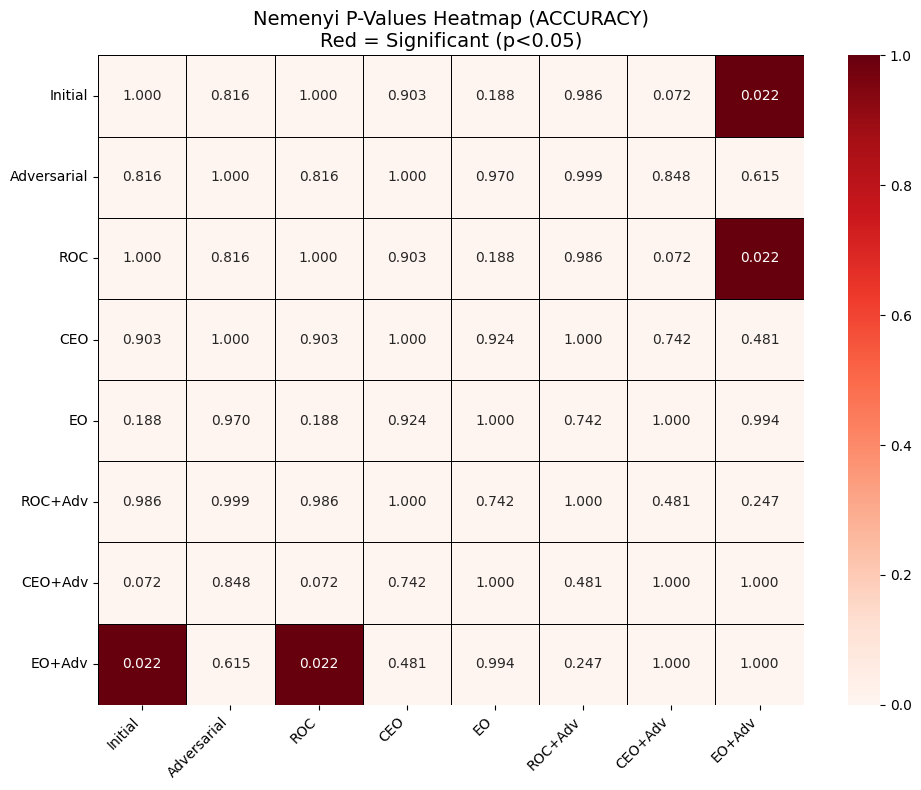


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.332530120481913), pvalue=np.float64(0.00012581500763606316))


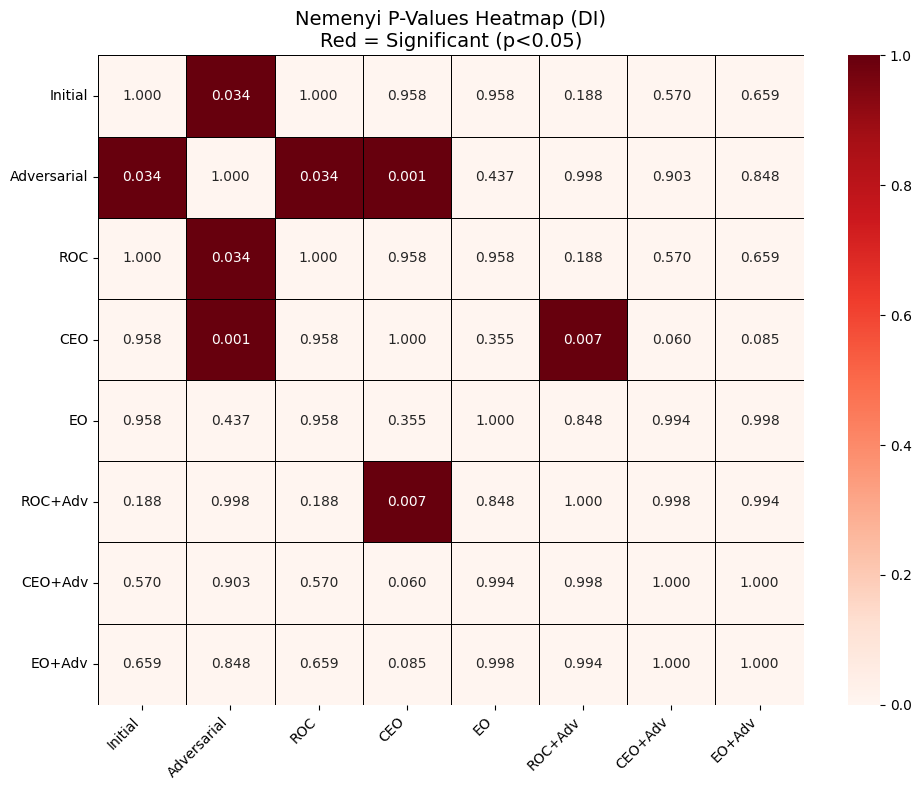


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(28.6578313253012), pvalue=np.float64(0.00016701571425251001))


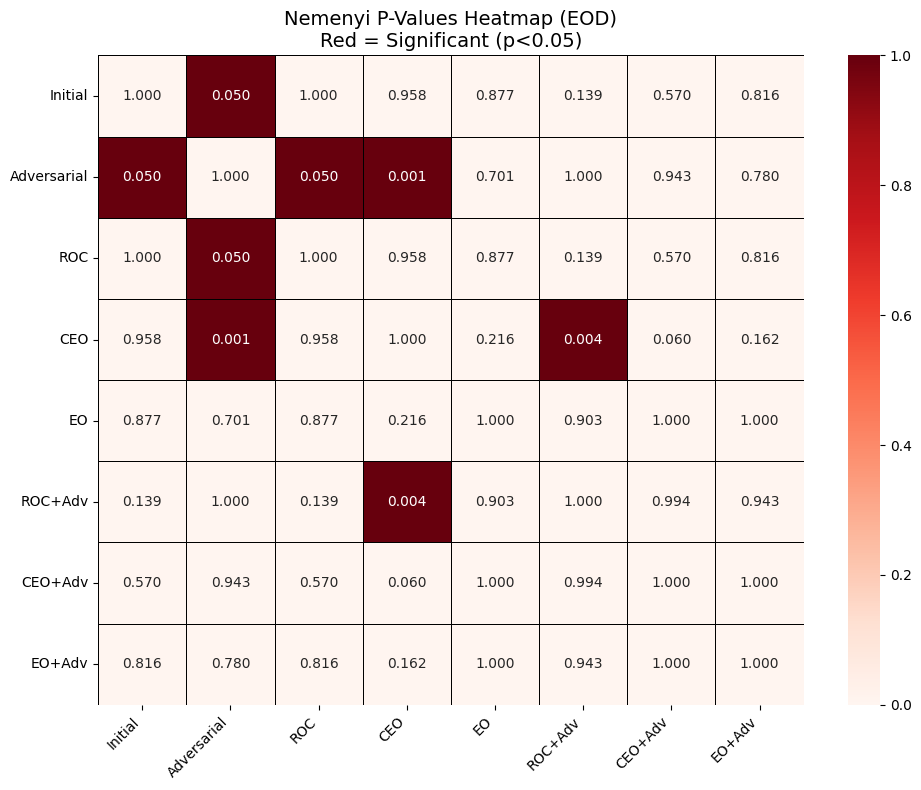


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(31.08674698795181), pvalue=np.float64(5.992465065032899e-05))


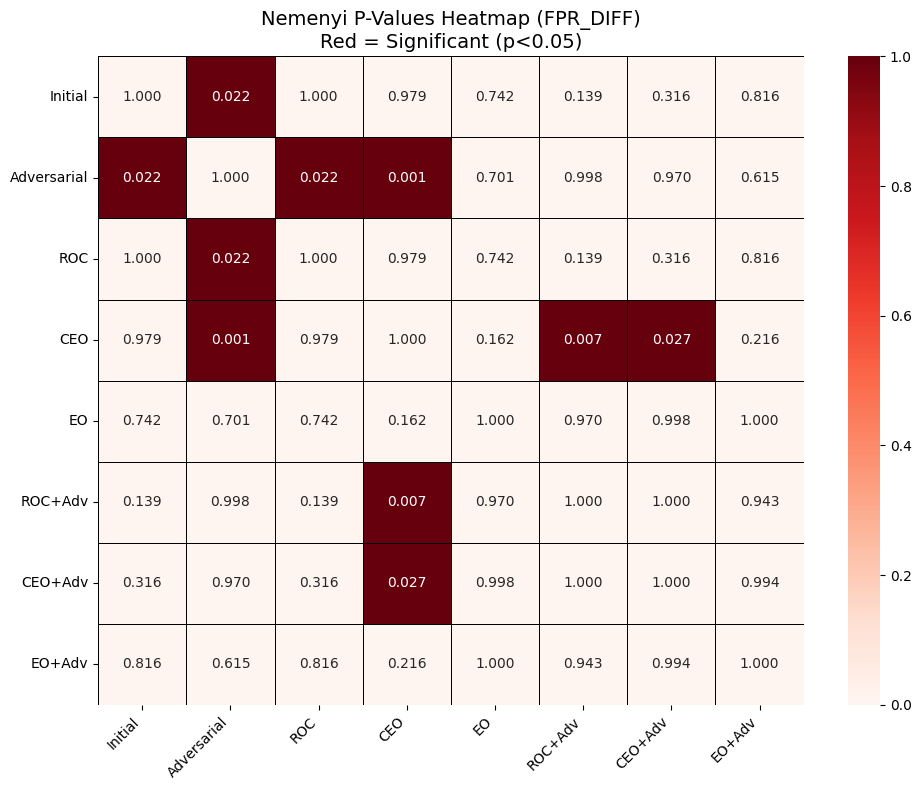

In [77]:
res_nn_sex = run_fairness_pipeline("nn", X, y, "sex_Male")

In [78]:
res_nn_sex

{'Initial': {'accuracy': [0.6943866943866944,
   0.6784476784476784,
   0.659043659043659,
   0.6611226611226612,
   0.6775312066574203],
  'di': [np.float64(0.6668507501401545),
   np.float64(0.4813895781637717),
   np.float64(0.4775247524752475),
   np.float64(0.4574386990217253),
   np.float64(0.4678882305610416)],
  'eod': [np.float64(-0.09356689328515144),
   np.float64(-0.27957062185215964),
   np.float64(-0.19195504288671994),
   np.float64(-0.25304907327379234),
   np.float64(-0.18384679773789842)],
  'fpr_diff': [np.float64(-0.055231312914971076),
   np.float64(-0.11991313379284299),
   np.float64(-0.20059282737571169),
   np.float64(-0.1578614862196952),
   np.float64(-0.16249999999999998)]},
 'Adversarial': {'accuracy': [0.6770616770616771,
   0.6722106722106722,
   0.6195426195426196,
   0.6645876645876646,
   0.628987517337032],
  'di': [np.float64(1.2148099009079978),
   np.float64(1.2130668536699394),
   np.float64(2.3664879356568362),
   np.float64(1.1288160833953833),


## For race

### XGB

epoch 0; iter: 0; batch classifier loss: 0.707917; batch adversarial loss: 0.870045
epoch 1; iter: 0; batch classifier loss: 0.673744; batch adversarial loss: 0.841353
epoch 2; iter: 0; batch classifier loss: 0.613463; batch adversarial loss: 0.770119
epoch 3; iter: 0; batch classifier loss: 0.658448; batch adversarial loss: 0.785224
epoch 4; iter: 0; batch classifier loss: 0.666974; batch adversarial loss: 0.798268
epoch 5; iter: 0; batch classifier loss: 0.675900; batch adversarial loss: 0.779032
epoch 6; iter: 0; batch classifier loss: 0.669967; batch adversarial loss: 0.738363
epoch 7; iter: 0; batch classifier loss: 0.643794; batch adversarial loss: 0.756376
epoch 8; iter: 0; batch classifier loss: 0.619154; batch adversarial loss: 0.716931
epoch 9; iter: 0; batch classifier loss: 0.635924; batch adversarial loss: 0.705961
epoch 10; iter: 0; batch classifier loss: 0.648993; batch adversarial loss: 0.723875
epoch 11; iter: 0; batch classifier loss: 0.604652; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.845915; batch adversarial loss: 0.696405
epoch 1; iter: 0; batch classifier loss: 0.639842; batch adversarial loss: 0.691665
epoch 2; iter: 0; batch classifier loss: 0.697440; batch adversarial loss: 0.692579
epoch 3; iter: 0; batch classifier loss: 0.615203; batch adversarial loss: 0.684638
epoch 4; iter: 0; batch classifier loss: 0.639591; batch adversarial loss: 0.693071
epoch 5; iter: 0; batch classifier loss: 0.620847; batch adversarial loss: 0.677368
epoch 6; iter: 0; batch classifier loss: 0.634382; batch adversarial loss: 0.696320
epoch 7; iter: 0; batch classifier loss: 0.603117; batch adversarial loss: 0.700020
epoch 8; iter: 0; batch classifier loss: 0.632978; batch adversarial loss: 0.691058
epoch 9; iter: 0; batch classifier loss: 0.619485; batch adversarial loss: 0.691023
epoch 10; iter: 0; batch classifier loss: 0.616602; batch adversarial loss: 0.692556
epoch 11; iter: 0; batch classifier loss: 0.639204; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.831438; batch adversarial loss: 0.702705
epoch 1; iter: 0; batch classifier loss: 0.669292; batch adversarial loss: 0.700946
epoch 2; iter: 0; batch classifier loss: 0.637481; batch adversarial loss: 0.694879
epoch 3; iter: 0; batch classifier loss: 0.655479; batch adversarial loss: 0.695418
epoch 4; iter: 0; batch classifier loss: 0.659952; batch adversarial loss: 0.692320
epoch 5; iter: 0; batch classifier loss: 0.615271; batch adversarial loss: 0.686550
epoch 6; iter: 0; batch classifier loss: 0.563629; batch adversarial loss: 0.690561
epoch 7; iter: 0; batch classifier loss: 0.623915; batch adversarial loss: 0.689114
epoch 8; iter: 0; batch classifier loss: 0.638140; batch adversarial loss: 0.670043
epoch 9; iter: 0; batch classifier loss: 0.596693; batch adversarial loss: 0.690292
epoch 10; iter: 0; batch classifier loss: 0.598666; batch adversarial loss: 0.684194
epoch 11; iter: 0; batch classifier loss: 0.645961; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.827576; batch adversarial loss: 0.700462
epoch 1; iter: 0; batch classifier loss: 0.694443; batch adversarial loss: 0.703429
epoch 2; iter: 0; batch classifier loss: 0.629337; batch adversarial loss: 0.699805
epoch 3; iter: 0; batch classifier loss: 0.601082; batch adversarial loss: 0.681691
epoch 4; iter: 0; batch classifier loss: 0.634383; batch adversarial loss: 0.689542
epoch 5; iter: 0; batch classifier loss: 0.628892; batch adversarial loss: 0.692649
epoch 6; iter: 0; batch classifier loss: 0.602326; batch adversarial loss: 0.688188
epoch 7; iter: 0; batch classifier loss: 0.574480; batch adversarial loss: 0.694676
epoch 8; iter: 0; batch classifier loss: 0.651762; batch adversarial loss: 0.687803
epoch 9; iter: 0; batch classifier loss: 0.592550; batch adversarial loss: 0.684551
epoch 10; iter: 0; batch classifier loss: 0.573856; batch adversarial loss: 0.686990
epoch 11; iter: 0; batch classifier loss: 0.664097; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.718564; batch adversarial loss: 0.710405
epoch 1; iter: 0; batch classifier loss: 0.619193; batch adversarial loss: 0.697833
epoch 2; iter: 0; batch classifier loss: 0.593158; batch adversarial loss: 0.695777
epoch 3; iter: 0; batch classifier loss: 0.640951; batch adversarial loss: 0.686204
epoch 4; iter: 0; batch classifier loss: 0.593838; batch adversarial loss: 0.673003
epoch 5; iter: 0; batch classifier loss: 0.632146; batch adversarial loss: 0.689159
epoch 6; iter: 0; batch classifier loss: 0.636843; batch adversarial loss: 0.699378
epoch 7; iter: 0; batch classifier loss: 0.657442; batch adversarial loss: 0.699855
epoch 8; iter: 0; batch classifier loss: 0.652462; batch adversarial loss: 0.681147
epoch 9; iter: 0; batch classifier loss: 0.670661; batch adversarial loss: 0.700861
epoch 10; iter: 0; batch classifier loss: 0.651886; batch adversarial loss: 0.704507
epoch 11; iter: 0; batch classifier loss: 0.664355; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.673 (95% CI: 0.661-0.688)
  DI:       0.464 (95% CI: 0.452-0.479)
  EOD:      -0.299 (95% CI: -0.318--0.280)
  FPR Diff: -0.196 (95% CI: -0.214--0.174)

Adversarial:
  Accuracy: 0.662 (95% CI: 0.653-0.673)
  DI:       0.990 (95% CI: 0.892-1.115)
  EOD:      0.012 (95% CI: -0.051-0.102)
  FPR Diff: 0.047 (95% CI: 0.017-0.083)

ROC:
  Accuracy: 0.673 (95% CI: 0.661-0.687)
  DI:       0.464 (95% CI: 0.452-0.479)
  EOD:      -0.299 (95% CI: -0.318--0.280)
  FPR Diff: -0.196 (95% CI: -0.214--0.176)

CEO:
  Accuracy: 0.664 (95% CI: 0.650-0.680)
  DI:       0.348 (95% CI: 0.277-0.419)
  EOD:      -0.392 (95% CI: -0.446--0.345)
  FPR Diff: -0.255 (95% CI: -0.285--0.227)

EO:
  Accuracy: 0.635 (95% CI: 0.623-0.647)
  DI:       0.910 (95% CI: 0.894-0.927)
  EOD:      0.004 (95% CI: -0.005-0.013)
  FPR Diff: -0.003 (95% CI: -0.008-0.003)

ROC+Adv:
  Accuracy: 0.666 (95% CI: 0.656-0.677)
  DI:       0.957 (95% CI: 0.910-1.

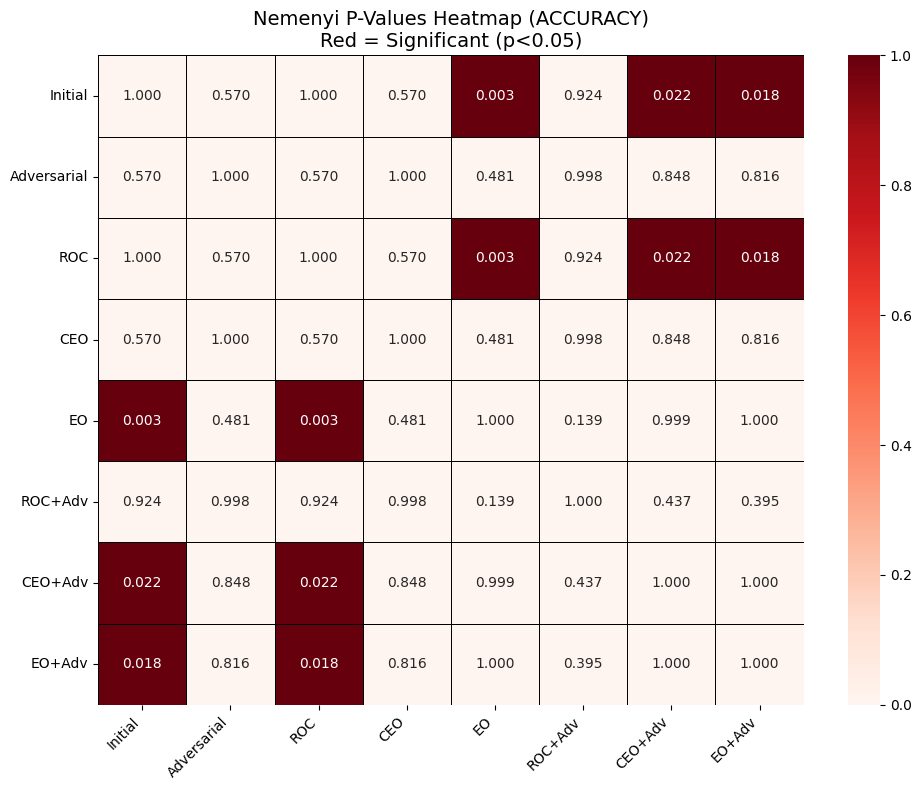


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(28.995180722891572), pvalue=np.float64(0.00014497995677712852))


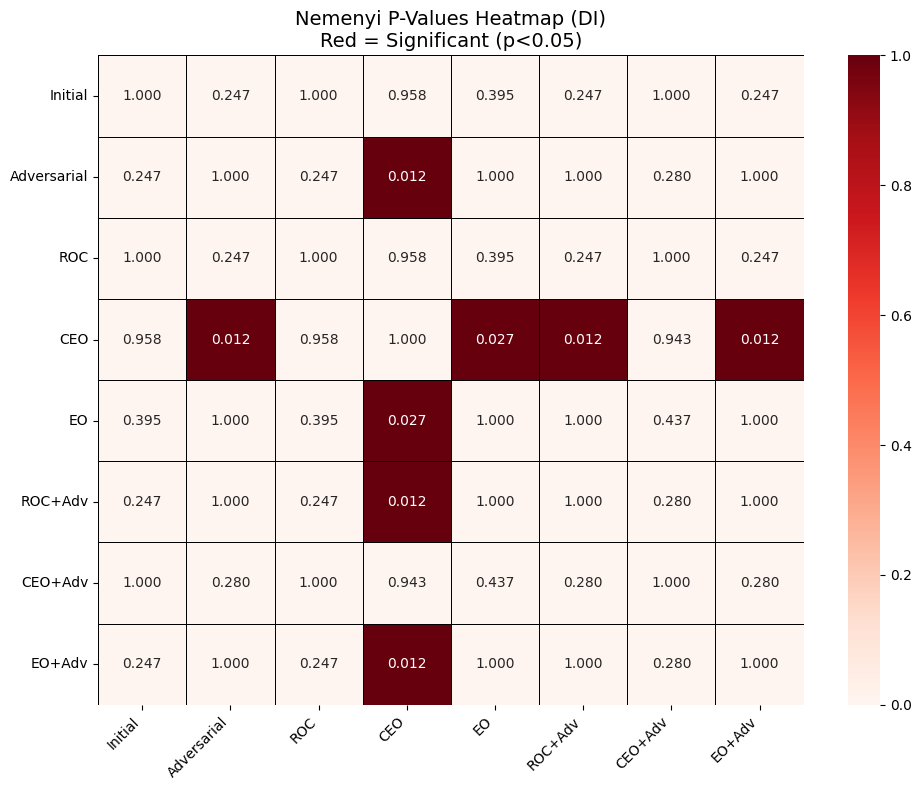


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(30.14216867469879), pvalue=np.float64(8.942361149988454e-05))


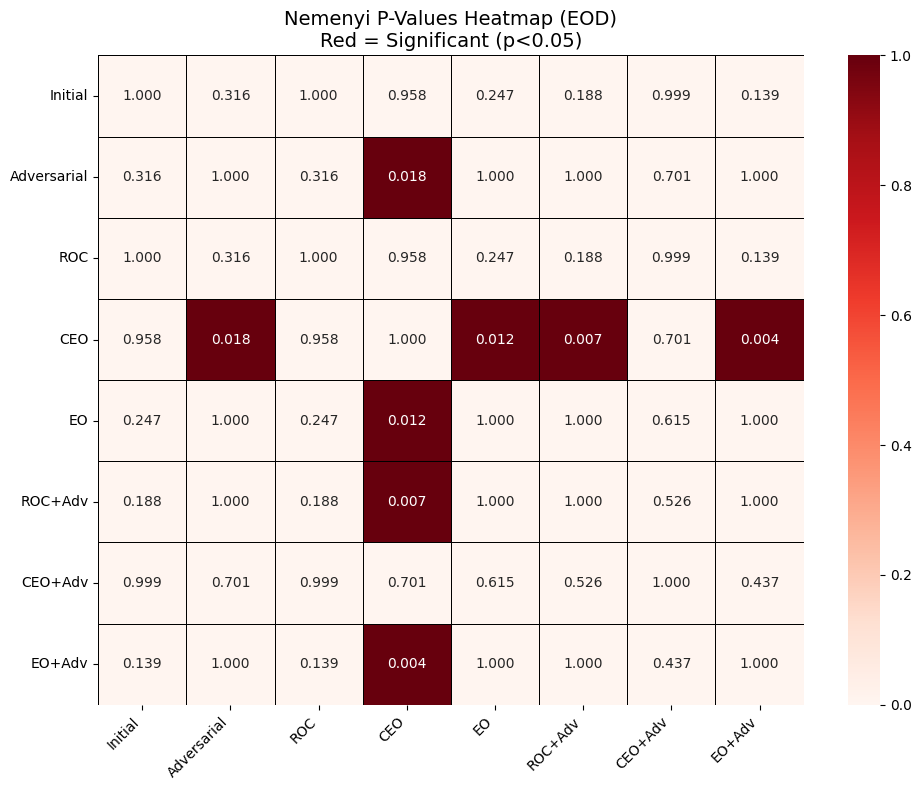


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(30.95180722891567), pvalue=np.float64(6.345928569580561e-05))


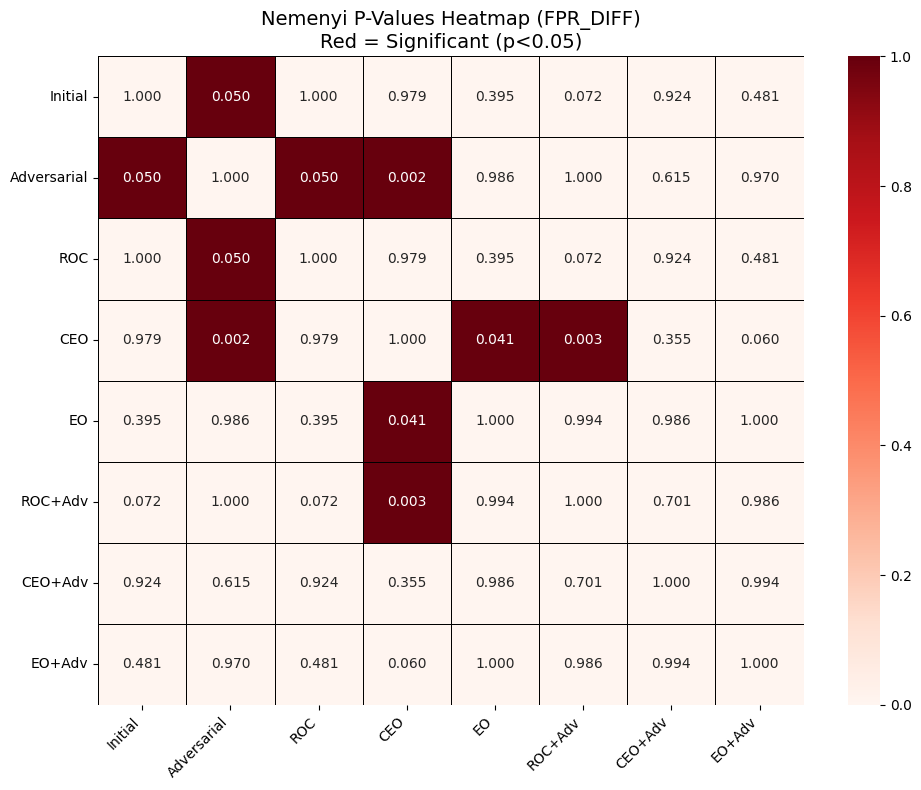

In [79]:
res_xgb_race = run_fairness_pipeline("xgb", X, y, "race_African-American")

In [80]:
res_xgb_race

{'Initial': {'accuracy': [0.6999306999306999,
   0.6701316701316701,
   0.6548856548856549,
   0.6618156618156619,
   0.6775312066574203],
  'di': [np.float64(0.4514573070607554),
   np.float64(0.4662818012587536),
   np.float64(0.4940852702428826),
   np.float64(0.46179823666734665),
   np.float64(0.44745835418602986)],
  'eod': [np.float64(-0.29225286975824905),
   np.float64(-0.32372316515539024),
   np.float64(-0.2752159035359296),
   np.float64(-0.3259790402647545),
   np.float64(-0.27823281211218664)],
  'fpr_diff': [np.float64(-0.1914066496163683),
   np.float64(-0.1857206689646368),
   np.float64(-0.2222507477247346),
   np.float64(-0.1614061735705275),
   np.float64(-0.21773241595200052)]},
 'Adversarial': {'accuracy': [0.683991683991684,
   0.665973665973666,
   0.6472626472626473,
   0.6541926541926542,
   0.6588072122052705],
  'di': [np.float64(0.9707102506767095),
   np.float64(0.8930908633274603),
   np.float64(0.855132599675266),
   np.float64(1.0017530678687705),
   np

### SVC

epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.689688; batch adversarial loss: 0.702400
epoch 1; iter: 0; batch classifier loss: 0.617580; batch adversarial loss: 0.703775
epoch 2; iter: 0; batch classifier loss: 0.632216; batch adversarial loss: 0.690622
epoch 3; iter: 0; batch classifier loss: 0.676659; batch adversarial loss: 0.681706
epoch 4; iter: 0; batch classifier loss: 0.668773; batch adversarial loss: 0.680801
epoch 5; iter: 0; batch classifier loss: 0.580102; batch adversarial loss: 0.677078
epoch 6; iter: 0; batch classifier loss: 0.563378; batch adversarial loss: 0.685448
epoch 7; iter: 0; batch classifier loss: 0.639191; batch adversarial loss: 0.688028
epoch 8; iter: 0; batch classifier loss: 0.639867; batch adversarial loss: 0.677651
epoch 9; iter: 0; batch classifier loss: 0.607057; batch adversarial loss: 0.698121
epoch 10; iter: 0; batch classifier loss: 0.601905; batch adversarial loss: 0.686072
epoch 11; iter: 0; batch classifier loss: 0.654708; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.670 (95% CI: 0.660-0.682)
  DI:       0.447 (95% CI: 0.417-0.474)
  EOD:      -0.275 (95% CI: -0.327--0.224)
  FPR Diff: -0.178 (95% CI: -0.187--0.166)

Adversarial:
  Accuracy: 0.656 (95% CI: 0.640-0.670)
  DI:       1.074 (95% CI: 0.961-1.177)
  EOD:      0.046 (95% CI: 0.016-0.075)
  FPR Diff: 0.063 (95% CI: 0.022-0.109)

ROC:
  Accuracy: 0.670 (95% CI: 0.661-0.682)
  DI:       0.447 (95% CI: 0.413-0.475)
  EOD:      -0.275 (95% CI: -0.325--0.224)
  FPR Diff: -0.178 (95% CI: -0.188--0.168)

CEO:
  Accuracy: 0.660 (95% CI: 0.647-0.676)
  DI:       0.353 (95% CI: 0.289-0.409)
  EOD:      -0.365 (95% CI: -0.405--0.325)
  FPR Diff: -0.267 (95% CI: -0.301--0.233)

EO:
  Accuracy: 0.623 (95% CI: 0.615-0.630)
  DI:       0.907 (95% CI: 0.891-0.924)
  EOD:      -0.001 (95% CI: -0.012-0.011)
  FPR Diff: -0.002 (95% CI: -0.011-0.008)

ROC+Adv:
  Accuracy: 0.662 (95% CI: 0.654-0.673)
  DI:       0.931 (95% CI: 0.917-0.

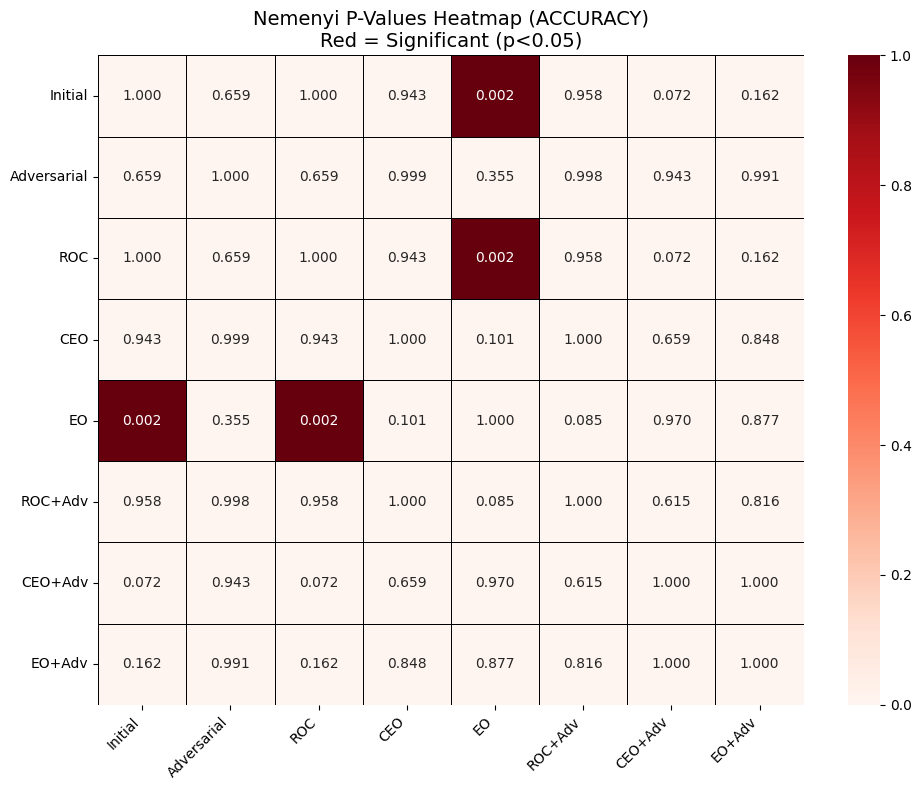


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.602409638554217), pvalue=np.float64(0.00011230083638534734))


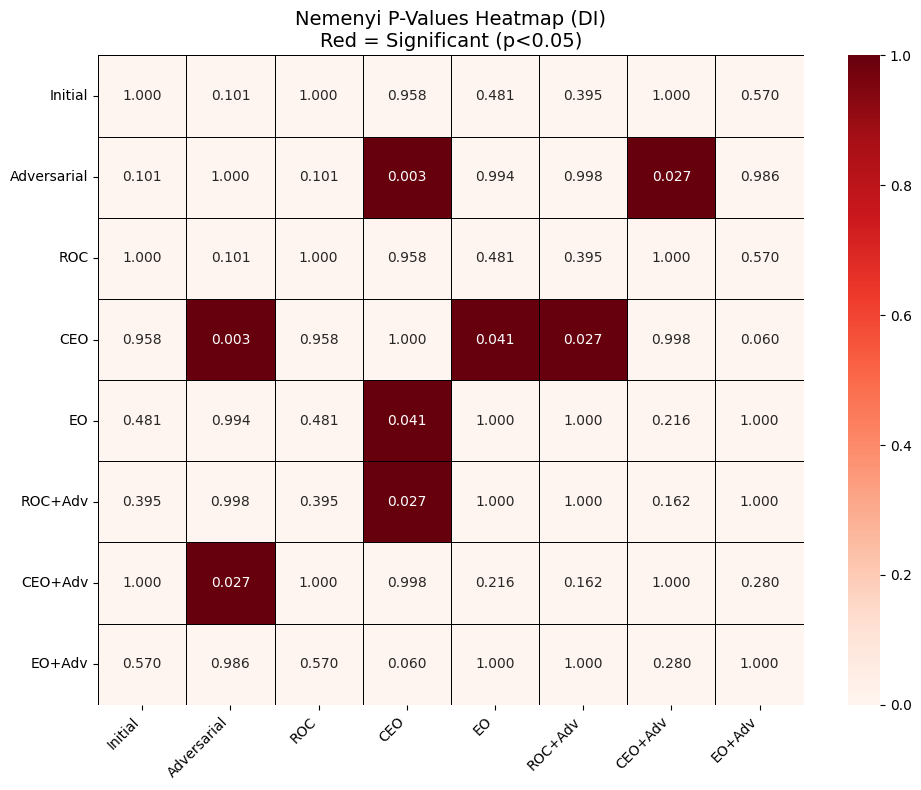


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(30.546987951807232), pvalue=np.float64(7.534530883518649e-05))


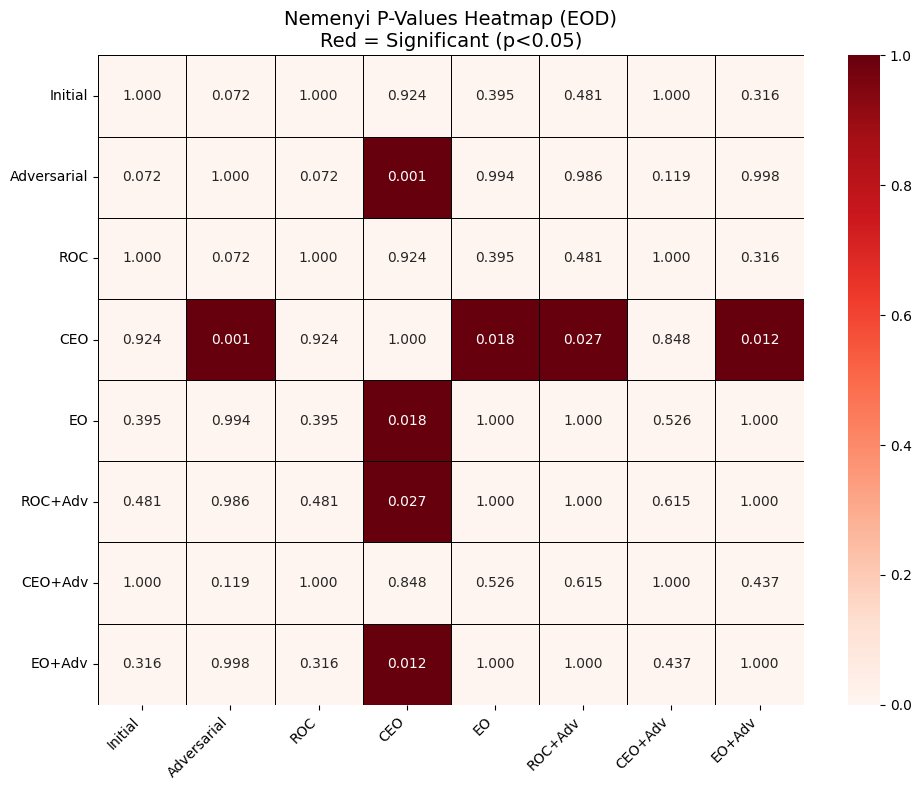


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(31.08674698795181), pvalue=np.float64(5.992465065032899e-05))


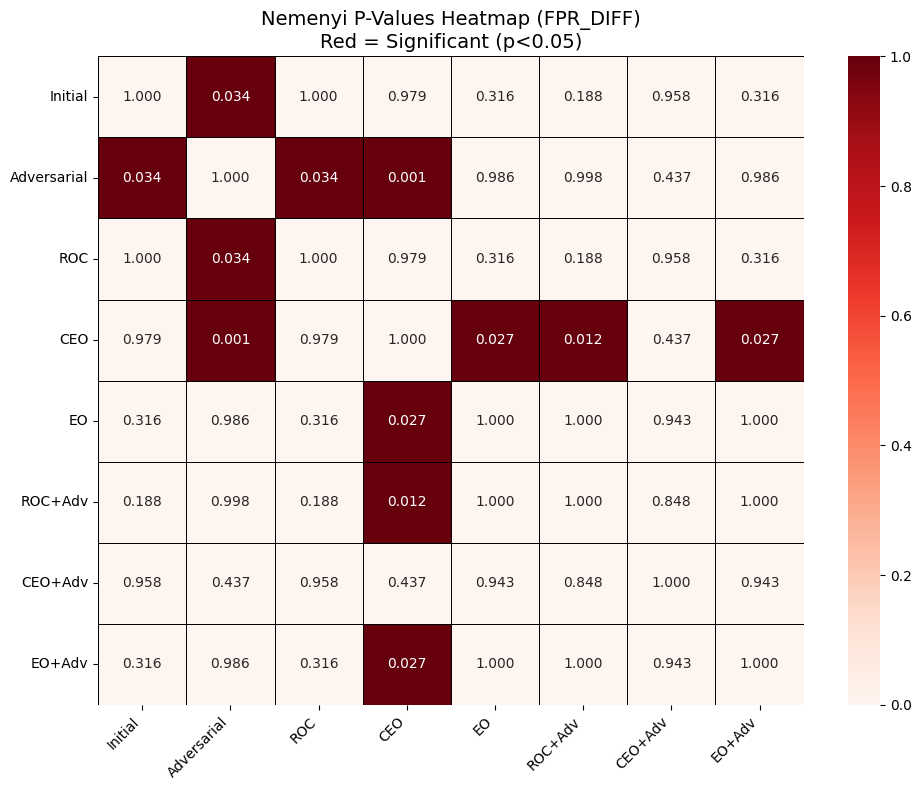

In [81]:
res_svc_race = run_fairness_pipeline("svc", X, y, "race_African-American")

In [82]:
res_svc_race

{'Initial': {'accuracy': [0.6909216909216909,
   0.6777546777546778,
   0.6548856548856549,
   0.6604296604296604,
   0.6678224687933426],
  'di': [np.float64(0.4608416130917592),
   np.float64(0.43221109040074557),
   np.float64(0.49332907756144273),
   np.float64(0.3904712711530893),
   np.float64(0.4560747663551402)],
  'eod': [np.float64(-0.26584817299360336),
   np.float64(-0.32407192125862205),
   np.float64(-0.21701540319565993),
   np.float64(-0.36107280750137893),
   np.float64(-0.2088359394390668)],
  'fpr_diff': [np.float64(-0.1770907928388747),
   np.float64(-0.18956338567598618),
   np.float64(-0.19033926806413104),
   np.float64(-0.1586772391421878),
   np.float64(-0.1749763589526201)]},
 'Adversarial': {'accuracy': [0.681912681912682,
   0.6673596673596673,
   0.6465696465696466,
   0.6306306306306306,
   0.6532593619972261],
  'di': [np.float64(0.8671757871064467),
   np.float64(1.0819663548792406),
   np.float64(1.1225952470765748),
   np.float64(1.2577512577512577),
 

### Logistic Regression

epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.689688; batch adversarial loss: 0.702400
epoch 1; iter: 0; batch classifier loss: 0.617580; batch adversarial loss: 0.703775
epoch 2; iter: 0; batch classifier loss: 0.632216; batch adversarial loss: 0.690622
epoch 3; iter: 0; batch classifier loss: 0.676659; batch adversarial loss: 0.681706
epoch 4; iter: 0; batch classifier loss: 0.668773; batch adversarial loss: 0.680801
epoch 5; iter: 0; batch classifier loss: 0.580102; batch adversarial loss: 0.677078
epoch 6; iter: 0; batch classifier loss: 0.563378; batch adversarial loss: 0.685448
epoch 7; iter: 0; batch classifier loss: 0.639191; batch adversarial loss: 0.688028
epoch 8; iter: 0; batch classifier loss: 0.639867; batch adversarial loss: 0.677651
epoch 9; iter: 0; batch classifier loss: 0.607057; batch adversarial loss: 0.698121
epoch 10; iter: 0; batch classifier loss: 0.601905; batch adversarial loss: 0.686072
epoch 11; iter: 0; batch classifier loss: 0.654708; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.675 (95% CI: 0.665-0.685)
  DI:       0.408 (95% CI: 0.396-0.421)
  EOD:      -0.304 (95% CI: -0.333--0.280)
  FPR Diff: -0.194 (95% CI: -0.211--0.170)

Adversarial:
  Accuracy: 0.656 (95% CI: 0.640-0.670)
  DI:       1.074 (95% CI: 0.961-1.177)
  EOD:      0.046 (95% CI: 0.016-0.075)
  FPR Diff: 0.063 (95% CI: 0.022-0.109)

ROC:
  Accuracy: 0.675 (95% CI: 0.665-0.685)
  DI:       0.408 (95% CI: 0.396-0.422)
  EOD:      -0.304 (95% CI: -0.334--0.280)
  FPR Diff: -0.194 (95% CI: -0.211--0.171)

CEO:
  Accuracy: 0.661 (95% CI: 0.650-0.672)
  DI:       0.273 (95% CI: 0.207-0.336)
  EOD:      -0.416 (95% CI: -0.461--0.369)
  FPR Diff: -0.257 (95% CI: -0.273--0.240)

EO:
  Accuracy: 0.621 (95% CI: 0.607-0.638)
  DI:       0.905 (95% CI: 0.891-0.920)
  EOD:      -0.006 (95% CI: -0.011-0.001)
  FPR Diff: 0.001 (95% CI: -0.008-0.008)

ROC+Adv:
  Accuracy: 0.662 (95% CI: 0.654-0.673)
  DI:       0.931 (95% CI: 0.917-0.9

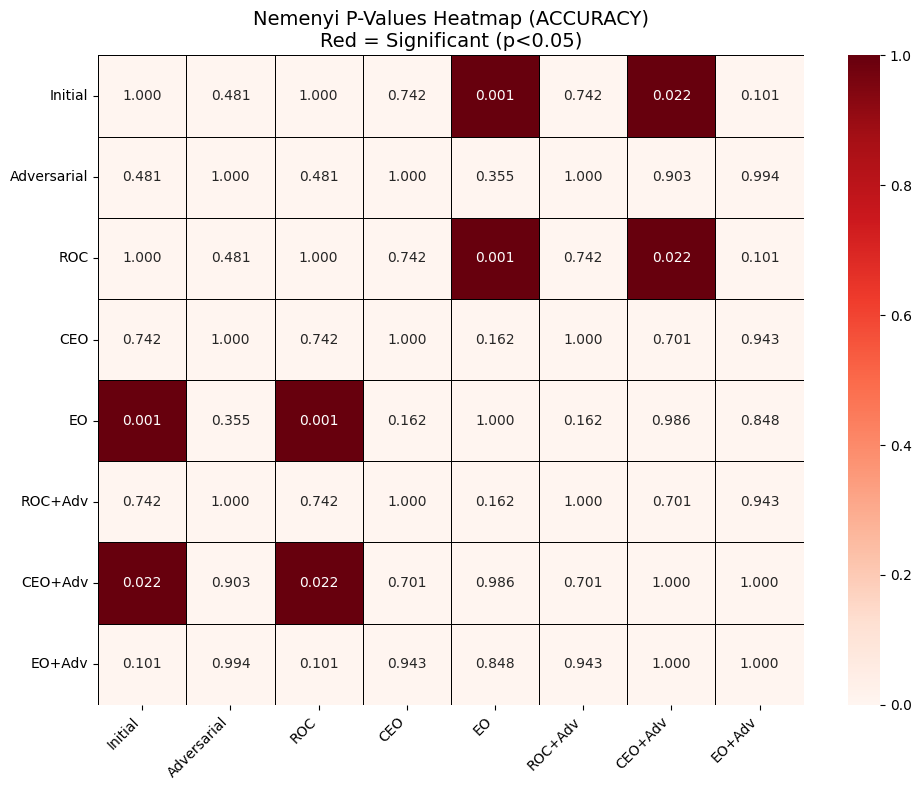


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(30.074698795180723), pvalue=np.float64(9.201003674329807e-05))


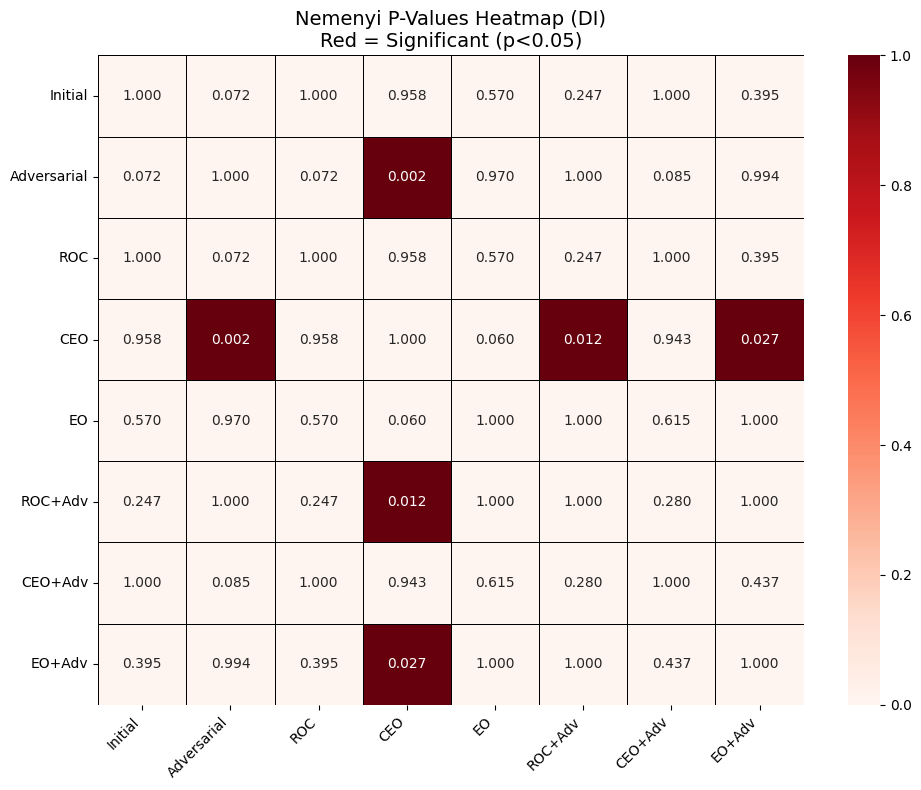


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(31.424096385542178), pvalue=np.float64(5.191632862013329e-05))


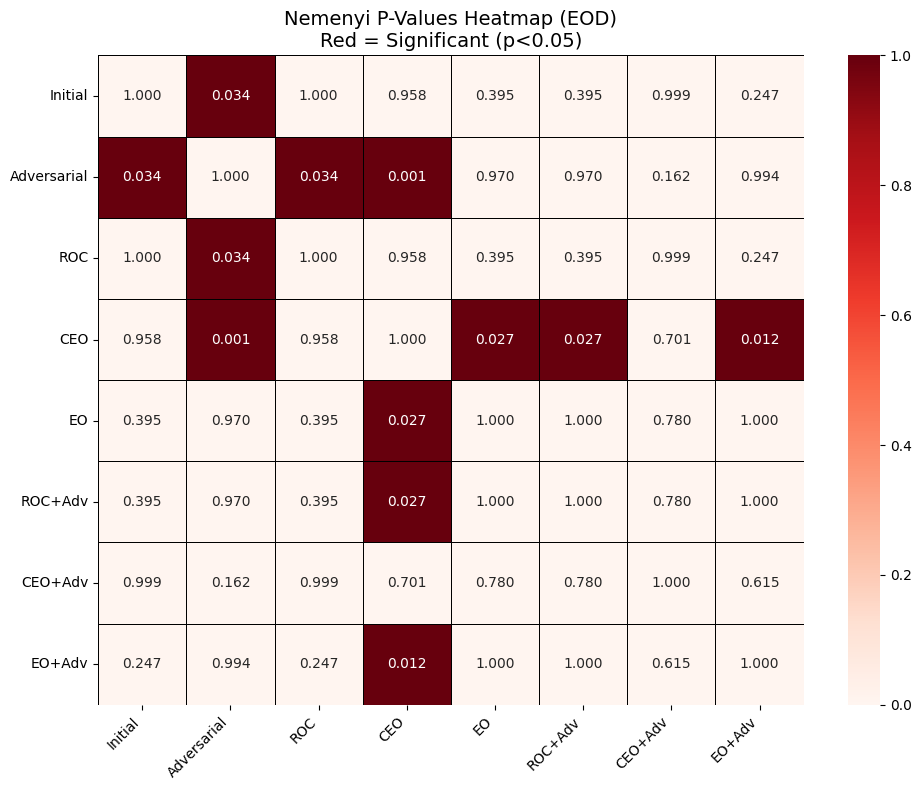


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(31.154216867469877), pvalue=np.float64(5.823096802124234e-05))


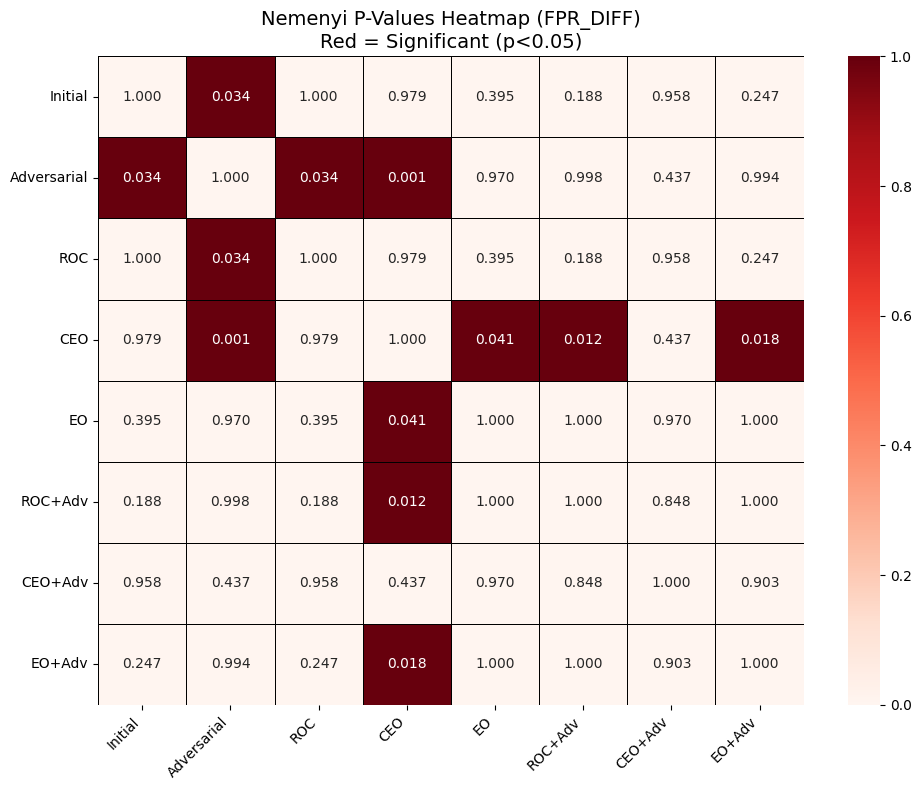

In [83]:
res_lr_race = run_fairness_pipeline("lr", X, y, "race_African-American")

In [84]:
res_lr_race

{'Initial': {'accuracy': [0.6916146916146916,
   0.6812196812196812,
   0.6618156618156619,
   0.6611226611226612,
   0.680998613037448],
  'di': [np.float64(0.41721709567751336),
   np.float64(0.39705002989834565),
   np.float64(0.43172714844218457),
   np.float64(0.39184952978056425),
   np.float64(0.4014202864244289)],
  'eod': [np.float64(-0.29431695372362693),
   np.float64(-0.30837789661319076),
   np.float64(-0.28832826922523946),
   np.float64(-0.36238279095421955),
   np.float64(-0.2682055100521222)],
  'fpr_diff': [np.float64(-0.1935613810741688),
   np.float64(-0.19846801991574112),
   np.float64(-0.21069791920721925),
   np.float64(-0.15029735087403134),
   np.float64(-0.21640851729872504)]},
 'Adversarial': {'accuracy': [0.681912681912682,
   0.6673596673596673,
   0.6465696465696466,
   0.6306306306306306,
   0.6532593619972261],
  'di': [np.float64(0.8671757871064467),
   np.float64(1.0819663548792406),
   np.float64(1.1225952470765748),
   np.float64(1.2577512577512577)

### GBDT

epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.689688; batch adversarial loss: 0.702400
epoch 1; iter: 0; batch classifier loss: 0.617580; batch adversarial loss: 0.703775
epoch 2; iter: 0; batch classifier loss: 0.632216; batch adversarial loss: 0.690622
epoch 3; iter: 0; batch classifier loss: 0.676659; batch adversarial loss: 0.681706
epoch 4; iter: 0; batch classifier loss: 0.668773; batch adversarial loss: 0.680801
epoch 5; iter: 0; batch classifier loss: 0.580102; batch adversarial loss: 0.677078
epoch 6; iter: 0; batch classifier loss: 0.563378; batch adversarial loss: 0.685448
epoch 7; iter: 0; batch classifier loss: 0.639191; batch adversarial loss: 0.688028
epoch 8; iter: 0; batch classifier loss: 0.639867; batch adversarial loss: 0.677651
epoch 9; iter: 0; batch classifier loss: 0.607057; batch adversarial loss: 0.698121
epoch 10; iter: 0; batch classifier loss: 0.601905; batch adversarial loss: 0.686072
epoch 11; iter: 0; batch classifier loss: 0.654708; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.660-0.688)
  DI:       0.476 (95% CI: 0.443-0.519)
  EOD:      -0.280 (95% CI: -0.337--0.222)
  FPR Diff: -0.183 (95% CI: -0.192--0.172)

Adversarial:
  Accuracy: 0.656 (95% CI: 0.640-0.670)
  DI:       1.074 (95% CI: 0.961-1.177)
  EOD:      0.046 (95% CI: 0.016-0.075)
  FPR Diff: 0.063 (95% CI: 0.022-0.109)

ROC:
  Accuracy: 0.674 (95% CI: 0.660-0.689)
  DI:       0.476 (95% CI: 0.443-0.519)
  EOD:      -0.280 (95% CI: -0.333--0.222)
  FPR Diff: -0.183 (95% CI: -0.192--0.173)

CEO:
  Accuracy: 0.664 (95% CI: 0.651-0.681)
  DI:       0.333 (95% CI: 0.258-0.401)
  EOD:      -0.389 (95% CI: -0.431--0.355)
  FPR Diff: -0.245 (95% CI: -0.265--0.228)

EO:
  Accuracy: 0.632 (95% CI: 0.617-0.648)
  DI:       0.911 (95% CI: 0.895-0.927)
  EOD:      -0.010 (95% CI: -0.023-0.002)
  FPR Diff: 0.008 (95% CI: -0.001-0.016)

ROC+Adv:
  Accuracy: 0.662 (95% CI: 0.654-0.673)
  DI:       0.931 (95% CI: 0.917-0.9

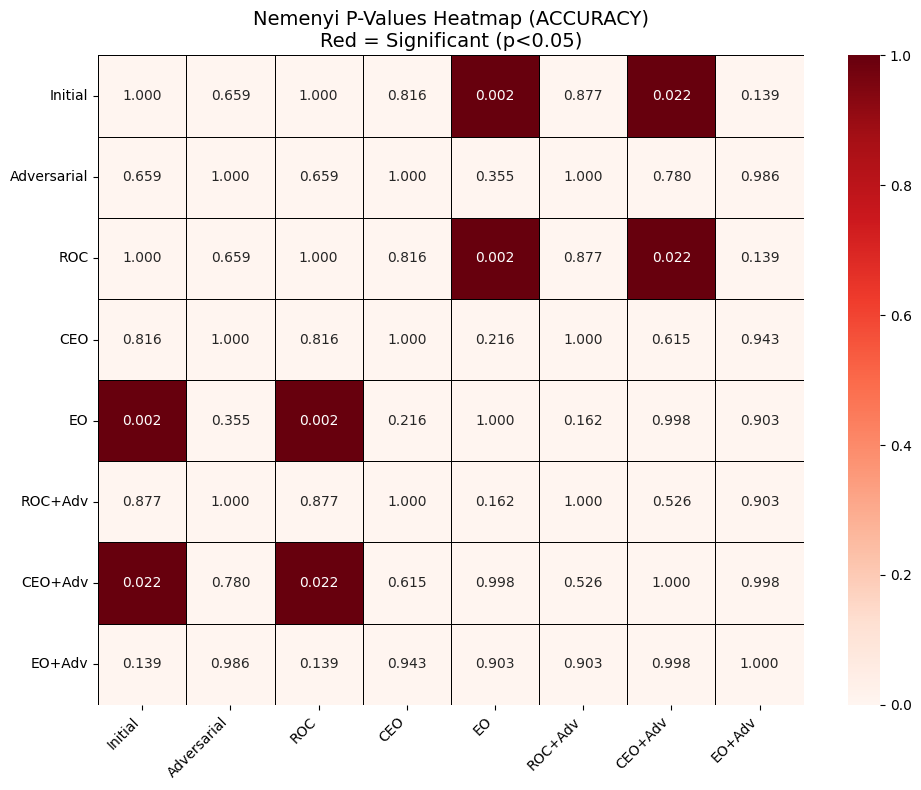


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(30.277108433734927), pvalue=np.float64(8.44640948005423e-05))


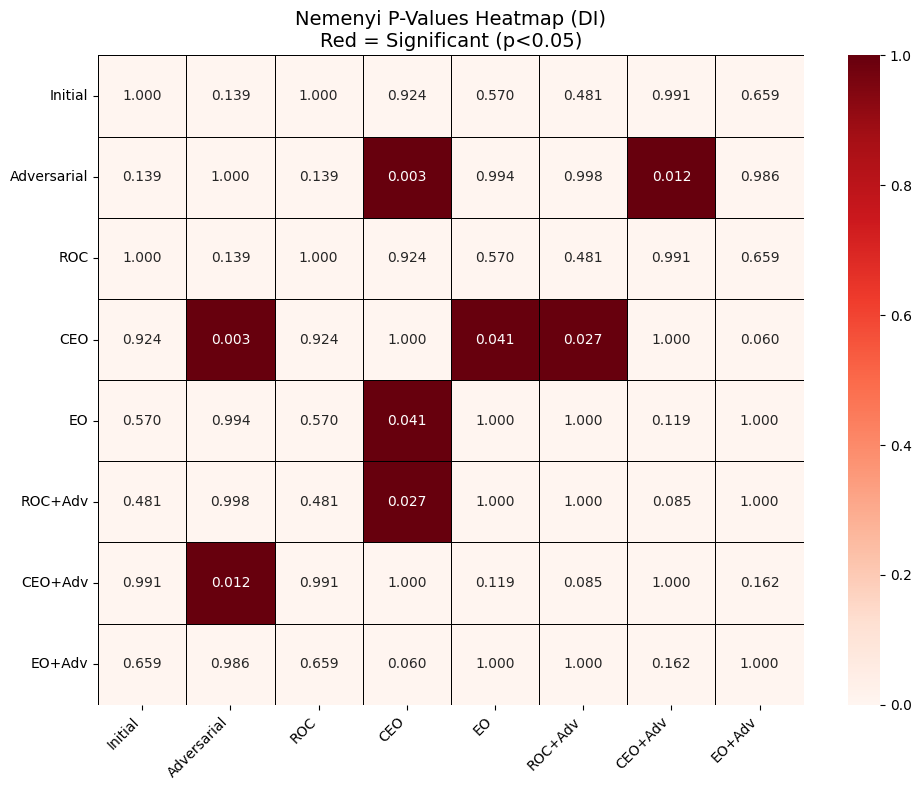


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(31.01927710843374), pvalue=np.float64(6.166696479954755e-05))


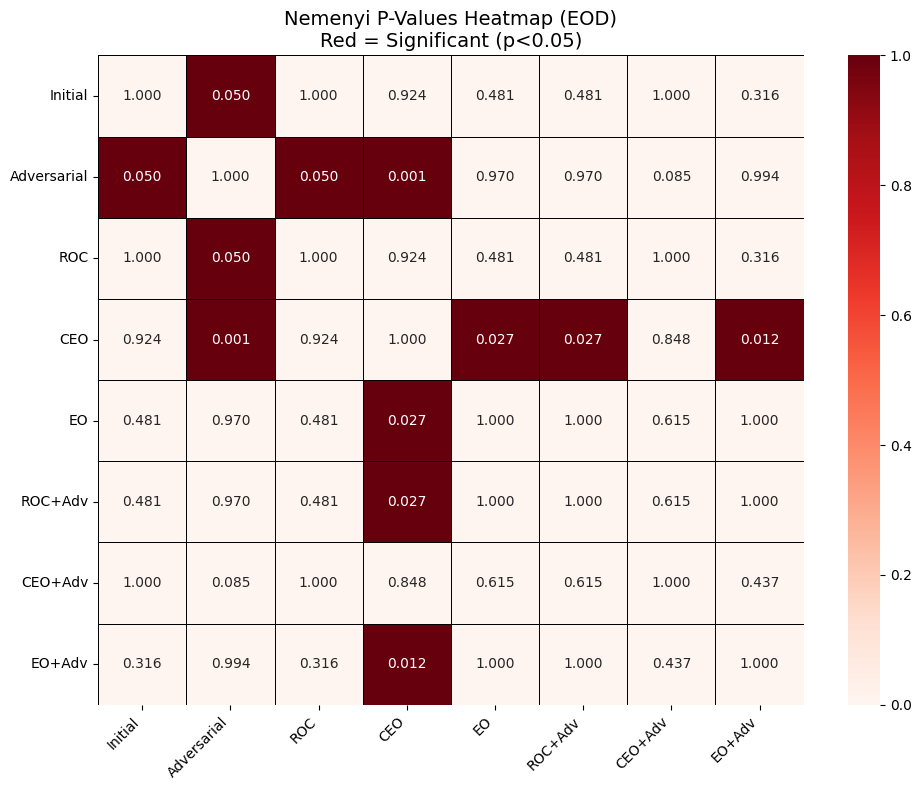


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(31.08674698795181), pvalue=np.float64(5.992465065032899e-05))


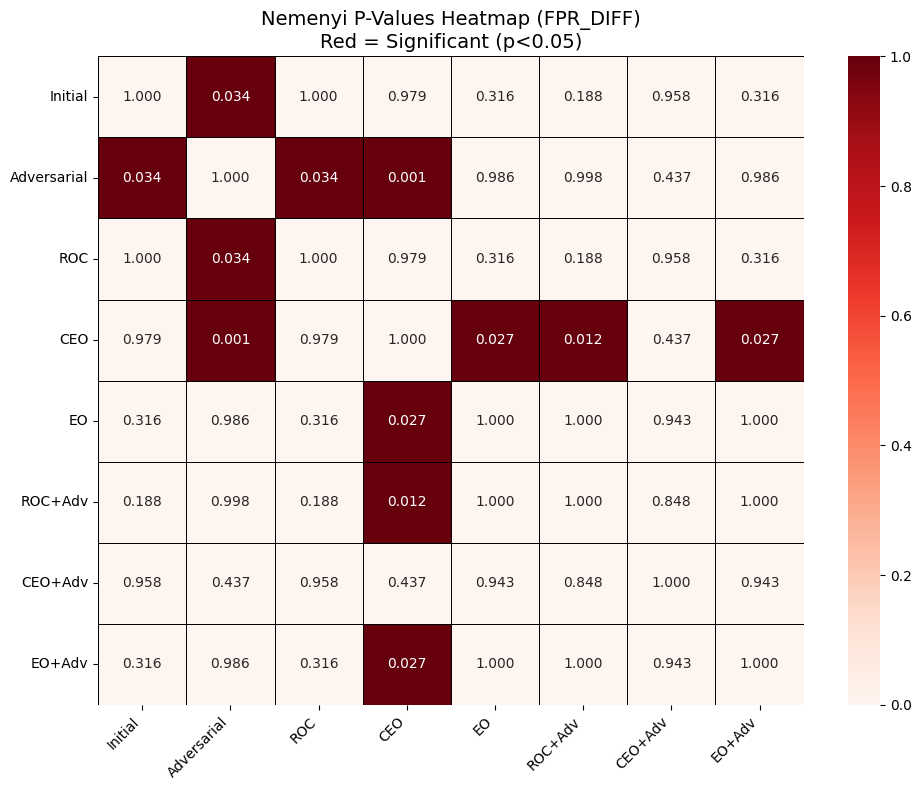

In [85]:
res_gbc_race = run_fairness_pipeline("gbc", X, y, "race_African-American")

In [86]:
res_gbc_race

{'Initial': {'accuracy': [0.7006237006237006,
   0.6701316701316701,
   0.6534996534996536,
   0.6618156618156619,
   0.6816920943134536],
  'di': [np.float64(0.4535365191420038),
   np.float64(0.4591850337717739),
   np.float64(0.5506468147424946),
   np.float64(0.4233676513469259),
   np.float64(0.4914836967007525)],
  'eod': [np.float64(-0.2875113183849517),
   np.float64(-0.3246725567697435),
   np.float64(-0.1914232859511737),
   np.float64(-0.3734831770546056),
   np.float64(-0.22065028543062798)],
  'fpr_diff': [np.float64(-0.19684143222506392),
   np.float64(-0.19048257372654157),
   np.float64(-0.18036532611067613),
   np.float64(-0.16552531987745542),
   np.float64(-0.18058499364137348)]},
 'Adversarial': {'accuracy': [0.681912681912682,
   0.6673596673596673,
   0.6465696465696466,
   0.6306306306306306,
   0.6532593619972261],
  'di': [np.float64(0.8671757871064467),
   np.float64(1.0819663548792406),
   np.float64(1.1225952470765748),
   np.float64(1.2577512577512577),
   

### RFC

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


epoch 0; iter: 0; batch classifier loss: 0.934756; batch adversarial loss: 0.697226
epoch 1; iter: 0; batch classifier loss: 0.656123; batch adversarial loss: 0.698349
epoch 2; iter: 0; batch classifier loss: 0.605294; batch adversarial loss: 0.705437
epoch 3; iter: 0; batch classifier loss: 0.555213; batch adversarial loss: 0.695877
epoch 4; iter: 0; batch classifier loss: 0.591539; batch adversarial loss: 0.688183
epoch 5; iter: 0; batch classifier loss: 0.602807; batch adversarial loss: 0.675607
epoch 6; iter: 0; batch classifier loss: 0.592670; batch adversarial loss: 0.695467
epoch 7; iter: 0; batch classifier loss: 0.613763; batch adversarial loss: 0.704114
epoch 8; iter: 0; batch classifier loss: 0.599238; batch adversarial loss: 0.698344
epoch 9; iter: 0; batch classifier loss: 0.587280; batch adversarial loss: 0.707683
epoch 10; iter: 0; batch classifier loss: 0.589714; batch adversarial loss: 0.709787
epoch 11; iter: 0; batch classifier loss: 0.582660; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.669 (95% CI: 0.654-0.686)
  DI:       0.450 (95% CI: 0.415-0.499)
  EOD:      -0.303 (95% CI: -0.358--0.242)
  FPR Diff: -0.197 (95% CI: -0.212--0.184)

Adversarial:
  Accuracy: 0.654 (95% CI: 0.640-0.666)
  DI:       1.107 (95% CI: 1.047-1.179)
  EOD:      0.060 (95% CI: 0.036-0.084)
  FPR Diff: 0.073 (95% CI: 0.047-0.109)

ROC:
  Accuracy: 0.669 (95% CI: 0.655-0.684)
  DI:       0.450 (95% CI: 0.415-0.499)
  EOD:      -0.303 (95% CI: -0.357--0.248)
  FPR Diff: -0.197 (95% CI: -0.209--0.185)

CEO:
  Accuracy: 0.659 (95% CI: 0.646-0.678)
  DI:       0.325 (95% CI: 0.248-0.388)
  EOD:      -0.399 (95% CI: -0.433--0.364)
  FPR Diff: -0.255 (95% CI: -0.273--0.237)

EO:
  Accuracy: 0.619 (95% CI: 0.605-0.636)
  DI:       0.915 (95% CI: 0.898-0.931)
  EOD:      0.002 (95% CI: -0.017-0.021)
  FPR Diff: -0.005 (95% CI: -0.019-0.007)

ROC+Adv:
  Accuracy: 0.661 (95% CI: 0.654-0.668)
  DI:       0.953 (95% CI: 0.920-0.9

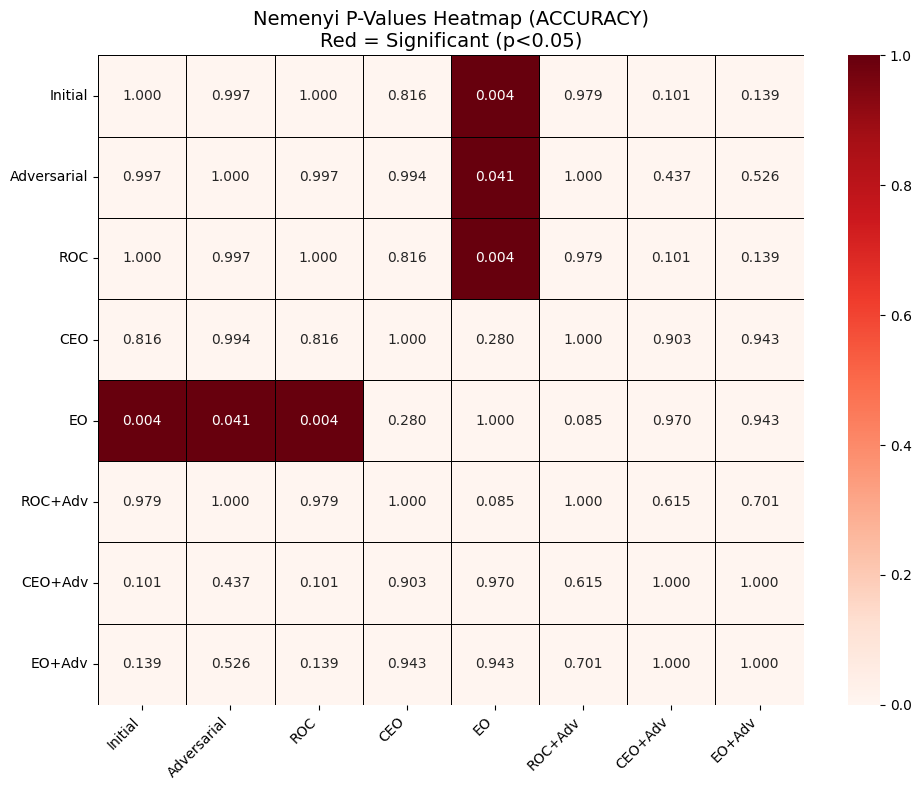


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(31.221686746987945), pvalue=np.float64(5.658457885471183e-05))


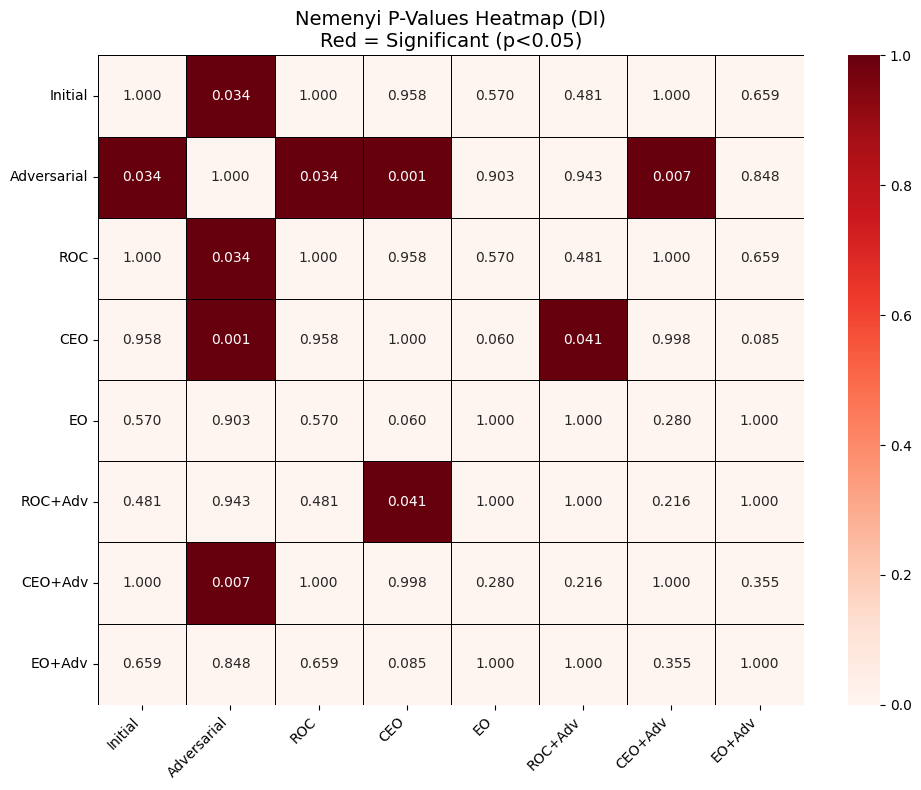


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(31.626506024096383), pvalue=np.float64(4.762891610974643e-05))


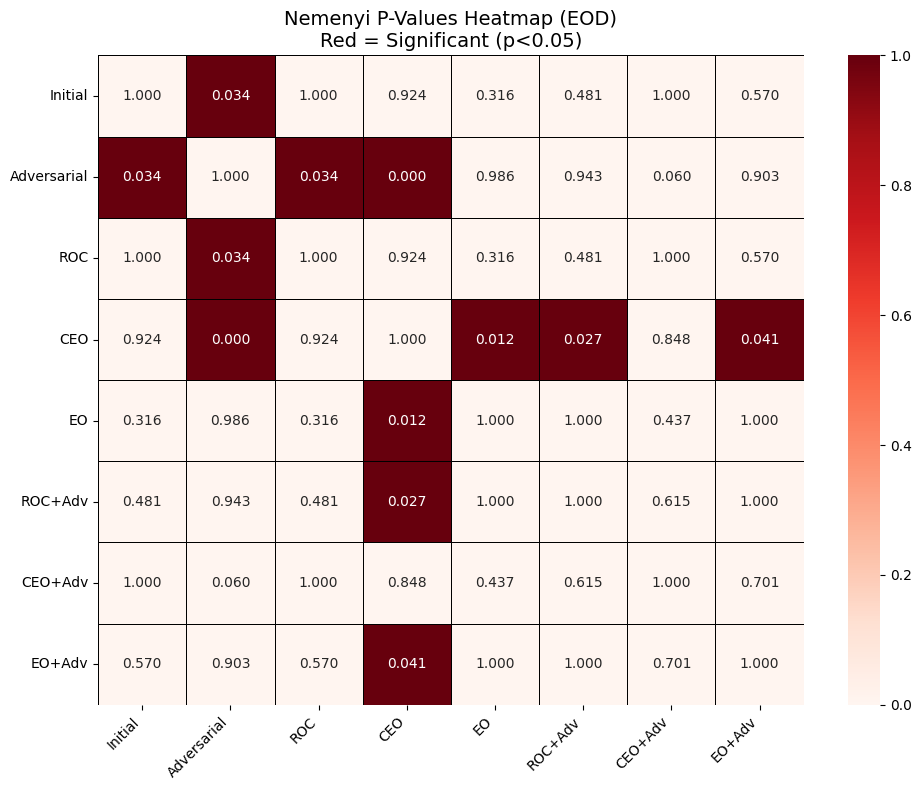


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(32.301204819277096), pvalue=np.float64(3.571216455329066e-05))


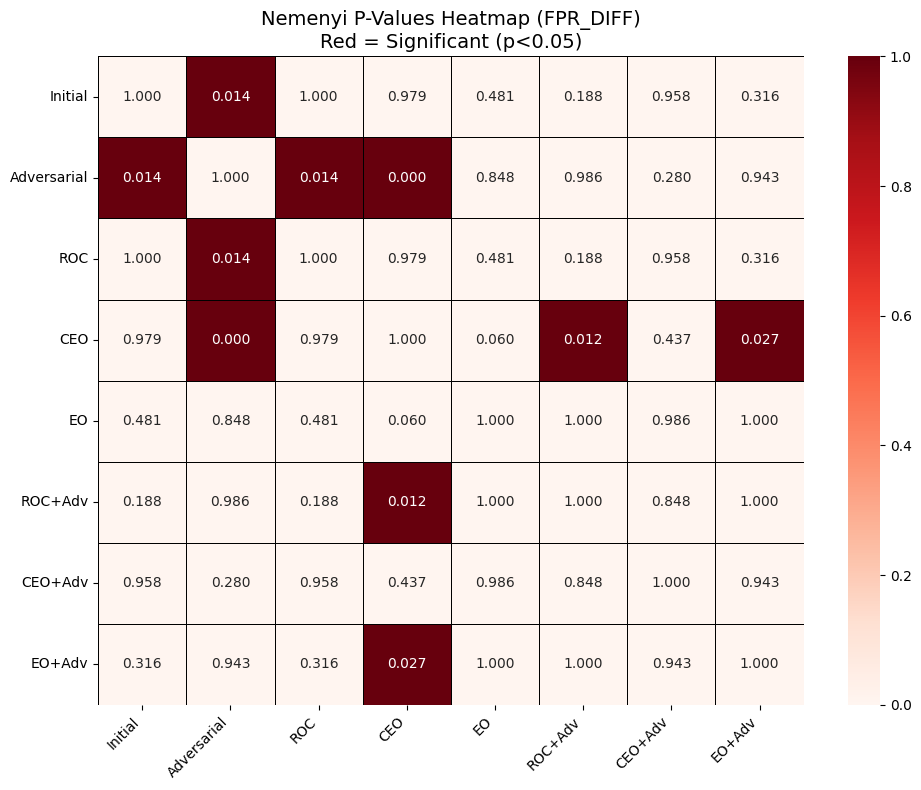

In [56]:
res_rfc_race = run_fairness_pipeline("rfc", X, y, "race_African-American")

In [57]:
res_rfc_race

{'Initial': {'accuracy': [0.6985446985446986,
   0.6666666666666666,
   0.6458766458766458,
   0.659043659043659,
   0.673370319001387],
  'di': [np.float64(0.4075731121780881),
   np.float64(0.4411107600649936),
   np.float64(0.5479960128885695),
   np.float64(0.40965002601831246),
   np.float64(0.44226136764878965)],
  'eod': [np.float64(-0.33813979300742875),
   np.float64(-0.3420134852359916),
   np.float64(-0.2073536600561685),
   np.float64(-0.38375620518477666),
   np.float64(-0.2435343757756267)],
  'fpr_diff': [np.float64(-0.22020460358056265),
   np.float64(-0.18720158304608706),
   np.float64(-0.19257281491085068),
   np.float64(-0.17900265170043508),
   np.float64(-0.20629993152248344)]},
 'Adversarial': {'accuracy': [0.6742896742896742,
   0.6673596673596673,
   0.6465696465696466,
   0.6306306306306306,
   0.6532593619972261],
  'di': [np.float64(1.0339617279272453),
   np.float64(1.0819663548792406),
   np.float64(1.1225952470765748),
   np.float64(1.2577512577512577),
 

### NN (MLPClassifier)

epoch 0; iter: 0; batch classifier loss: 0.784944; batch adversarial loss: 0.720674
epoch 1; iter: 0; batch classifier loss: 0.658774; batch adversarial loss: 0.758011
epoch 2; iter: 0; batch classifier loss: 0.668217; batch adversarial loss: 0.824681
epoch 3; iter: 0; batch classifier loss: 0.694909; batch adversarial loss: 0.773548
epoch 4; iter: 0; batch classifier loss: 0.616801; batch adversarial loss: 0.778472
epoch 5; iter: 0; batch classifier loss: 0.700637; batch adversarial loss: 0.763495
epoch 6; iter: 0; batch classifier loss: 0.650325; batch adversarial loss: 0.737507
epoch 7; iter: 0; batch classifier loss: 0.571137; batch adversarial loss: 0.745001
epoch 8; iter: 0; batch classifier loss: 0.618114; batch adversarial loss: 0.721933
epoch 9; iter: 0; batch classifier loss: 0.622691; batch adversarial loss: 0.738333
epoch 10; iter: 0; batch classifier loss: 0.568269; batch adversarial loss: 0.670392
epoch 11; iter: 0; batch classifier loss: 0.594829; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.694770; batch adversarial loss: 0.697880
epoch 1; iter: 0; batch classifier loss: 0.649346; batch adversarial loss: 0.697846
epoch 2; iter: 0; batch classifier loss: 0.672475; batch adversarial loss: 0.687725
epoch 3; iter: 0; batch classifier loss: 0.625912; batch adversarial loss: 0.688331
epoch 4; iter: 0; batch classifier loss: 0.628335; batch adversarial loss: 0.682401
epoch 5; iter: 0; batch classifier loss: 0.618570; batch adversarial loss: 0.684392
epoch 6; iter: 0; batch classifier loss: 0.630590; batch adversarial loss: 0.689152
epoch 7; iter: 0; batch classifier loss: 0.609804; batch adversarial loss: 0.709251
epoch 8; iter: 0; batch classifier loss: 0.629595; batch adversarial loss: 0.700448
epoch 9; iter: 0; batch classifier loss: 0.629411; batch adversarial loss: 0.699818
epoch 10; iter: 0; batch classifier loss: 0.621933; batch adversarial loss: 0.697210
epoch 11; iter: 0; batch classifier loss: 0.651570; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.689688; batch adversarial loss: 0.702400
epoch 1; iter: 0; batch classifier loss: 0.617580; batch adversarial loss: 0.703775
epoch 2; iter: 0; batch classifier loss: 0.632216; batch adversarial loss: 0.690622
epoch 3; iter: 0; batch classifier loss: 0.676659; batch adversarial loss: 0.681706
epoch 4; iter: 0; batch classifier loss: 0.668773; batch adversarial loss: 0.680801
epoch 5; iter: 0; batch classifier loss: 0.580102; batch adversarial loss: 0.677078
epoch 6; iter: 0; batch classifier loss: 0.563378; batch adversarial loss: 0.685448
epoch 7; iter: 0; batch classifier loss: 0.639191; batch adversarial loss: 0.688028
epoch 8; iter: 0; batch classifier loss: 0.639867; batch adversarial loss: 0.677651
epoch 9; iter: 0; batch classifier loss: 0.607057; batch adversarial loss: 0.698121
epoch 10; iter: 0; batch classifier loss: 0.601905; batch adversarial loss: 0.686072
epoch 11; iter: 0; batch classifier loss: 0.654708; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.684453; batch adversarial loss: 0.701967
epoch 1; iter: 0; batch classifier loss: 0.642454; batch adversarial loss: 0.687609
epoch 2; iter: 0; batch classifier loss: 0.662752; batch adversarial loss: 0.681029
epoch 3; iter: 0; batch classifier loss: 0.596434; batch adversarial loss: 0.683649
epoch 4; iter: 0; batch classifier loss: 0.624563; batch adversarial loss: 0.674467
epoch 5; iter: 0; batch classifier loss: 0.616370; batch adversarial loss: 0.690609
epoch 6; iter: 0; batch classifier loss: 0.585537; batch adversarial loss: 0.694169
epoch 7; iter: 0; batch classifier loss: 0.594063; batch adversarial loss: 0.696619
epoch 8; iter: 0; batch classifier loss: 0.657097; batch adversarial loss: 0.699145
epoch 9; iter: 0; batch classifier loss: 0.594720; batch adversarial loss: 0.684306
epoch 10; iter: 0; batch classifier loss: 0.574395; batch adversarial loss: 0.685633
epoch 11; iter: 0; batch classifier loss: 0.666663; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.704906; batch adversarial loss: 0.836240
epoch 1; iter: 0; batch classifier loss: 0.669074; batch adversarial loss: 0.790687
epoch 2; iter: 0; batch classifier loss: 0.606357; batch adversarial loss: 0.840261
epoch 3; iter: 0; batch classifier loss: 0.594622; batch adversarial loss: 0.788179
epoch 4; iter: 0; batch classifier loss: 0.601594; batch adversarial loss: 0.777160
epoch 5; iter: 0; batch classifier loss: 0.625491; batch adversarial loss: 0.775626
epoch 6; iter: 0; batch classifier loss: 0.604485; batch adversarial loss: 0.753731
epoch 7; iter: 0; batch classifier loss: 0.663700; batch adversarial loss: 0.754205
epoch 8; iter: 0; batch classifier loss: 0.634086; batch adversarial loss: 0.741084
epoch 9; iter: 0; batch classifier loss: 0.581033; batch adversarial loss: 0.728561
epoch 10; iter: 0; batch classifier loss: 0.633069; batch adversarial loss: 0.749926
epoch 11; iter: 0; batch classifier loss: 0.560503; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.663-0.685)
  DI:       0.460 (95% CI: 0.442-0.485)
  EOD:      -0.291 (95% CI: -0.323--0.258)
  FPR Diff: -0.183 (95% CI: -0.204--0.155)

Adversarial:
  Accuracy: 0.656 (95% CI: 0.640-0.670)
  DI:       1.074 (95% CI: 0.961-1.177)
  EOD:      0.046 (95% CI: 0.016-0.075)
  FPR Diff: 0.063 (95% CI: 0.022-0.109)

ROC:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.460 (95% CI: 0.442-0.485)
  EOD:      -0.291 (95% CI: -0.321--0.258)
  FPR Diff: -0.183 (95% CI: -0.204--0.156)

CEO:
  Accuracy: 0.665 (95% CI: 0.653-0.679)
  DI:       0.361 (95% CI: 0.294-0.409)
  EOD:      -0.370 (95% CI: -0.407--0.341)
  FPR Diff: -0.235 (95% CI: -0.262--0.216)

EO:
  Accuracy: 0.631 (95% CI: 0.619-0.642)
  DI:       0.911 (95% CI: 0.898-0.925)
  EOD:      -0.010 (95% CI: -0.026-0.010)
  FPR Diff: 0.008 (95% CI: -0.009-0.022)

ROC+Adv:
  Accuracy: 0.662 (95% CI: 0.654-0.673)
  DI:       0.931 (95% CI: 0.917-0.9

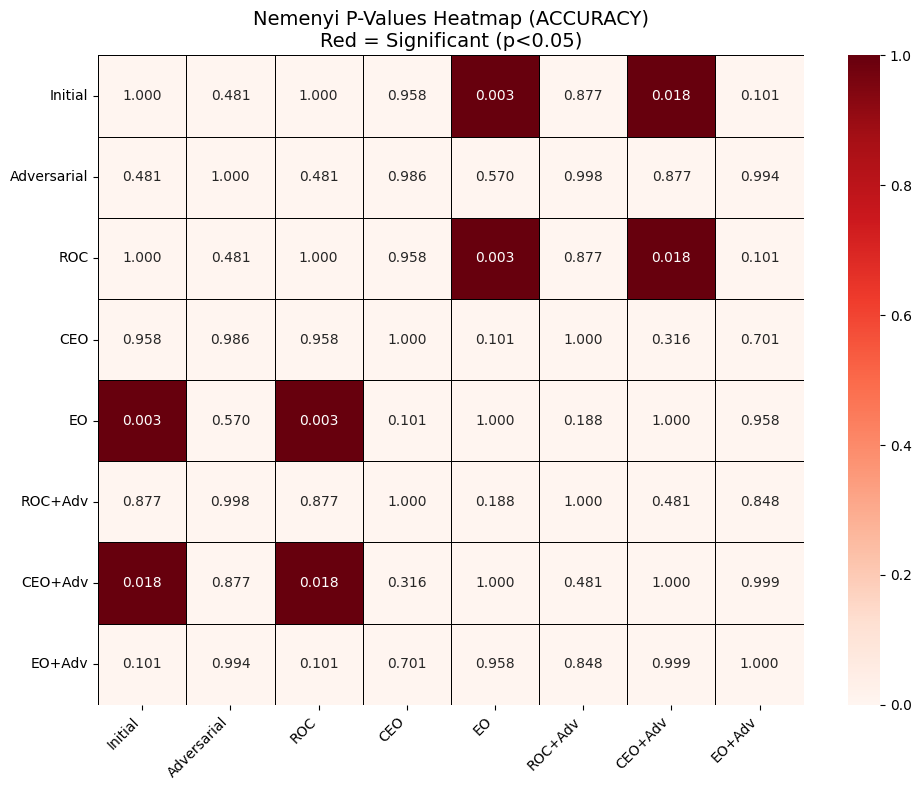


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(30.277108433734927), pvalue=np.float64(8.44640948005423e-05))


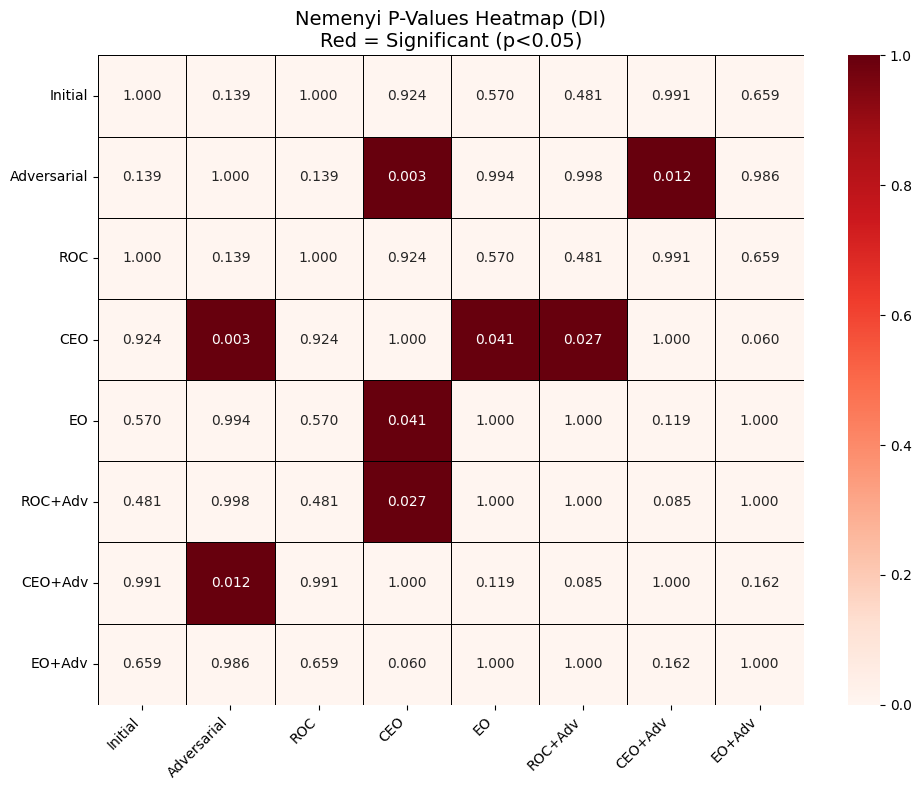


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(31.491566265060246), pvalue=np.float64(5.044644222348228e-05))


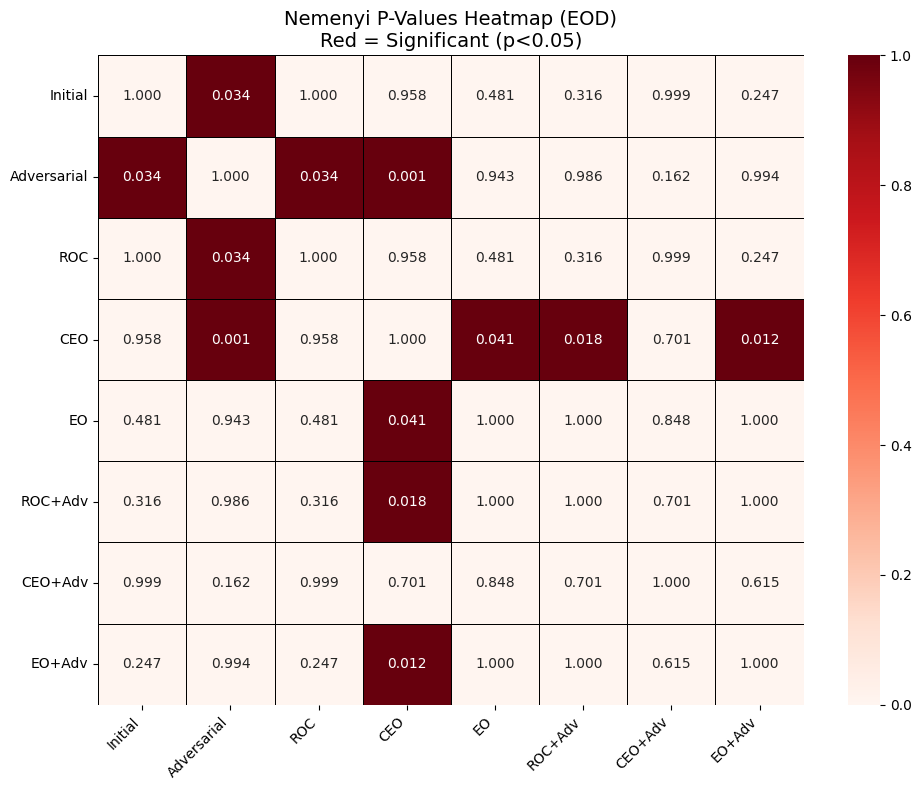


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(31.761445783132523), pvalue=np.float64(4.496697320834843e-05))


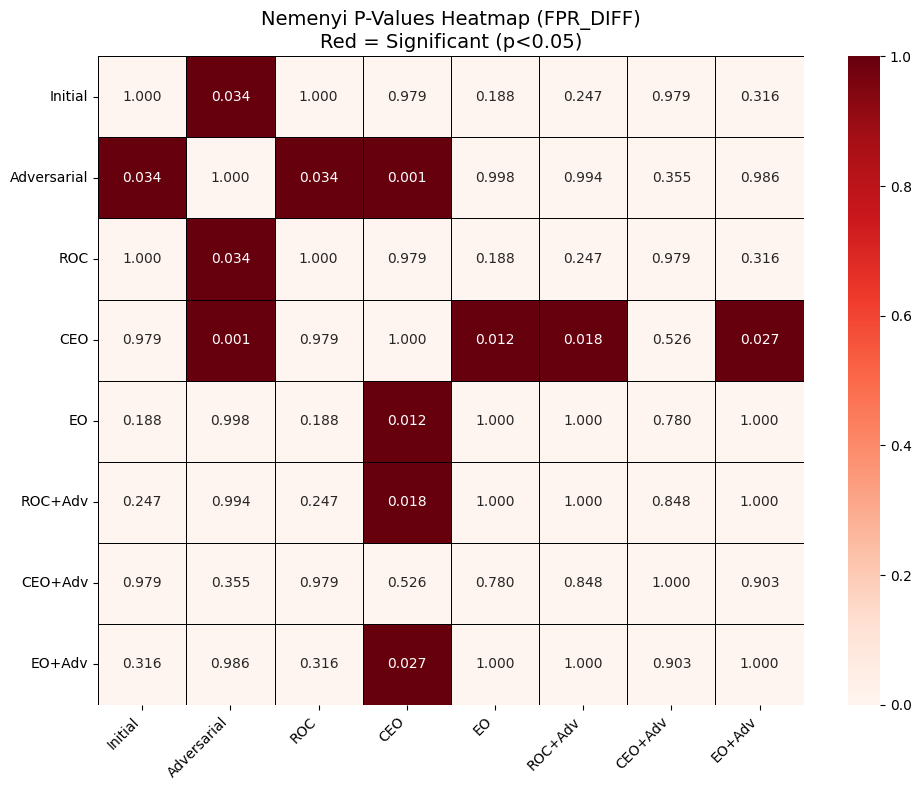

In [58]:
res_nn_race = run_fairness_pipeline("nn", X, y, "race_African-American")

In [59]:
res_nn_race

{'Initial': {'accuracy': [0.6943866943866944,
   0.6784476784476784,
   0.659043659043659,
   0.6611226611226612,
   0.6775312066574203],
  'di': [np.float64(0.4316756910800798),
   np.float64(0.44914261619190404),
   np.float64(0.5059997757093193),
   np.float64(0.4553734061930783),
   np.float64(0.4594313893973923)],
  'eod': [np.float64(-0.2953879406867947),
   np.float64(-0.3168255444470279),
   np.float64(-0.25651544632844175),
   np.float64(-0.3441119691119691),
   np.float64(-0.24000992802184168)],
  'fpr_diff': [np.float64(-0.1895843989769821),
   np.float64(-0.1770585982382229),
   np.float64(-0.20082666906280885),
   np.float64(-0.13298406405272506),
   np.float64(-0.213884631688786)]},
 'Adversarial': {'accuracy': [0.681912681912682,
   0.6673596673596673,
   0.6465696465696466,
   0.6306306306306306,
   0.6532593619972261],
  'di': [np.float64(0.8671757871064467),
   np.float64(1.0819663548792406),
   np.float64(1.1225952470765748),
   np.float64(1.2577512577512577),
   np.